# If you clone, at least reference my work!

## 1. Introduction
This notebook analyzes the filtered and enriched database from notebook 7 repository 2_Micro, that came from the picrust2 pipeline develped and the classification and filtration in operational heating and cooling water systems, primarily in German sites.

### Directory Structure:
``` text
Continuation from repository 2_Micro notebook notebook 1, split and analyse the data 2, make a EDA, 3. Statistical Analysis 4. Literature Mining 5. 16s RNA alignemnt, consensus tree 6. picrust_ where the picrust2 pipeline is use to find functional information on the data and  7_database where several databases are used to complement the picrust functional analysis
    Notebook 1_visual_protein.ipynb
    |
    ├── Section 1-2: Introduction, loading CS, imports, paths,    
    |          └── parsing missing pathways 
    |
    ├──Section 3: General Visualisations  
    |        ├── Multiple visualisations, functional cat, etc 
    |        └── Temporal transition, distribution, UMAP 
    ├── Section 4: Protein visualisation
    |        ├── Protein abundance trayectories
    |        ├── Genera Headmaps, similarity clusters
    |        └── Supergroups: from hierarchi clusters
    |               ├── Three panel functional sub vs risk cat
    |               ├── Metal involvement by genera
    |               ├── Top markers by score
    |               ├── Top protein by shared genera
    |                
    ├── Section 5: Network analysis
    |               ├── Functional metabolism
    |               └── Dashboard
    ├── Section 6: Pathways
    |               ├── Bubble pathway enrichment risk cat
    |               ├── Corrosion relevant pathways   
    |               └── Mirror comparison 2 pathway categories
    ├── Section 7: Class / Hierarchi
    |               ├── Sunburn representation of Class 
    |               └── Hierarchi plot
    ├── Section 8: Conceptual map analysis (Table protein-genus/risk pattern/ MIC function )
    |               ├── Protein marker from bacteria hierarchi Nb 5
    |               ├── Algorith implementaion
    |               ├── Pionieer Species Cat2 Markers / Failure Species Cat 3 Markers
    |               └── Making key proteins df across genera based on functional categories and expression patterns
    |                
    ├──── continues to  Notebook 2_cluster_preparation MIC data + Physicochemical data
    |
    ├──── Notebook 3_Nobel_MIC
    |
    └──── Notebook 4_Neuronetwork ML (corrosion prediction)

# 2. Loading and Preparing the Data

## 2.1 Colab Initialisation

In [1]:
'''#os.path.exists('/content/drive/MyDrive')
from google.colab import drive
#drive.flush_and_unmount()

# Colab specific
from google.colab import files
drive.mount('/content/drive')
#change the path
os.chdir('/content/drive/MyDrive/MIC/data_picrust')'''

"#os.path.exists('/content/drive/MyDrive')\nfrom google.colab import drive\n#drive.flush_and_unmount()\n\n# Colab specific\nfrom google.colab import files\ndrive.mount('/content/drive')\n#change the path\nos.chdir('/content/drive/MyDrive/MIC/data_picrust')"

## 2.2. Installing Software Kaggle / Colab

In [2]:
'''# kernel in local is 3_combined python 3.11
# Making sure to use same python version for compatibility 3.11, Kaggle is very insufferable
!sudo apt-get update -y
!sudo apt-get install python3.11
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.11
!python --version'''

'# kernel in local is 3_combined python 3.11\n# Making sure to use same python version for compatibility 3.11, Kaggle is very insufferable\n!sudo apt-get update -y\n!sudo apt-get install python3.11\n!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.11\n!python --version'

In [3]:
'''!pip install -q pandas numpy pyarrow openpyxl \
    matplotlib seaborn plotly kaleido ipywidgets \
    scikit-learn scipy statsmodels umap-learn kneed shap \
    torch \
    networkx python-louvain \
    dash dash-bootstrap-components dash-cytoscape \
    biopython biom-format \
    psutil lxml natsort joblib h5py \
    fuzzywuzzy python-Levenshtein adjustText nbformat'''

'!pip install -q pandas numpy pyarrow openpyxl     matplotlib seaborn plotly kaleido ipywidgets     scikit-learn scipy statsmodels umap-learn kneed shap     torch     networkx python-louvain     dash dash-bootstrap-components dash-cytoscape     biopython biom-format     psutil lxml natsort joblib h5py     fuzzywuzzy python-Levenshtein adjustText nbformat'

In [4]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN 
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
import umap
from scipy.sparse import csr_matrix
import re
import dash
from dash import dcc, html, Input, Output, State
import community as community_louvain
from collections import defaultdict
from matplotlib import colormaps
from matplotlib.colors import rgb2hex
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster
from typing import List, Dict, Tuple, Optional, Any
import dash_cytoscape as cyto

In [5]:
import os
sys.path.append(os.path.abspath('..'))  # Ensures the project root is in Python's search path
# Check if the Kaggle environment is active
if Path("/kaggle").exists():
    print("Running Kaggle environment")
    # Check if the necessary directory and files already exist
    scoring_dir = Path(os.getcwd()) / "corrosion_scoring_v3"
    if not scoring_dir.exists() or not list(scoring_dir.glob("*.py")):
        print("Scoring directory not found or files are missing, downloading dependencies.")
        os.makedirs(scoring_dir, exist_ok=True)
        !wget -O corrosion_scoring_v3/__init__.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/__init__.py
        !wget -O corrosion_scoring_v3/global_terms.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/global_terms.py
        !wget -O corrosion_scoring_v3/term_processor.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/term_processor.py
        !wget -O corrosion_scoring_v3/config.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/config.py
        !wget -O corrosion_scoring_v3/score_calculator.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/score_calculator.py
        !wget -O corrosion_scoring_v3/synergy_detector.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/synergy_detector.py
        !wget -O corrosion_scoring_v3/name_utils.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/name_utils.py
        !wget -O corrosion_scoring_v3/utils_ec.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/utils_ec.py
        !wget -O corrosion_scoring_v3/validators.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/validators.py
        !wget -O corrosion_scoring_v3/exceptions.py https://raw.githubusercontent.com/MagicAlex238/2_Micro/main/corrosion_scoring_root/corrosion_scoring_v3/exceptions.py
        # Add current directory to path
        print("Dependencies downloaded.")
    else:
        print("Dependencies already exist at:", scoring_dir)
    
    sys.path.append(os.getcwd())
else:
    print("Running in local (VSCode) environment")
    sys.path.insert(0, "/home/beatriz/MIC/2_Micro/corrosion_scoring_root")
    try:
        import corrosion_scoring_v3
        print("Package is already installed and accessible.")
    except ImportError:
        print("Package not found, installing now...")
        os.system("pip cache purge")
        os.system("pip install --force-reinstall git+https://github.com/MagicAlex238/2_Micro.git@main#subdirectory=corrosion_scoring_root/corrosion_scoring_v3")

# Try importing the package and initializing components
try:
    import corrosion_scoring_v3 as cs
    from corrosion_scoring_v3.term_processor import TermProcessor
    from corrosion_scoring_v3.name_utils import enhanced_clean_protein_name, clean_protein_name
    from corrosion_scoring_v3.utils_ec import normalize_ec_id, strip_all_ec_tokens, normalize_listlike, standardize_metals_list, standardize_metal_symbol
    from corrosion_scoring_v3.validators import ValidationError
    from corrosion_scoring_v3.exceptions import ScoringError, TextMiningError, SynergyDetectionError
    from corrosion_scoring_v3.global_terms import (
        metal_terms_dict, functional_categories_dict, corrosion_synergies_dict,
        mechanisms_dict, pathway_dict, operational_environmental_factors_dict, metal_mapping
    )
    print("Import successful.")

    # create processors (use cs.<name> for consistency)
    fc_processor = TermProcessor(cs.functional_categories_dict)
    metal_processor = TermProcessor(cs.metal_terms_dict)
    synergy_processor = TermProcessor(cs.corrosion_synergies_dict)
    mechanisms_processor = TermProcessor(cs.mechanisms_dict)
    pathway_processor = TermProcessor(cs.pathway_dict)
    ope_processor = TermProcessor(cs.operational_environmental_factors_dict)

    processors =   {'fc_processor': fc_processor, 'metal_processor': metal_processor,
        'synergy_processor': synergy_processor}

    # Initialize v3 components with existing processors
    # ---- Initialize v3 system components ----
    config = cs.ScoringConfig()
    text_miner = cs.TextMiner(config)
    text_miner.processors = processors 

    score_calculator = cs.ScoreCalculator(config)
    synergy_detector = cs.SynergyDetector(config)
    metal_mapping = cs.metal_mapping 

except ImportError as e:
    raise ImportError(f"Failed to import package or components: {e}")

Running in local (VSCode) environment
Package is already installed and accessible.
Import successful.


## 2.3. Importing Libraries,  Making Directories and Loading Data

In [6]:
# Set up defaults for all
base_dir = None
abundance_excel = None
output_large = None
output_base = None
market_dir = None
data_physicochemical = None
data_visual = None
combined_path = None

# Determine the environment
if "google.colab" in sys.modules:
    print("Running in Google Colab environment")
    base_dir = Path("/content/drive/MyDrive/MIC")
    output_base = base_dir
    output_large = base_dir / "output_large"
    market_dir = output_large / "Markers"
    abundance_excel = base_dir / "2_Micro/data_Ref/merged_to_sequence.xlsx"
    data_physicochemical = base_dir / "physicochemical-parameters/Physicochemical.xlsx"
    data_visual = base_dir / "3_combi/data_visual"
elif Path("/kaggle").exists():
    print("Running in Kaggle environment")
    base_dir = Path("/kaggle/input")
    output_base = Path("/kaggle/working")
    output_large = output_base / "output_large"  # Not used in original but defined for consistency
    market_dir = output_base / "Markers"
    abundance_excel = base_dir / "new-picrust/merged_to_sequence.xlsx"
    data_physicochemical = base_dir / "physicochemical-parameters/Physicochemical.xlsx"
    data_visual = output_base / "data_visual"

else:
    print("Running in local (VSCode) environment")
    base_dir = Path("/home/beatriz/MIC")
    output_base = base_dir
    output_large = base_dir / "output_large"
    market_dir = output_large / "Markers"
    abundance_excel = base_dir / "2_Micro/data_Ref/merged_to_sequence.xlsx"
    data_physicochemical = base_dir / "2_Micro/data_physicochemical/Physicochemical.xlsx"
    save_path = Path("/mnt/c/Users/Amanda/shared/") # "C:\Users\Amanda\shared"
    data_visual =  save_path

# Print confirmation of which paths are being used
print(f"Base directory: {base_dir}")
print(f"Abundance Excel: {abundance_excel}")
print(f"Output base: {output_base}")
print(f"Output large: {output_large}")
print(f"Market dir: {market_dir}")
print(f"Physicochemical Excel: {data_physicochemical}")
print(f"data_visual Directory: {data_visual}")

Running in local (VSCode) environment
Base directory: /home/beatriz/MIC
Abundance Excel: /home/beatriz/MIC/2_Micro/data_Ref/merged_to_sequence.xlsx
Output base: /home/beatriz/MIC
Output large: /home/beatriz/MIC/output_large
Market dir: /home/beatriz/MIC/output_large/Markers
Physicochemical Excel: /home/beatriz/MIC/2_Micro/data_physicochemical/Physicochemical.xlsx
data_visual Directory: /mnt/c/Users/Amanda/shared


In [7]:
parquet_dir = market_dir  

corrosion_report = {}
if os.path.exists(parquet_dir):
    for filename in os.listdir(parquet_dir):
        if filename.endswith('.parquet'):
            name = filename.replace('.parquet', '')
            parquet_path = os.path.join(parquet_dir, filename)
            corrosion_report[name] = pd.read_parquet(parquet_path, engine='pyarrow')
            print(f"Loaded {name} - Shape: {corrosion_report[name].shape}")
else:
    print(f"Parquet directory {parquet_dir} does not exist.")

# Check available DataFrames
for name, df in corrosion_report.items():
    print(f"{name}: {df.shape}")

Loaded group_operational_all - Shape: (628, 55)
Loaded group_consolidated_metals - Shape: (633, 53)
Loaded group_biofilm_complexes - Shape: (9, 54)
Loaded group_mechanisms_all - Shape: (562, 53)
Loaded classified_results - Shape: (1168868, 43)
Loaded group_mechanism_all - Shape: (187, 49)
Loaded group_high_nice_relevance - Shape: (525, 49)
Loaded group_unified_synergy - Shape: (270, 53)
Loaded group_corrosion_critical - Shape: (67, 55)
Loaded group_inorganic_acid_complexes - Shape: (113, 55)
Loaded balanced_biofilm_markers - Shape: (744, 43)
Loaded group_functional_categories - Shape: (840, 50)
Loaded group_synergy_child - Shape: (270, 52)
Loaded integrated_results - Shape: (1168868, 40)
Loaded group_high_pathway_relevance - Shape: (32, 49)
Loaded group_synergy_all - Shape: (313, 55)
Loaded group_functional_child - Shape: (332, 49)
Loaded group_high_corrosion_relevance - Shape: (158, 53)
Loaded group_organic_acid_complexes - Shape: (258, 55)
Loaded group_high_niche_relevance - Shape: (

In [8]:
# Integrated taxa from origin genus as headers with levels 6 for the genera, 7 for the GID, muss be cleaned
Integrated_T = pd.read_excel(abundance_excel, sheet_name='core_check_usual_taxa', header=[0,1,2,3,4,5,6,7], engine ='openpyxl')
# Drop first row (index 0) and first column in one chain
Integrated_T = Integrated_T.drop(index=0).drop(Integrated_T.columns[0], axis=1)
Integrated_T= Integrated_T.astype({'Sites': str})
Integrated_T['Sites'] = Integrated_T['Sites'].fillna('Source')
Integrated_T = Integrated_T.iloc[:-1]
# Remove 'Unnamed' level names
Integrated_T.columns = Integrated_T.columns.map(lambda x: tuple('' if 'Unnamed' in str(level) else level for level in x))
# Changing dtypes to category whiles respecting structure
Integrated_T["Category"] = Integrated_T["Category"].astype("Int64")
Integrated_T= Integrated_T.set_index("Sites")

## 2.4. Extracting Dictionary and Dataframes

In [9]:
category_dict = dict(zip(Integrated_T.index, Integrated_T["Category"].values))
# Define colors and categories
category_colors = {1: '#008800',  # Dark green
                   2: '#FF8C00',  # Dark orange
                   3: '#FF0000'}   # Red

categories_labels = {1: 'Normal Operation',
              2: 'Early Warning',
              3: 'System Failure'}

# Ensure a deterministic mapping between category names and colors
hue_order = ['Normal Operation', 'Early Warning', 'System Failure']
palette_map = {
    'Normal Operation': category_colors[1],
    'Early Warning': category_colors[2],
    'System Failure': category_colors[3]
}

In [10]:
# Main analysis frames
pattern_data                    = corrosion_report["pattern_data"]                     # Sites: 70   Genus: 85   Rows: 1168868  Columns: 21
integrated_results              = corrosion_report["integrated_results"]               # Sites: 70   Genus: 85   Rows: 1168868  Columns: 40
classified_results              = corrosion_report["classified_results"]               # Sites: 70   Genus: 85   Rows: 1168868  Columns: 43
increasing_markers              = corrosion_report["increasing_markers"]               # Sites: 53   Genus: 84   Rows: 849714   Columns: 43
inverse_markers                 = corrosion_report["inverse_markers"]                  # Sites: 17   Genus: 80   Rows: 319154   Columns: 43
prioritized_markers             = corrosion_report["prioritized_markers"]              # Sites: 53   Genus: 84   Rows: 849714   Columns: 52
balanced_markers                = corrosion_report["balanced_markers"]                 # Sites: 53   Genus: 71   Rows: 656      Columns: 56
balanced_biofilm_markers        = corrosion_report["balanced_biofilm_markers"]         # Sites: 52   Genus: 79   Rows: 744      Columns: 44

# Marker groups (group_<name> keys)
top_markers                     = corrosion_report["group_top_markers"]                 # Sites: 42   Genus: 31   Rows: 164      Columns: 54
significant_markers             = corrosion_report["group_significant_markers"]         # Sites: 21   Genus: 36   Rows: 164      Columns: 54
high_metals_relevance           = corrosion_report["group_high_metals_relevance"]       # Sites: 42   Genus: 44   Rows: 158      Columns: 54
high_functional_relevance       = corrosion_report["group_high_functional_relevance"]   # Sites: 45   Genus: 36   Rows: 158      Columns: 54
high_synergy_relevance          = corrosion_report["group_high_synergy_relevance"]      # Sites: 41   Genus: 45   Rows: 156      Columns: 54
high_corrosion_relevance        = corrosion_report["group_high_corrosion_relevance"]    # Sites: 47   Genus: 37   Rows: 158      Columns: 54
high_niche_relevance            = corrosion_report["group_high_niche_relevance"]        # Sites: 42   Genus: 30   Rows: 161      Columns: 54
mechanisms_all                  = corrosion_report["group_mechanisms_all"]              # Sites: 53   Genus: 64   Rows: 562      Columns: 54
consolidated_metals             = corrosion_report["group_consolidated_metals"]         # Sites: 53   Genus: 65   Rows: 633      Columns: 54
pathways_all                    = corrosion_report["group_pathways_all"]                # Sites: 52   Genus: 55   Rows: 485      Columns: 54
functional_all                  = corrosion_report["group_functional_all"]              # Sites: 48   Genus: 54   Rows: 252      Columns: 54

# Complexation / environmental groups
inorganic_acid_complexes        = corrosion_report["group_inorganic_acid_complexes"]    # Sites: 53   Genus: 63   Rows: 568      Columns: 56
organic_acid_complexes          = corrosion_report["group_organic_acid_complexes"]      # Sites: 53   Genus: 62   Rows: 390      Columns: 56
operational_all                 = corrosion_report["group_operational_all"]             # Sites: 53   Genus: 65   Rows: 628      Columns: 56
synergy_all                     = corrosion_report["group_synergy_all"]                 # Sites: 45   Genus: 53   Rows: 313      Columns: 56
biofilm_indicators              = corrosion_report["group_biofilm_indicators"]          # Sites: 52   Genus: 79   Rows: 744      Columns: 44

# Operational and relevance groups
high_biological_relevance       = corrosion_report["group_high_biological_relevance"]   # Sites: 44   Genus: 39   Rows: 164      Columns: 57
corrosion_critical              = corrosion_report["group_corrosion_critical"]          # Sites: 30   Genus: 15   Rows: 67       Columns: 56

## 2.5 Pathways Parsing

| PWY code | Descriptive name | Notes | Ref |
| :-: | :--- | :--- | :-: |
| **PWY-1422** | CDP-diacylglycerol biosynthesis II | Lipid precursor synthesis pathway | ¹ |
| **PWY-3801** | Sucrose degradation (anaerobic) | Fermentation produces ethanol and lactate (H+), contributing to localized acidification (acid corrosion) and forming aggressive metabolites in the biofilm matrix. | ² |
| **PWY-5308** | Superpathway of sulfur metabolism | Includes dissimilatory sulfate reduction, which is the primary source of highly aggressive, localized sulfide attack (H₂S) in anaerobic niches. | ³ |
| **PWY-5497** | Superpathway of Purine Nucleotide Salvage |Recycles free purine bases (adenine, guanine, hypoxanthine) into nucleotides; energy-efficient alternative to de novo synthesis.| ⁴ |
| **PWY-5751** | Phenylethanol biosynthesis | Production of aromatic alcohols, which are corrosive organic solvents that can disrupt the passive oxide layer and facilitate localized attack. | 5 |
| **PWY-5789** | L-Lactate Fermentation to Acetate and Ethanol | Generates acetate and ethanol from lactate, furthering organic acid corrosion and producing secondary corrosive organic solvents in the biofilm matrix. | ⁵ |
| **PWY-6113** | Superpathway of Nitrate Assimilation | Consumes nitrate (NO₃⁻) to produce nitrite (NO₂⁻) and eventually ammonium, linking nitrogen metabolism to the consumption of a common corrosion inhibitor. | ⁶ |
| **PWY-6142** | L-Isoleucine biosynthesis II | Amino acid synthesis pathway, specialized route for L-Isoleucine production | ⁷ |
| **PWY-6145** | Superpathway of Chorismate Biosynthesis | Synthesis of the aromatic amino acid precursor chorismate | ⁸ |
| **PWY-6146** | Superpathway of UDP-GlcA Biosynthesis | Involved in the synthesis of sugar nucleotides/cofactors, essential for glycosylation and detoxification processes | ⁹ |
| **PWY-6281** | Superpathway of Branched-Chain Amino Acid Biosynthesis |Regulates the production of leucine, isoleucine, and valine; vital for protein synthesis and nitrogen metabolism.| 10 |
| **PWY-6285** | Dissimilatory Nitrite Reduction to Ammonium (DNRA) | A terminal electron-accepting process that produces corrosive ammonium (NH₄⁺) and consumes nitrite (NO₂⁻), altering the local chemistry and potentially depleting biocides. | ¹1 |
| **PWY-6395** | Superpathway of CDP-diacylglycerol Biosynthesis | Core lipid precursor synthesis pathway, essential for membrane lipid production and signaling | ¹2 |
| **PWY-6594** | Superpathway of Clostridium acetobutylicum acidogenic and solventogenic fermentation | Generates primary corrosive organic acids (acidogenic phase) followed by corrosive solvents (solventogenic phase), driving pitting. | ¹3 |
| **PWY-6604** | Acetyl-CoA Fermentation Pathway | Consolidated pathway that rapidly generates both protons (acid corrosion) and damaging solvents (pitting promoters) from carbohydrate sources. | ¹4 |
| **PWY-6676** | Superpathway of sulfide oxidation | Re-oxidizes corrosive sulfide or thiosulfate to less harmful sulfate, potentially offering a localized but temporary mitigation mechanism within the biofilm | ¹5 |
| **PWY-6728** | Methylaspartate Cycle (Glutamate Fermentation) | Fermentation of glutamate to short-chain fatty acids (SCFAs) like acetate and propionate, contributing to localized acidification and organic acid corrosion. | ¹6 |
| **PWY-6785** | Hydrogen production fermentations | Maintaining redox balance by consuming excess NADH and producing molecular H₂, leads to cathodic depolarization | ¹7 |
| **PROPFERM-PWY** | Propionate Fermentation - acrylate pathway | Fermentation pathway for propionate production via acrylate route | ¹8 |
| **P181-PWY** | Methylmalonyl-CoA pathway for Propanoate production | Fermentation pathway for propanoate production via methylmalonyl-CoA intermediate | ¹9 |
| **PWY-7402** | Benzoate fermentation (to acetate and cyclohexane carboxylate) | Anaerobic aromatic compound fermentation contribute to localized acidification and organic acid corrosion within biofilm microenvironments.  | 20|
| **PWY-7124** | L-lysine degradation I to acids | Lysine degradation involving cadaverine and/or 5-aminovalerate (AMV) ultimately leading to glutarate and then α-ketoglutarate or succinate, plausible on corrosion environments. | 21 |

REFERENCES (APA Style):

¹ Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458. https://doi.org/10.1093/nar/gkaa1002

² BioCyc. (n.d.). PWY-3801: Sucrose degradation (anaerobic). Retrieved from https://biocyc.org/pathway?id=PWY-3801

³ ModelSEED. (n.d.). PWY-5308: Superpathway of sulfur metabolism. Retrieved from https://modelseed.org/biochem/reactions/rxn27259

4 MetaCyc. (2024). Superpathway of purine nucleotide salvage. Retrieved from https://metacyc.org/pathway?object=PWY-5497

⁴ BioCyc. (n.d.). PWY-5751: Phenylethanol biosynthesis. Retrieved October 23, 2025, from https://biocyc.org/META/NEW-IMAGE?object=PWY-5751&type=PATHWAY

⁵ BioCyc. (n.d.). PWY-5789: L-Lactate fermentation to acetate and ethanol. Retrieved from https://biocyc.org/pathway?id=PWY-5789

⁶ BioCyc. (n.d.). PWY-6113: Superpathway of nitrate assimilation. Retrieved from https://biocyc.org/pathway?id=PWY-6113

⁷ Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458.

⁸ Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458.

⁹ Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458.

¹⁰ MetaCyc. (2024). Superpathway of branched-chain amino acid biosynthesis. Retrieved from https://metacyc.org/pathway?object=PWY-6281

¹¹ BioCyc. (n.d.). PWY-6285: Dissimilatory nitrite reduction to ammonium (DNRA). Retrieved from https://biocyc.org/pathway?id=PWY-6285

¹² BioCyc. (n.d.). PWY-6395: Superpathway of CDP-diacylglycerol biosynthesis. Retrieved from https://biocyc.org/pathway?id=PWY-6395

¹³ BioCyc. (n.d.). PWY-6594: Superpathway of Clostridium acetobutylicum acidogenic and solventogenic fermentation. Retrieved October 23, 2025, from https://biocyc.org/pathway?id=PWY-6594&orgid=META

¹⁴ BioCyc. (n.d.). PWY-6604: Superpathway of Clostridium acetobutylicum acidogenic and solventogenic fermentation. Retrieved from https://biocyc.org/pathway?id=PWY-6604&orgid=META

¹⁵ BioCyc. (n.d.). PWY-6676: Superpathway of sulfide oxidation (phototrophic sulfur bacteria). Retrieved October 23, 2025, from https://biocyc.org/META/NEW-IMAGE?object=PWY-6676&type=PATHWAY

¹⁶ Choo, Y. L., et al. (2016). The methylaspartate cycle: A novel anaplerotic pathway for C2 assimilation in methylotrophs. Applied and Environmental Microbiology, 82(14), 4381–4390. https://doi.org/10.1128/AEM.00455-16

¹⁷ BioCyc. (n.d.). PWY-6785: Hydrogen production fermentations. Retrieved from https://biocyc.org/pathway?id=PWY-6785

¹⁸ Franzosa, E. A., et al. (2022). A comparison of computational methods for pathway reconstruction from metagenomic data. Nature Communications, 13(1), 3021. https://doi.org/10.1038/s41467-022-30812-w

¹9 Karp, P. D., Hoyle, R. H., et al. (2021). The MetaCyc database of metabolic pathways and enzymes and the BioCyc collection of Pathway/Genome Databases. Nucleic Acids Research, 49(D1), D450–D458.

In [11]:
def rename_pathway_single(pathway_name: str) -> str:
    """ Renames a single pathway string based on a predefined dictionary.Safely handles NaN/None values and removes them.
    Safe for use with pandas Series.apply()."""
    replace = {'PWY-5751':  'Phenylethanol biosynthesis',       'PWY-6594': 'acetobutylicum solventogenic fermentation', 
               'PWY-6676': 'S. of sulfide oxidation', 'PWY-5308': 'S. of sulfur metabolism',
               'PWY-3801': 'Sucrose degradation (anaerobic)',   'PWY-6604' :'Acetyl-CoA Fermentation Pathway', 
               'PWY-6785': 'hydrogen production fermentation',  'PWY-6113': 'S. of Nitrate Assimilation', 
               'PWY-5789': 'L-Lactate Fermentation to Acetate and Ethanol', 
               'PWY-6285': 'Dissimilatory Nitrite Reduction to Ammonium', 'PROPFERM-PWY':'Propionate Fermentation - acrylate pathway',
               'PWY-6728': 'Methylaspartate Cycle (Glutamate Fermentation)', 'P181-PWY' : 'Methylmalonyl-CoA pathway for Propanoate production',
               'PWY-6142': 'L-Isoleucine biosynthesis II'               , 'PWY-1422': 'CDP-diacylglycerol biosynthesis II',
               'PWY-6146': 'S. of UDP-GlcA Biosynthesis',       'PWY-6395': 'S. of CDP-diacylglycerol Biosynthesis',
               'PWY-6145' : 'S. of Chorismate Biosynthesis' ,   'PWY-6886'	: 'Standard MetaCyc Pathway Entry',
               'PWY-7402' : 'Benzoate fermentation to acetate and cyclohexane carboxylate', 'PWY-7124' : 'L-lysine degradation I to acids',
               'PWY-6281': 'S. of Branched-Chain Amino Acid Biosynthesis', 'PWY-5497' : 'S. of Purine Nucleotide Salvage' }
    #PWY-7274, 
    if pd.isna(pathway_name) or pathway_name is None:
        return '' 
    # Ensure input is a string (handles potential NaN/None after str conversion)
    pathway_name = str(pathway_name).strip()
    # Check if result is the string 'nan' (happens when converting NaN to string)
    if pathway_name.lower() == 'nan' or pathway_name == '':
        return ''
        
    # Check if the name needs renaming, otherwise return the original name
    return replace.get(pathway_name, pathway_name)

In [12]:
pd.set_option("display.max_colwidth", True)
#pd.reset_option('display.max_colwidth')

# 3. General Visualising Corrosion Protein-Genus Pairs Analysis

## 3.1. Multiple Visualizations of Functional Data across Risk Categories
Creates multiple visualizations of functional data across risk categories, with genus-level aggregation and category representation

In [13]:
def plot_multiview_functional_landscape(data_df, name, top_n=25, score_col='combined_score'):
    """
    Creates multiple visualizations of functional data across risk categories,
    using pre-calculated fold changes, sum and mean values without recalculation.
    """
    df = data_df.copy()

    # Aggregate by genus to get top representatives
    genus_agg = df.groupby('Genus').agg({
        score_col: 'mean',
        'mean_cat1': 'mean', 
        'mean_cat2': 'mean',
        'mean_cat3': 'mean'
    }).reset_index()
    
    # Get top genera by score
    top_genera = genus_agg.nlargest(top_n, score_col)['Genus'].tolist()
    
    # Get best protein per genus from top genera
    top_markers = df.loc[df.groupby('Genus')[score_col].idxmax()]
    top_markers = top_markers[top_markers['Genus'].isin(top_genera)]
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # ===================================================================
    # 1. Corrosion Mechanisms Distribution - USE MEAN VALUES DIRECTLY
    # ===================================================================
    mech_by_cat = []
    
    for _, row in top_markers.iterrows():
        if pd.notna(row.get('mechanisms_sub')) and str(row['mechanisms_sub']).strip():
            mechanism = str(row['mechanisms_sub']).strip()
            
            # USE MEAN VALUES DIRECTLY - no multiplication
            cat1_val = row.get('mean_cat1', 0) if pd.notna(row.get('mean_cat1')) else 0
            cat2_val = row.get('mean_cat2', 0) if pd.notna(row.get('mean_cat2')) else 0
            cat3_val = row.get('mean_cat3', 0) if pd.notna(row.get('mean_cat3')) else 0
            
            mech_by_cat.extend([
                {'Mechanism': mechanism, 'Category': 'Normal Operation', 'Abundance': cat1_val, 'CategoryID': 1},
                {'Mechanism': mechanism, 'Category': 'Early Warning', 'Abundance': cat2_val, 'CategoryID': 2},
                {'Mechanism': mechanism, 'Category': 'System Failure', 'Abundance': cat3_val, 'CategoryID': 3}
            ])
    
    if mech_by_cat:
        mech_df = pd.DataFrame(mech_by_cat)
        agg_mech = mech_df.groupby(['Mechanism', 'Category', 'CategoryID'])['Abundance'].sum().reset_index()
        
        # Get top mechanisms
        top_mechanisms = agg_mech.groupby('Mechanism')['Abundance'].sum().nlargest(8).index
        filtered_mech = agg_mech[agg_mech['Mechanism'].isin(top_mechanisms)]
        
        sns.barplot(
            data=filtered_mech,
            x='Abundance',
            y='Mechanism',
            hue='Category',
            hue_order=hue_order,
            palette=palette_map,
            ax=axes[0, 0]
        )
        axes[0, 0].set_title("Top Corrosion Mechanisms by Risk Category", fontsize=14)
        axes[0, 0].set_xlabel("Mean Abundance", fontsize=12)
        axes[0, 0].set_ylabel("Mechanism", fontsize=12)
    else:
        axes[0, 0].text(0.5, 0.5, "No mechanism data available", ha='right', va='center', fontsize=14)
        axes[0, 0].set_title('Top Corrosion Mechanisms', fontsize=14)
    
    # ===================================================================
    # 2. Protein Abundance Heatmap - USE MEAN VALUES DIRECTLY
    # ===================================================================
    required_cols = ['mean_cat1', 'mean_cat2', 'mean_cat3', 'Genus', 'protein_name']
    has_required_cols = all(col in top_markers.columns for col in required_cols)
    
    if has_required_cols and not top_markers.empty:
        sorted_markers = top_markers.sort_values(by='mean_cat3', ascending=False).head(15)
        
        protein_labels = []
        for _, row in sorted_markers.iterrows():
            genus = row.get('Genus', 'Unknown')
            protein_name = row.get('protein_name', 'Unknown')
            
            if isinstance(protein_name, str) and len(protein_name) > 20:
                protein_name = protein_name[:20] + "..."
                
            label = f"{genus} - {protein_name}"
            protein_labels.append(label)
        
        # USE MEAN VALUES DIRECTLY - no norm_abund_contri multiplication
        heatmap_data = pd.DataFrame({
            'Normal Op': sorted_markers['mean_cat1'].values,
            'Early Warning': sorted_markers['mean_cat2'].values,
            'System Failure': sorted_markers['mean_cat3'].values
        })
        
        # Scale rows to percentages for comparison
        for idx in heatmap_data.index:
            row_max = heatmap_data.loc[idx].max()
            if row_max > 0:
                heatmap_data.loc[idx] = (heatmap_data.loc[idx] / row_max * 100).round(1)
        
        sns.heatmap(
            heatmap_data,
            cmap='Reds',
            annot=True,
            fmt='.1f',
            linewidths=0.5,
            yticklabels=protein_labels,
            ax=axes[0, 1],
            vmin=0,
            vmax=100
        )
        
        axes[0, 1].set_title('Protein Abundance Patterns (%)', fontsize=14)
    else:
        axes[0, 1].text(0.5, 0.5, "Insufficient data for heatmap", ha='center', va='center', fontsize=14)
        axes[0, 1].set_title('Protein Abundance Patterns', fontsize=14)
   # ===================================================================
    # 3. Functional Category Enrichment - Aggregate THEN calculate ratio
    # ===================================================================
    if 'functional_sub' in top_markers.columns:
        func_categories = []
        
        for _, row in top_markers.iterrows():
            if pd.notna(row.get('functional_sub')) and row['functional_sub']:
                functional_cat = row['functional_sub']
                
                cat1_val = row.get('mean_cat1', 0) if pd.notna(row.get('mean_cat1')) else 0
                cat3_val = row.get('mean_cat3', 0) if pd.notna(row.get('mean_cat3')) else 0
                
                func_categories.append({
                    'Functional_Category': functional_cat,
                    'Cat1': cat1_val,
                    'Cat3': cat3_val
                })
        
        if func_categories:
            func_df = pd.DataFrame(func_categories)
            
            # Aggregate per category FIRST
            agg_func = func_df.groupby('Functional_Category').agg({
                'Cat1': 'sum',
                'Cat3': 'sum',
            }).reset_index()
            n_proteins = len(top_markers)
            agg_func['Cat1'] = agg_func['Cat1'] / n_proteins
            agg_func['Cat3'] = agg_func['Cat3'] / n_proteins
            # THEN calculate enrichment from aggregated values
            agg_func['Enrichment'] = agg_func['Cat3'] / (agg_func['Cat1'] + 0.001)
            
            # Filter for meaningful entries (at least one category present)
            meaningful_func = agg_func[
                (agg_func['Cat1'] > 0.01) | (agg_func['Cat3'] > 0.01)
            ].sort_values('Enrichment', ascending=False).head(top_n // 3)  # Use top_n parameter
            
            if not meaningful_func.empty:
                sns.barplot(
                    data=meaningful_func,
                    x='Enrichment',
                    y='Functional_Category',
                    color='steelblue',
                    ax=axes[1, 0]
                )
                
                axes[1, 0].axvline(x=1, color='gray', linestyle='--', alpha=0.7)
                
                for i, p in enumerate(axes[1, 0].patches):
                    enrichment = meaningful_func.iloc[i]['Enrichment']
                    axes[1, 0].annotate(
                        f"{enrichment:.1f}x", 
                        (p.get_width() + 0.05, p.get_y() + p.get_height()/2),
                        ha='left', 
                        va='center',
                        fontsize=10
                    )
                
                axes[1, 0].set_title('Functional Category Enrichment (Cat3:Cat1)', fontsize=14)
                axes[1, 0].set_xlabel('Enrichment (from Normal to System Failure)', fontsize=12)
                axes[1, 0].set_ylabel('Functional Category', fontsize=12)
            else:
                axes[1, 0].text(0.5, 0.5, "No significant enrichment patterns", ha='center', va='center', fontsize=14)
                axes[1, 0].set_title('Functional Category Enrichment', fontsize=14)
        else:
            axes[1, 0].text(0.5, 0.5, "No functional categories available", ha='center', va='center', fontsize=14)
            axes[1, 0].set_title('Functional Category Enrichment', fontsize=14)
    else:
        axes[1, 0].text(0.5, 0.5, "Missing functional_sub column", ha='center', va='center', fontsize=14)
        axes[1, 0].set_title('Functional Category Enrichment', fontsize=14)
    # ===================================================================
    # 4. Top Genera Distribution - USE MEAN VALUES DIRECTLY
    # ===================================================================
    if all(col in df.columns for col in ['mean_cat1', 'mean_cat2', 'mean_cat3', 'Genus']):
        genus_summary = df.groupby('Genus').agg({
            'mean_cat1': 'sum',
            'mean_cat2': 'sum',
            'mean_cat3': 'sum',
            score_col: 'mean'
        }).reset_index()
                
        # Normalize by total number of proteins
        n_proteins = len(df)
        genus_summary['mean_cat1'] = genus_summary['mean_cat1'] / n_proteins
        genus_summary['mean_cat2'] = genus_summary['mean_cat2'] / n_proteins
        genus_summary['mean_cat3'] = genus_summary['mean_cat3'] / n_proteins
            
        top_genera_viz = genus_summary.nlargest(12, score_col)
        
        melt_genera = top_genera_viz.melt(
            id_vars=['Genus'],
            value_vars=['mean_cat1', 'mean_cat2', 'mean_cat3'],
            var_name='Category',
            value_name='Abundance'
        )
        
        melt_genera['Category'] = melt_genera['Category'].map({
            'mean_cat1': 'Normal Operation',
            'mean_cat2': 'Early Warning', 
            'mean_cat3': 'System Failure'
        })
        
        sns.barplot(
            data=melt_genera,
            x='Genus',
            y='Abundance',
            hue='Category',
            hue_order=hue_order,
            palette=palette_map,
            ax=axes[1, 1]
        )
        
        axes[1, 1].set_title(f'Top Genera by {score_col}', fontsize=14)
        axes[1, 1].set_xlabel('Genus', fontsize=12)
        axes[1, 1].set_ylabel('Mean Abundance', fontsize=12)
        axes[1, 1].tick_params(axis='x', rotation=60)
    else:
        axes[1, 1].text(0.5, 0.5, "Insufficient genus data", ha='center', va='center', fontsize=14)
        axes[1, 1].set_title('Top Genera Distribution', fontsize=14)
    
    plt.suptitle(f"Functional MIC Landscape: {name}", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    return fig

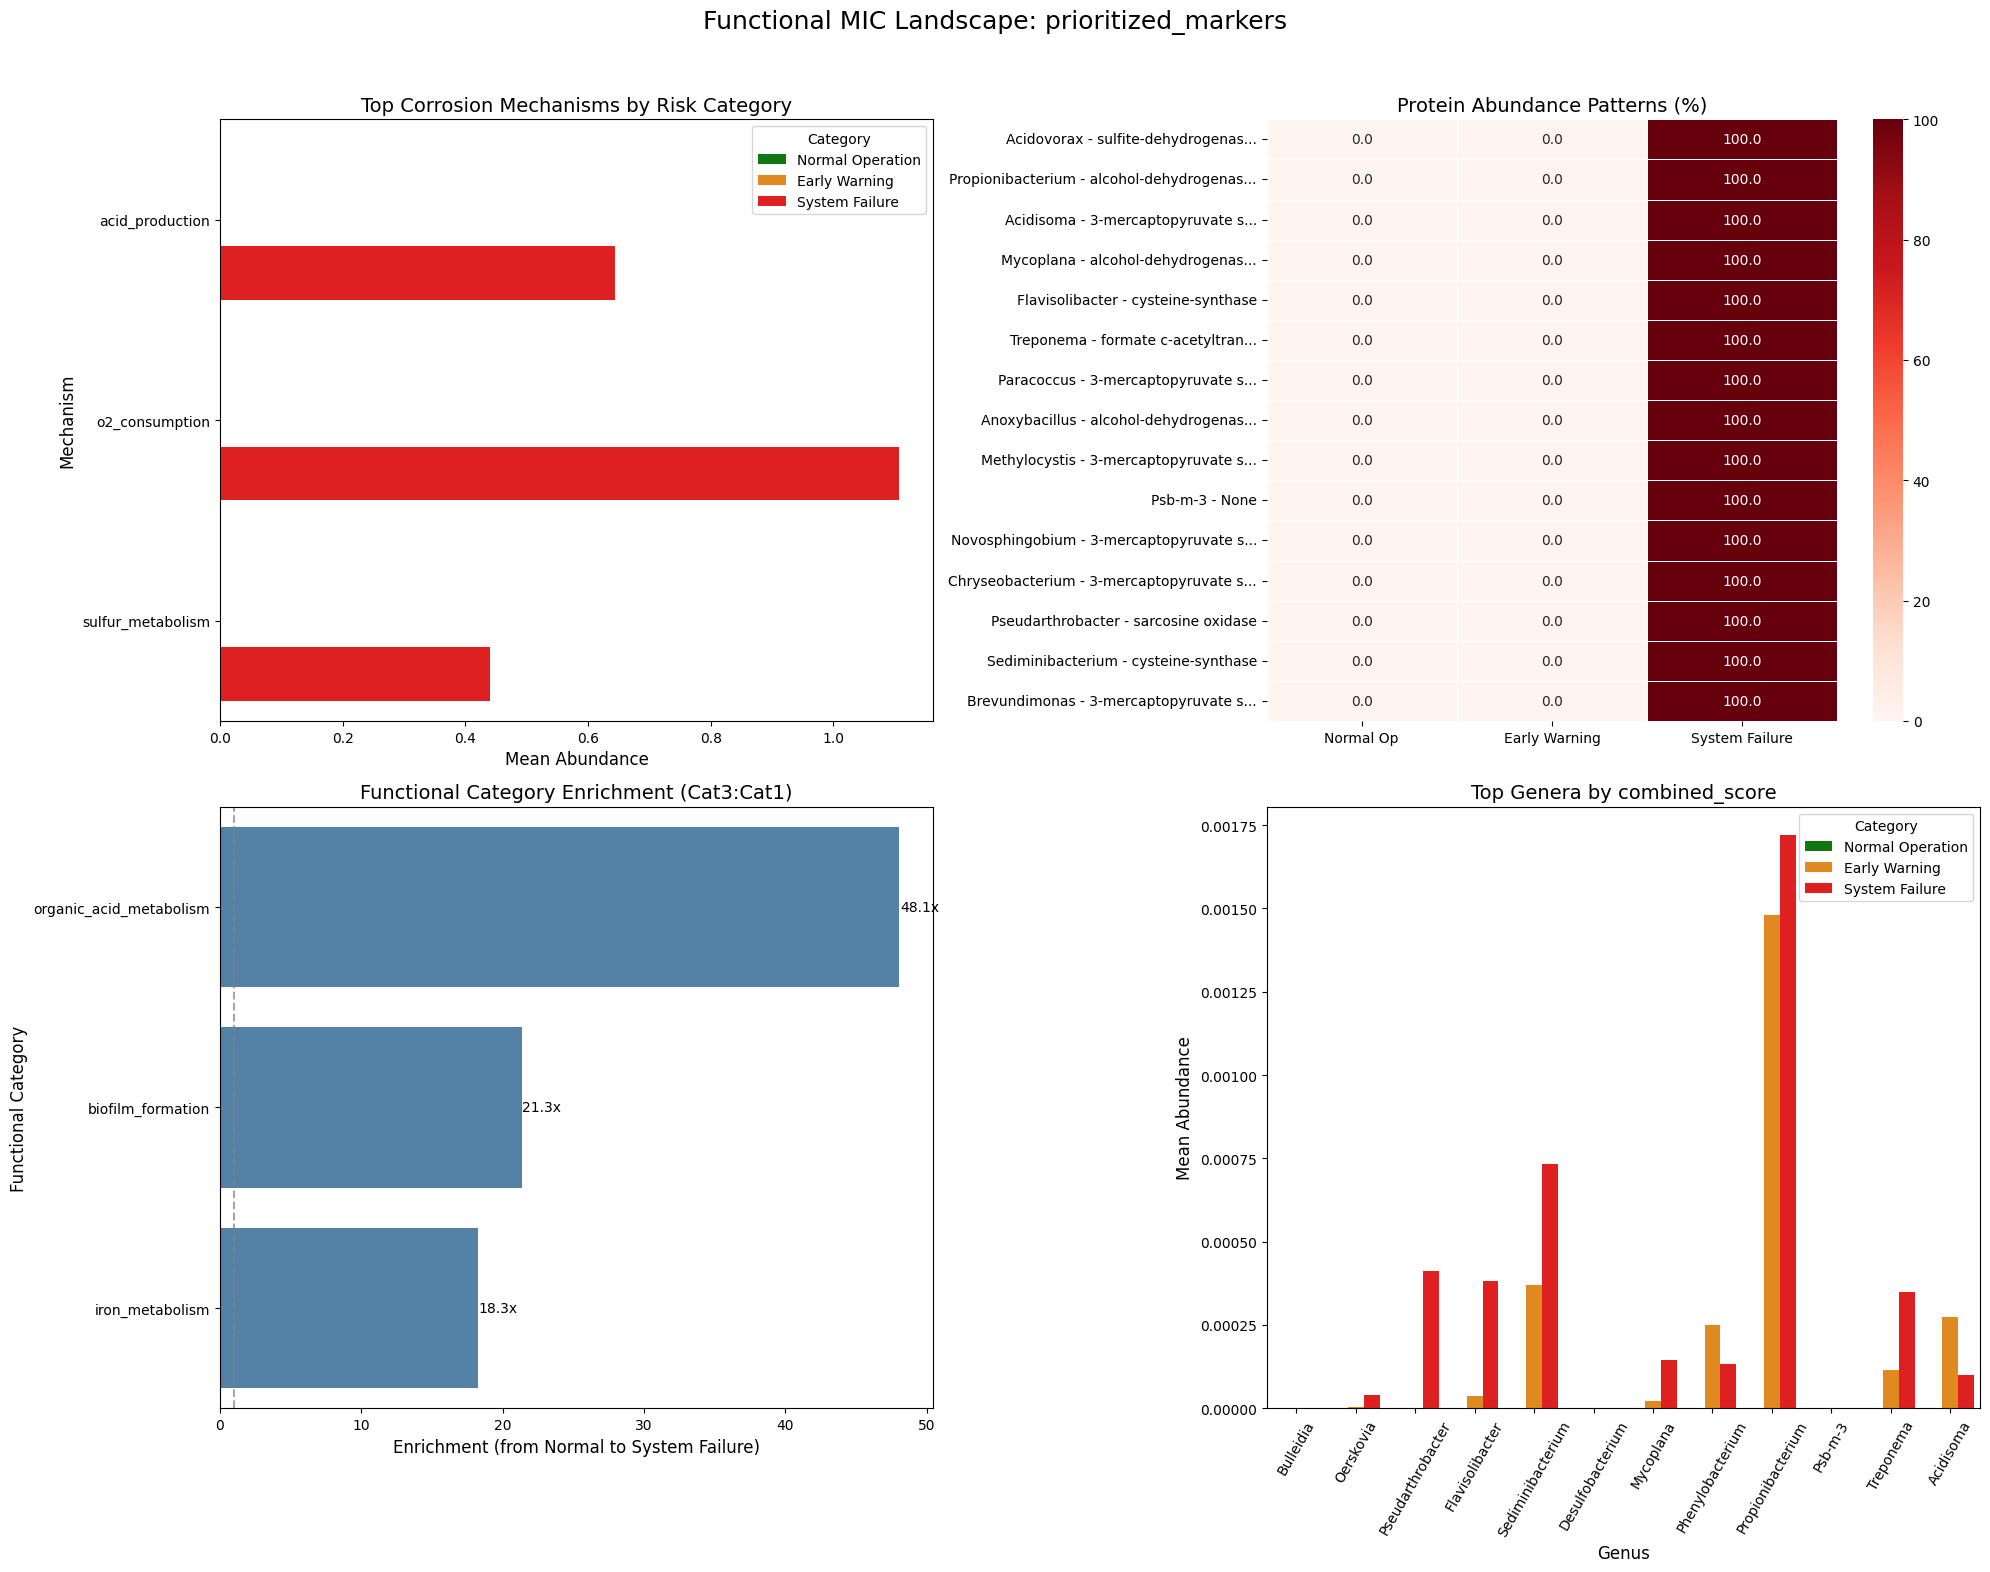

In [14]:
plot_multiview_functional_landscape(prioritized_markers,"prioritized_markers",  score_col="combined_score")
output_path = data_visual / "1_land.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
#plt.close()

The prioritized_markers dataset (n=849769) represents a subset of microbial functional markers associated with corrosion risk, derived from rigorous multi-stage filtering and enrichment analysis. Starting from 1.39 million protein-genus pairs across 70 sampling sites, markers were first classified by abundance patterns across three corrosion severity categories (normal operation, early warning, system failure), retaining only those exhibiting significant increasing trends with corrosion severity (n=1,009,299). These candidates were then integrated with comprehensive metadata from BRENDA, MetalPDB, and KEGG databases to assign functional categories, metal-binding properties, metabolic pathways, and corrosion mechanisms to each marker. Pathway specificity analysis classified markers as either ubiquitous (present across all sites) or niche-specific (site-adapted), with 87% showing niche specificity. The subset has only the increasing patterns from paar genus-protein. There are two plots each of which have 4 subplots.  The second plot in for the group high corrosion relevance,  correspond to a subset of the data with 199 markers. These have been further selected protein-genus pairs exceeding site-specific knee-point abundance thresholds while maintaining taxonomic diversity through balanced representation (top 10 markers per genus) and furhter reduction to obtain this group of high corrosion relevance.The comparative analysis using the plot_multiview_functional_landscape function reveals distinct metabolic shifts between the broader prioritized_markers group and the refined high corrosion relevance subset.  Metabolic Profiles (Top Left Subplots): In the larger prioritized group, aerobic respiration emerges as the dominant mechanism, followed by organic acid metabolism and sulfur metabolism. Conversely, the high corrosion relevance subset exhibits a significant decrease in acid production. This shift suggests that while aerobic respiration and sulfur-related processes are widespread in the initial stages, the high_corrosion_relevance group is less focused on these pioneer species and more aligned with markers of severe, advanced corrosion, dominated by acid production followed by oxigen consumption and biofilm formation. In this focused subset, acid production becomes the primary metabolism, followed by oxygen consumption and iron metabolism. The functional landscape of the high level group is dominated by mercaptopyruvate-related markers, alongside formate C-acetyltransferase, cysteine synthetase,  alcohol dehydrogenase and other diverse proteins. In contrast, the more specific group high_corrosion_relevance is characterized by a higher prevalence of formate C-acetyltransferase, and less differsification to cysteine desulfurase, assimilatory sulfite, and sulfite dehydrogenase. Enrichment patterns also diverge significantly between the two datasets. The general prioritized group shows strong enrichment in organic acid, biofilm and iron metabolism. For the filtered high-relevance group, the prevailing functions shift toward organic acid, methanogenesis, and iron metabolism. The dominant genera also reflect this refinement. While Propionibacterium is a highlight of the first group, the more specific high-relevance subset is driven by Dechloromonax and Desulfovibrio.

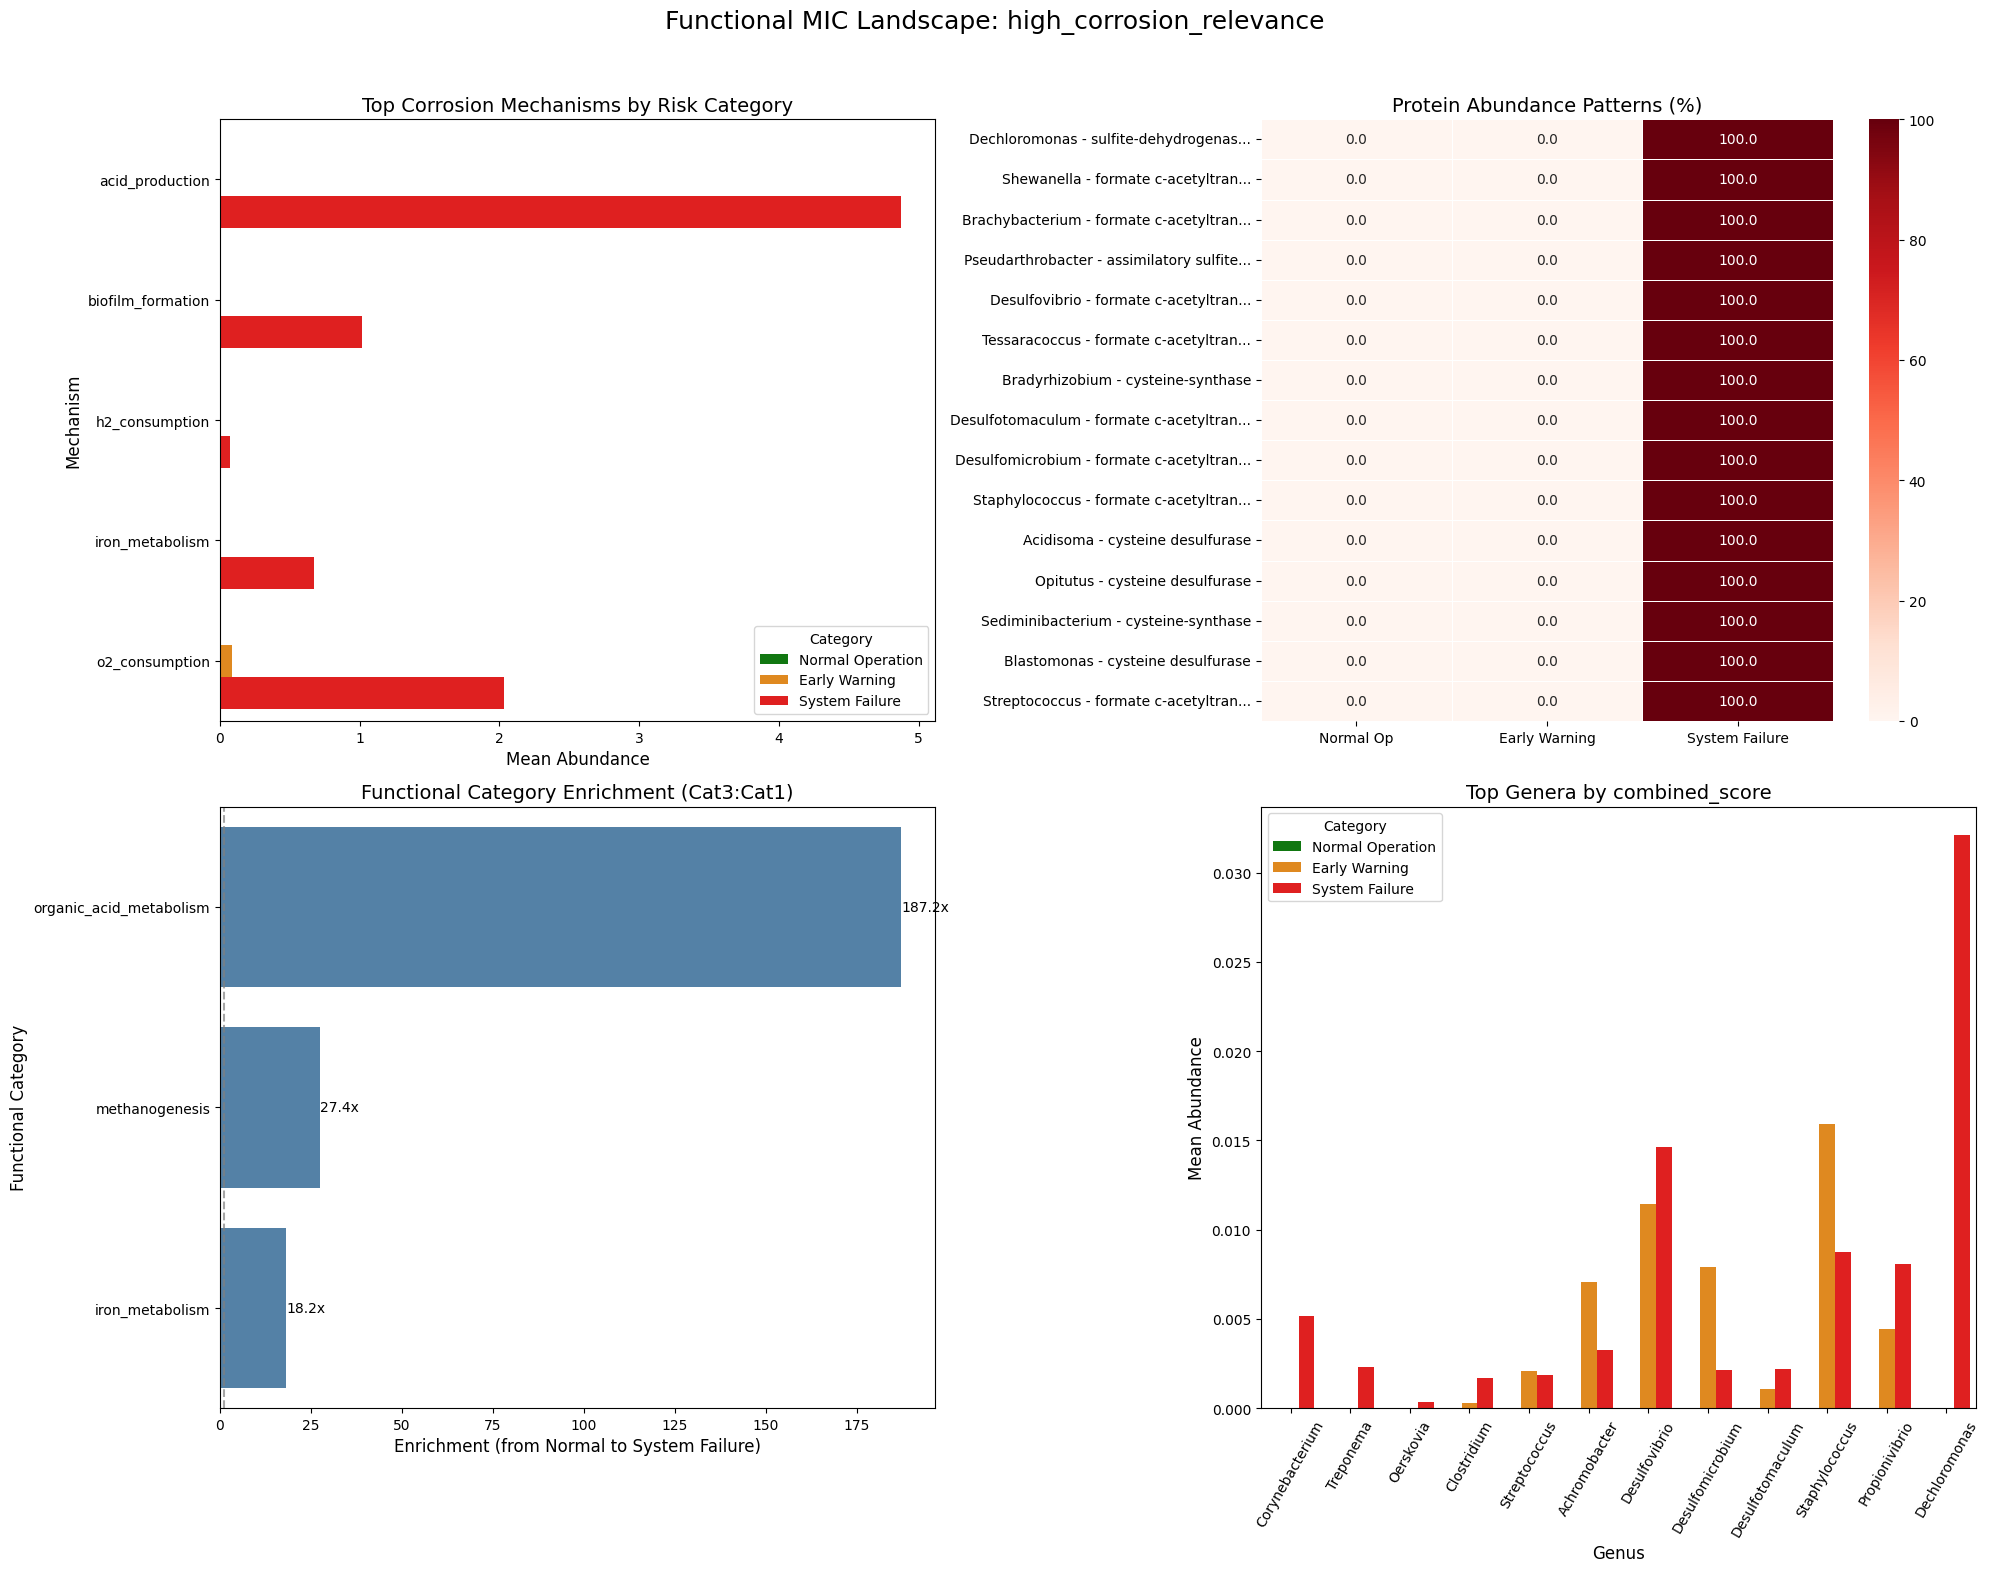

In [15]:
plot_multiview_functional_landscape(high_corrosion_relevance,"high_corrosion_relevance",  top_n=50, score_col="combined_score")
output_path = data_visual / "2_land.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight') 
#plt.close()

## 3.2. Comparison of Mechanism by Category methodology

In [16]:
def corrosion_mechanism_original_vs_mean(top_markers, name="Comparison", top_n=10):
    """
    Create a comparison plot showing corrosion mechanisms using:
    1. Original Category (left subplot)
    2. Mean categories (right subplot)
    
    Parameters:     top_markers : DataFrame   containing the data with columns:   Category, corrosion_mechanisms, norm_abund_contri, mean_cat1, mean_cat2, mean_cat3
    name : str, optional to include in the plot title, by default "Comparison"
    top_n : int, optional    Number of top mechanisms to display, by default 10
    save_path : str, optional    Path to save the output figure, by default None
        
    Returns:  fig : matplotlib.figure.Figure  
    """
    
    # Define colors for mean categories
    mean_colors = {
        'mean_cat1': '#008800',  # Dark green
        'mean_cat2': '#FF8C00',  # Dark orange
        'mean_cat3': '#FF0000'   # Red
    }
    
    # Mean category labels for the legend
    mean_labels = {
        'mean_cat1': 'Normal Operation (Mean)',
        'mean_cat2': 'Early Warning (Mean)',
        'mean_cat3': 'System Failure (Mean)'
    }
    
    # Select top markers by score
    top_markers = top_markers.copy(deep=False)
    
    # Ensure Category is there and integer type to prevent mapping issues
    if not 'Category' in top_markers.columns:
        top_markers['Category'] = top_markers['Sites'].map(category_dict)
    top_markers['Category'] = pd.to_numeric(top_markers['Category'].astype('int8'))
    
    # Create figure with multiple subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # 1. FIRST PLOT: Original Category (left)
    mech_by_category = []
    for _, row in top_markers.iterrows():
        if isinstance(row.get('mechanisms_sub'), str) and row['mechanisms_sub'] and pd.notna(row['norm_abund_contri']):
            mechanisms = [row['mechanisms_sub']]
            for mech in mechanisms:
                if mech:  # Ensure mechanism is not empty
                    mech_by_category.append({
                        'Mechanism': mech,
                        'Category': int(row['Category']),  # Ensure integer type
                        'norm_abund_contri': row['norm_abund_contri']
                    })
    
    # Convert to DataFrame and aggregate
    mech_df = pd.DataFrame(mech_by_category)
    
    # Check if we have mechanisms data to plot
    if not mech_df.empty:
        # Group by mechanism and original category, summing abundance
        agg_mech = mech_df.groupby(['Mechanism', 'Category'])['norm_abund_contri'].sum().reset_index(name='Abundance')
        
        # Sort by abundance and get top mechanisms
        top_mechanisms = agg_mech.groupby('Mechanism')['Abundance'].sum().nlargest(top_n).index
        agg_mech = agg_mech[agg_mech['Mechanism'].isin(top_mechanisms)]
        
        # Create the plot with consistent category colors
        sns.barplot(
            data=agg_mech,
            x='Abundance',
            y='Mechanism',
            hue='Category',
            palette=category_colors,
            ax=ax1
        )
        
        # Ensure legend shows categories with proper labels
        handles, labels = ax1.get_legend_handles_labels()
        ax1.legend(handles=handles, labels=[categories_labels[int(label)] for label in labels])
        ax1.set_title(f"Top Corrosion Mechanisms - {name}\nBy Original Category", fontsize=14)
        ax1.set_xlabel('Abundance', fontsize=12)
        ax1.set_ylabel('Mechanism', fontsize=14)
    else:
        ax1.text(0.5, 0.5, "No mechanism data available", ha='center', va='center', fontsize=14)
        ax1.set_title('Top Corrosion Mechanisms by Original Category', fontsize=14)
    
    # 2. SECOND PLOT: Mean categories (right)
    mech_by_mean = []
    for _, row in top_markers.iterrows():
        if isinstance(row.get('mechanisms_sub'), str) and row['mechanisms_sub'] and pd.notna(row['norm_abund_contri']):
            mechanisms = [row['mechanisms_sub']]
            
            # Get mean values
            mean_cat1 = row.get('mean_cat1', 0)
            mean_cat2 = row.get('mean_cat2', 0)
            mean_cat3 = row.get('mean_cat3', 0)
            
            for mech in mechanisms:
                if mech:  # Ensure mechanism is not empty
                    # Add entry for each category with its corresponding mean value
                    mech_by_mean.append({
                        'Mechanism': mech,
                        'Mean_Category': 'mean_cat1',
                        'Abundance': mean_cat1 * row['norm_abund_contri']
                    })
                    mech_by_mean.append({
                        'Mechanism': mech,
                        'Mean_Category': 'mean_cat2',
                        'Abundance': mean_cat2 * row['norm_abund_contri']
                    })
                    mech_by_mean.append({
                        'Mechanism': mech,
                        'Mean_Category': 'mean_cat3',
                        'Abundance': mean_cat3 * row['norm_abund_contri']
                    })
    
    # Convert to DataFrame for mean categories
    mean_mech_df = pd.DataFrame(mech_by_mean)
    
    # Second plot - mean categories
    if not mean_mech_df.empty:
        # Use the same top mechanisms as in the first plot for consistency
        # Aggregate by mechanism and mean category
        agg_mean_mech = mean_mech_df.groupby(['Mechanism', 'Mean_Category'])['Abundance'].sum().reset_index()
        
        # Filter to the same top mechanisms from the first plot for consistency
        agg_mean_mech = agg_mean_mech[agg_mean_mech['Mechanism'].isin(top_mechanisms)]
        
        # Create the plot with mean category colors
        sns.barplot(
            data=agg_mean_mech,
            x='Abundance',
            y='Mechanism',
            hue='Mean_Category',
            palette=mean_colors,
            ax=ax2
        )
        
        # Update legend with readable mean category labels
        handles, labels = ax2.get_legend_handles_labels()
        ax2.legend(handles=handles, labels=[mean_labels[label] for label in labels])
        
        ax2.set_title(f"Top Corrosion Mechanisms - {name}\nBy Mean Categories", fontsize=14)
        ax2.set_xlabel('Abundance', fontsize=14)
        ax2.set_ylabel('', fontsize=14)  
    else:
        ax2.text(0.5, 0.5, "No mechanism data available", ha='center', va='center', fontsize=14)
        ax2.set_title('Top Corrosion Mechanisms by Mean Categories', fontsize=14)
    
    plt.tight_layout(pad=2)
    
    return fig

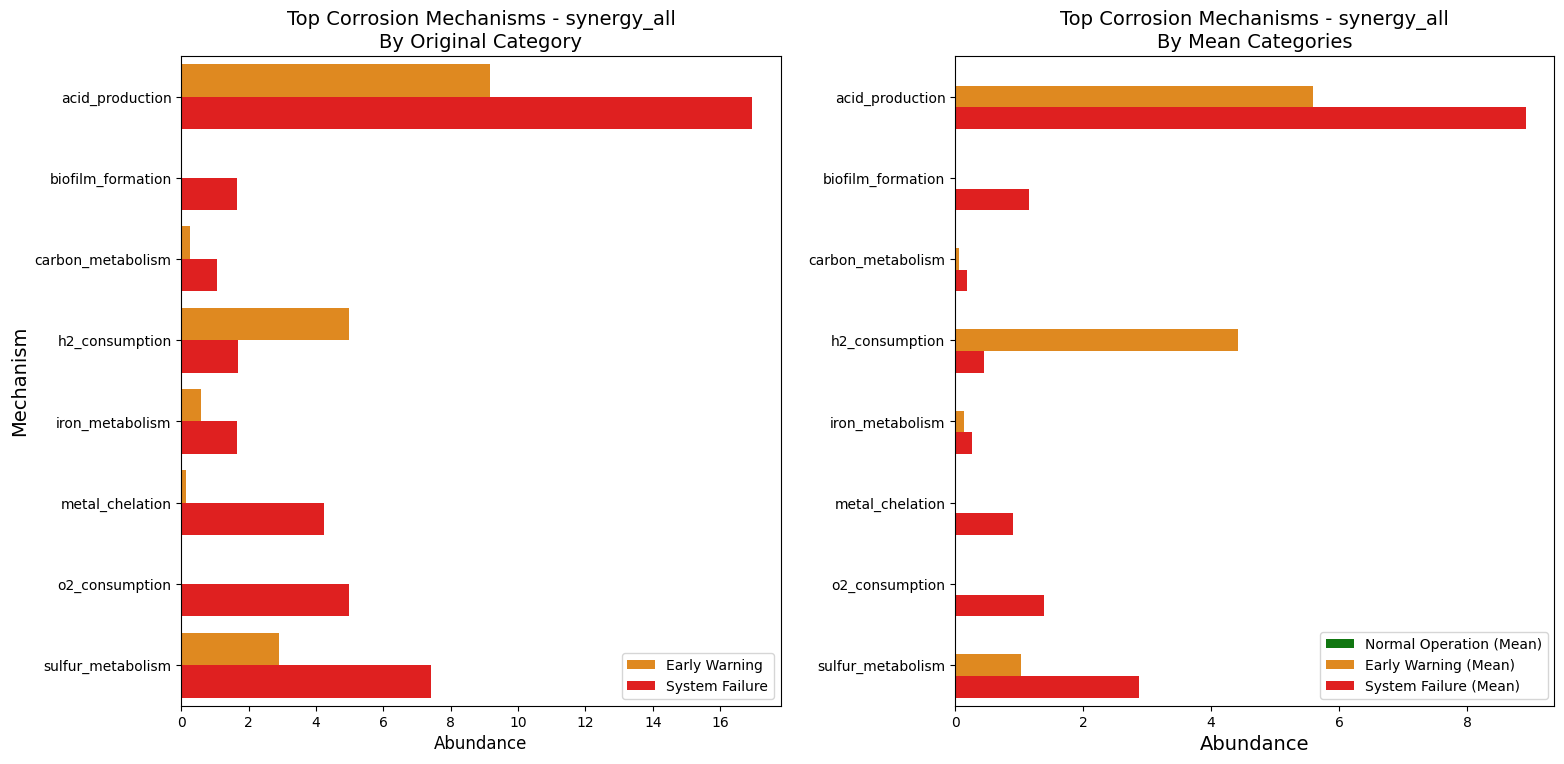

In [17]:
#Calling the function:
fig = corrosion_mechanism_original_vs_mean(synergy_all, "synergy_all",  top_n=150)

output_path = data_visual / "3_mech.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
#plt.close()

This figure presents a quality control comparison of corrosion mechanism distributions in top_markers, contrasting original category stratification (left) against mean category aggregation (right). The left panel shows mechanism abundance as stacked bars for Early Warning (orange) and System Failure (red), with acid production dominating system failure conditions (n≈30). The right panel aggregates all three severity categories, demonstrating that proportional representation remains consistent: acid production maintains dominance (mean≈20), followed by oxygen consumption and sulfur metabolism at intermediate levels (mean≈7-8). This concordance validates the use of mean aggregation for downstream analyses, confirming that averaging across severity categories preserves the mechanistic hierarchy without introducing systematic bias.

## 3.3 Pathway Data across Risk Categories MultiPathway Analysis

In [18]:
def plot_pathway_analysis(data_df, name, top_n=100, score_col='combined_score', 
                         pathway_source='niche_specific_pathways'):
    """
    Comprehensive pathway analysis with improved visualizations.
    Uses EXPLODED columns (no splitting needed).
    
    Parameters:
    -----------
    pathway_source : str
        Column to use for pathway analysis. Options:
        - 'niche_specific_pathways' : Specific pathways from PICRUSt2
        - 'pathways' : All pathway child terms
        - 'functional_sub' : Functional subcategories (cleaner)
        - 'mechanisms_sub' : Mechanism subcategories
    """
    df = data_df.copy() 
    # Make copy and select top markers
    if 'pathways' in df.columns:
        # Apply the new single-value function across the entire 'pathways' Series
        df['pathways'] = df['pathways'].apply(rename_pathway_single)

    # Handle different scoring scenarios
    if score_col in df.columns:
        top_markers = df.sort_values(score_col, ascending=False).head(top_n)
    else:
        top_markers = df.sort_values('mean_cat3', ascending=False).head(top_n)
        print(f"Warning: {score_col} not found, using mean_cat3 for sorting")
    # change some names of the pathways rows on pathways column
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # === COLLECT PATHWAY DATA FROM EXPLODED COLUMN ===
    pathway_data = []
    
    # Check if pathway source column exists
    if pathway_source not in top_markers.columns:
        print(f"Error: Column '{pathway_source}' not found. Available columns: {top_markers.columns.tolist()}")
        return None, {}
    
    # Collect data - NO SPLITTING since columns are already exploded
    for _, row in top_markers.iterrows():
        pathway_val = row[pathway_source]
        
        # Filter out NaN, empty strings, and 'nan' strings
        if pd.notna(pathway_val) and str(pathway_val).strip() and str(pathway_val).strip().lower() != 'nan':
            pathway_data.append({
                'Category': str(pathway_val).strip(),
                'Genus': row.get('Genus', 'Unknown'),
                'Cat1': row.get('mean_cat1', 0),
                'Cat2': row.get('mean_cat2', 0), 
                'Cat3': row.get('mean_cat3', 0),
                'Score': row.get(score_col, 0)
            })
    
    if not pathway_data:
        print(f"No valid pathway data found in column '{pathway_source}'")
        fig.text(0.5, 0.5, f'No pathway data available in {pathway_source}', 
                ha='center', va='center', fontsize=16)
        return fig, {}
    
    pathway_df = pd.DataFrame(pathway_data)
    print(f"\nFound {len(pathway_df)} pathway entries from {pathway_df['Category'].nunique()} unique pathways")
    print(f"Top 10 pathways by frequency:")
    print(pathway_df['Category'].value_counts().head(10))
    
    # === PLOT 1: Pathway Category Distribution ===
    # Count occurrences and get top categories
    category_counts = pathway_df['Category'].value_counts().head(15)
    
    # Create horizontal bar plot
    sns.barplot(
        x=category_counts.values,
        y=category_counts.index,
        palette='viridis',
        hue=category_counts.index,
        ax=axes[0, 0], legend=False
    )
    
    # Add count labels
    for i, (cat, count) in enumerate(category_counts.items()):
        axes[0, 0].text(count + 0.5, i, str(count), 
                       va='center', ha='left', fontweight='bold', fontsize=10)
    
    axes[0, 0].set_title(f'Most Frequent Pathways ({pathway_source})', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Frequency in Top Markers', fontsize=12)
    axes[0, 0].set_ylabel('Pathway', fontsize=12)
    
    # === PLOT 2: Risk Category Progression ===
    # Aggregate by pathway category across risk levels
    risk_progression = pathway_df.groupby('Category')[['Cat1', 'Cat2', 'Cat3']].sum()
    # Normalize by number of proteins to make comparable across datasets
    n_proteins = len(pathway_df)
    risk_progression = risk_progression / n_proteins
    
    # Get top categories by Cat3 abundance
    top_categories = risk_progression.sort_values('Cat3', ascending=False).head(8)
    
    # Prepare data for line plot
    progression_data = []
    for category in top_categories.index:
        for i, (col, label) in enumerate(zip(['Cat1', 'Cat2', 'Cat3'], categories_labels)):
            progression_data.append({
                'Category': category,
                'Risk_Level': label,
                'Risk_Level_Num': i+1,
                'Abundance': top_categories.loc[category, col]
            })
    
    prog_df = pd.DataFrame(progression_data)
    
    # Create line plot showing progression
    for category in top_categories.index[:6]:  # Limit to 6 for readability
        cat_data = prog_df[prog_df['Category'] == category]
        axes[0, 1].plot(cat_data['Risk_Level_Num'], cat_data['Abundance'], 
                       marker='o', linewidth=2, markersize=8, 
                       label=category[:30] + ('...' if len(category) > 30 else ''))
    
    axes[0, 1].set_xticks([1, 2, 3])
    axes[0, 1].set_xticklabels(categories_labels, rotation=45, ha='right')
    axes[0, 1].set_ylabel('Mean Abundance', fontsize=12)
    axes[0, 1].set_title('Pathway Progression Across Risk Levels', fontsize=14, fontweight='bold')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)
    
    # === PLOT 3: Enrichment Analysis ===
    # Calculate enrichment ratios
    enrichment_data = pathway_df.groupby('Category').agg({
        'Cat1': 'sum',
        'Cat3': 'sum',
        'Score': 'mean'
    }).reset_index()
    # Normalize by dataset size
    n_proteins = len(pathway_df)
    enrichment_data['Cat1'] = enrichment_data['Cat1'] / n_proteins
    enrichment_data['Cat3'] = enrichment_data['Cat3'] / n_proteins
    
    # Calculate enrichment (Cat3:Cat1 ratio)
    enrichment_data['Enrichment'] = enrichment_data.apply(
        lambda x: (x['Cat3'] + 0.01) / (x['Cat1'] + 0.01), axis=1
    )
    
    # Filter for meaningful enrichment and get top enriched
    significant_enrichment = enrichment_data[
        (enrichment_data['Cat1'] > 0.01) | (enrichment_data['Cat3'] > 0.01)
    ].sort_values('Enrichment', ascending=False).head(12)
    
    if not significant_enrichment.empty:
        # Create enrichment plot with color coding
        colors = ['#d62728' if x > 2 else '#ff7f0e' if x > 1.5 else '#2ca02c' 
                 for x in significant_enrichment['Enrichment']]
        
        bars = axes[1, 0].barh(range(len(significant_enrichment)), 
                              significant_enrichment['Enrichment'],
                              color=colors, alpha=0.7)
        
        # Add enrichment value labels
        for i, (idx, row) in enumerate(significant_enrichment.iterrows()):
            axes[1, 0].text(row['Enrichment'] + 0.1, i, 
                           f"{row['Enrichment']:.1f}x",
                           va='center', ha='left', fontweight='bold', fontsize=10)
        
        axes[1, 0].set_yticks(range(len(significant_enrichment)))
        axes[1, 0].set_yticklabels([cat[:35] + ('...' if len(cat) > 35 else '') 
                                   for cat in significant_enrichment['Category']], fontsize=10)
        axes[1, 0].axvline(x=1, color='gray', linestyle='--', alpha=0.7, linewidth=2)
        axes[1, 0].set_xlabel('Enrichment Ratio (from Normal to System Failure)', fontsize=12)
        axes[1, 0].set_title('Pathway Enrichment in High Risk', fontsize=14, fontweight='bold')
        axes[1, 0].grid(axis='x', alpha=0.3)
    
    # === PLOT 4: Genus-Pathway Network ===
    if len(pathway_df) > 10:
        # Create network graph
        G = nx.Graph()
        
        # Get top genera and pathways
        top_genera = pathway_df['Genus'].value_counts().head(10).index
        top_pathways = pathway_df['Category'].value_counts().head(12).index
        
        # Add nodes
        for genus in top_genera:
            genus_score = pathway_df[pathway_df['Genus'] == genus]['Score'].mean()
            G.add_node(f"G_{genus}", node_type='genus', score=genus_score)
        
        for pathway in top_pathways:
            pathway_score = pathway_df[pathway_df['Category'] == pathway]['Score'].mean()
            # Truncate long pathway names
            pathway_short = pathway[:25] if len(pathway) > 25 else pathway
            G.add_node(f"P_{pathway_short}", node_type='pathway', score=pathway_score)
        
        # Add edges based on co-occurrence
        edge_weights = defaultdict(int)
        for _, row in pathway_df.iterrows():
            if row['Genus'] in top_genera and row['Category'] in top_pathways:
                genus_node = f"G_{row['Genus']}"
                pathway_short = row['Category'][:25] if len(row['Category']) > 25 else row['Category']
                pathway_node = f"P_{pathway_short}"
                edge_weights[(genus_node, pathway_node)] += 1
        
        # Add edges to graph
        for (u, v), weight in edge_weights.items():
            if weight > 0:  # Show all connections
                G.add_edge(u, v, weight=weight)
        
        if len(G.nodes()) > 0 and len(G.edges()) > 0:
            # Layout with better spacing
            pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
            
            # Draw nodes
            genus_nodes = [n for n in G.nodes() if n.startswith('G_')]
            pathway_nodes = [n for n in G.nodes() if n.startswith('P_')]
            
            if genus_nodes:
                nx.draw_networkx_nodes(G, pos, nodelist=genus_nodes, 
                                     node_color='lightcoral', node_size=1000,
                                     alpha=0.8, ax=axes[1, 1])
            
            if pathway_nodes:
                nx.draw_networkx_nodes(G, pos, nodelist=pathway_nodes,
                                     node_color='lightblue', node_size=800,
                                     alpha=0.8, ax=axes[1, 1])
            
            # Draw edges with varying thickness
            edges = G.edges()
            if edges:
                weights = [G[u][v]['weight'] for u, v in edges]
                max_weight = max(weights) if weights else 1
                nx.draw_networkx_edges(G, pos, width=[w/max_weight * 3 for w in weights],
                                     alpha=0.5, ax=axes[1, 1])
            
            # Draw labels with better formatting
            labels = {n: n[2:18] + ('...' if len(n) > 20 else '') for n in G.nodes()}
            nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=axes[1, 1])
            
            axes[1, 1].set_title('Genus-Pathway Network\n(Red=Genera, Blue=Pathways)', 
                               fontsize=14, fontweight='bold')
        
        axes[1, 1].axis('off')
    
    # Overall styling
    plt.suptitle(f"Pathway Analysis: {name} (source: {pathway_source})", 
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Return results
    results = {
        'pathway_df': pathway_df,
        'category_counts': category_counts,
        'enrichment_data': enrichment_data,
        'top_categories': top_categories
    }
    
    return fig, results


Found 49 pathway entries from 5 unique pathways
Top 10 pathways by frequency:
Category
superpathway of N-acetylneuraminate degradation            38
S. of sulfide oxidation                                    5 
superpathway of sulfur oxidation (Acidianus ambivalens)    3 
S. of sulfur metabolism                                    2 
creatinine degradation II                                  1 
Name: count, dtype: int64


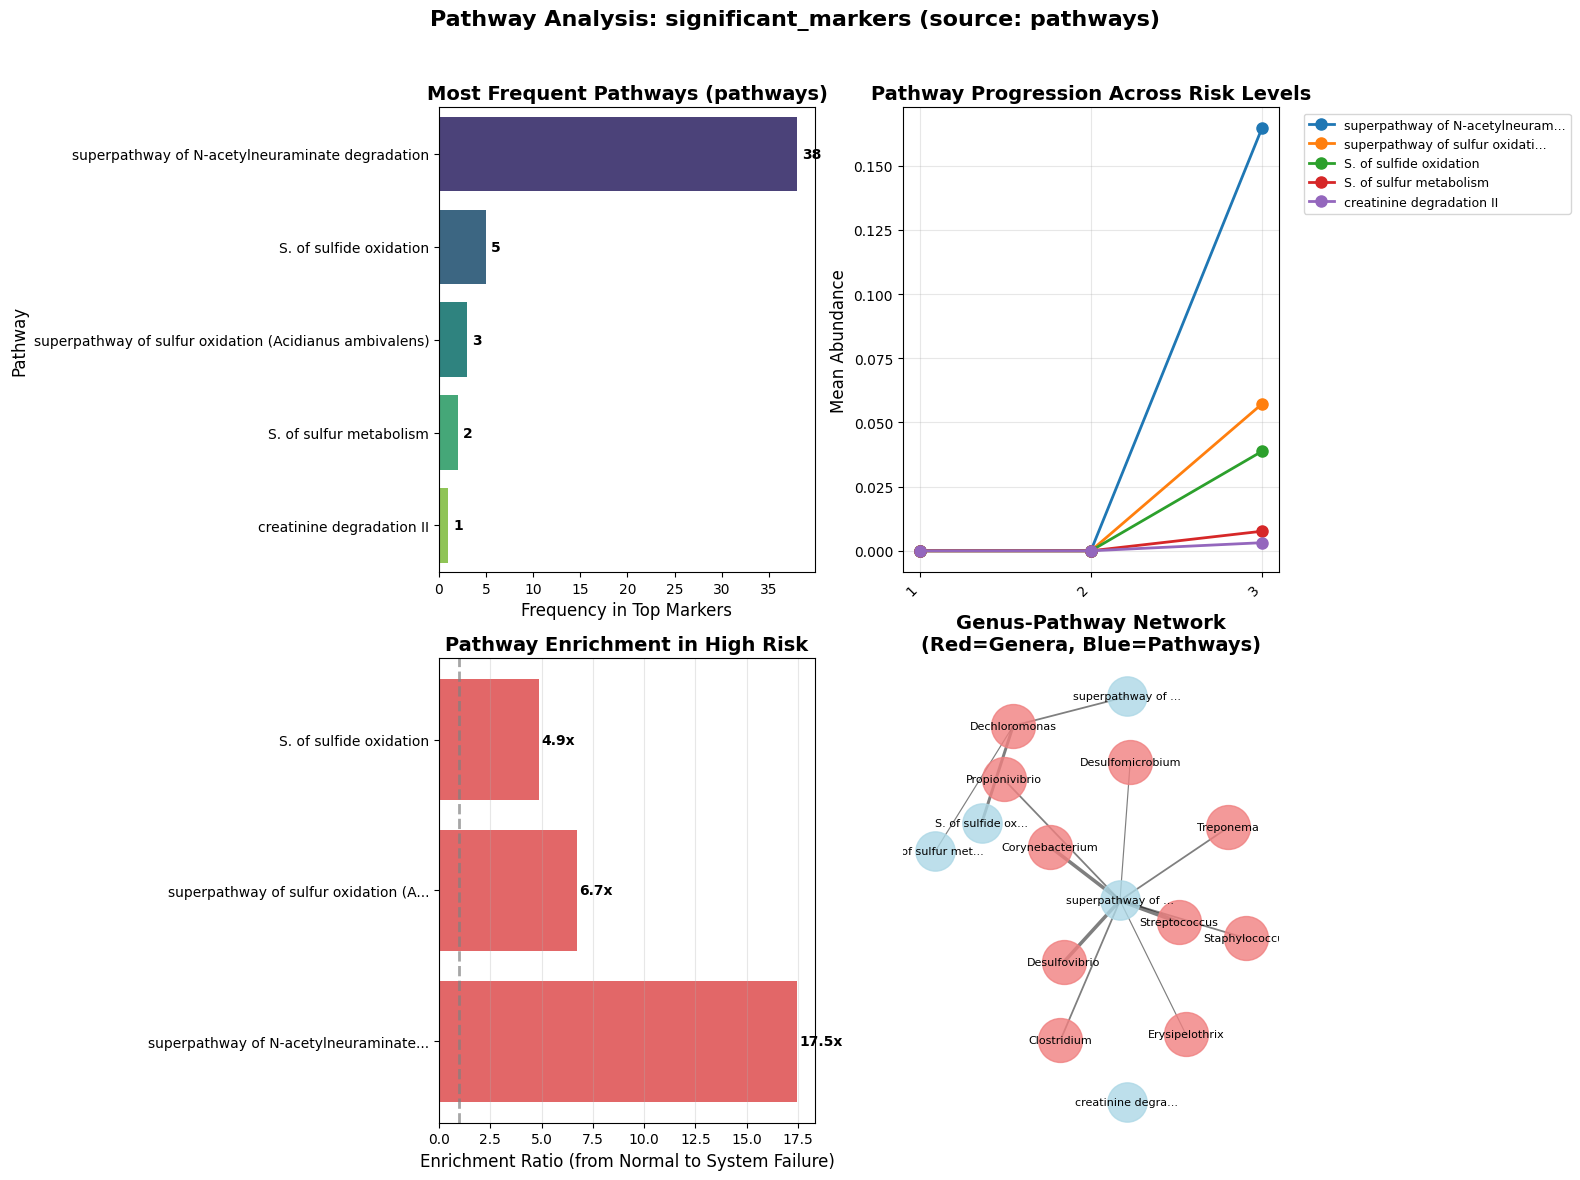

<Figure size 640x480 with 0 Axes>

In [19]:
fig, results = plot_pathway_analysis(significant_markers, "significant_markers", top_n=100, score_col='combined_score', 
                                     pathway_source='pathways')

output_path = data_visual / "4_pathws.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

The plot back on repo 2_Micro, Notebook 6_picrust_functional, section 7.3, showed the distribution of pathway abundances where aerobic respiration and glycolysis dominated. In the contrast this plot presents pathway-level functional enrichment analysis for the significant_markers (n=195), revealing specialized metabolic profiles distinct from the universal housekeeping pathways observed in the unfiltered dataset. The significant markers group shows failure conditions:  superpathway of N-acetylneuraminate degradation (n=38), representing sialic acid catabolism typically associated with host-associated and biofilm-forming bacteria. This is followed by superpathway of sulfide oxidation (n=5) and superpathway of sulfur oxidation from Acidianus ambivalens (n=3). The progression panel (top right) reveals a striking pattern where all pathways show essentially zero abundance in Categories 1 and 2, with sharp increases only in Category 3 (system failure), highlighting the success of the filtering applied to the data. N-acetylneuraminate degradation rises to just under 0.18 mean abundance, followed by sulfide oxidation at around 0.06 and sulfur metabolism and creatinine degradation at still lower levels, indicating late-stage corrosion markers with threshold‑dependent activation rather than gradual progression. The enrichment panel (bottom left) quantifies this severity association, with N-acetylneuraminate degradation showing 17.5× enrichment, sulfide oxidation at 6.7×, and sulfur oxidation at 4.9× relative to normal operating conditions. The genus–pathway network (bottom right) shows that several genera act as hubs connected to multiple pathways, consistent with functional redundancy where the same taxa can exploit several failure‑associated pathways.


Found 92 pathway entries from 9 unique pathways
Top 10 pathways by frequency:
Category
S. of Branched-Chain Amino Acid Biosynthesis               36
S. of CDP-diacylglycerol Biosynthesis                      22
superpathway of L-alanine biosynthesis                     8 
biotin biosynthesis II                                     8 
biotin biosynthesis I                                      7 
S. of sulfide oxidation                                    5 
superpathway of sulfur oxidation (Acidianus ambivalens)    3 
S. of sulfur metabolism                                    2 
aspartate superpathway                                     1 
Name: count, dtype: int64


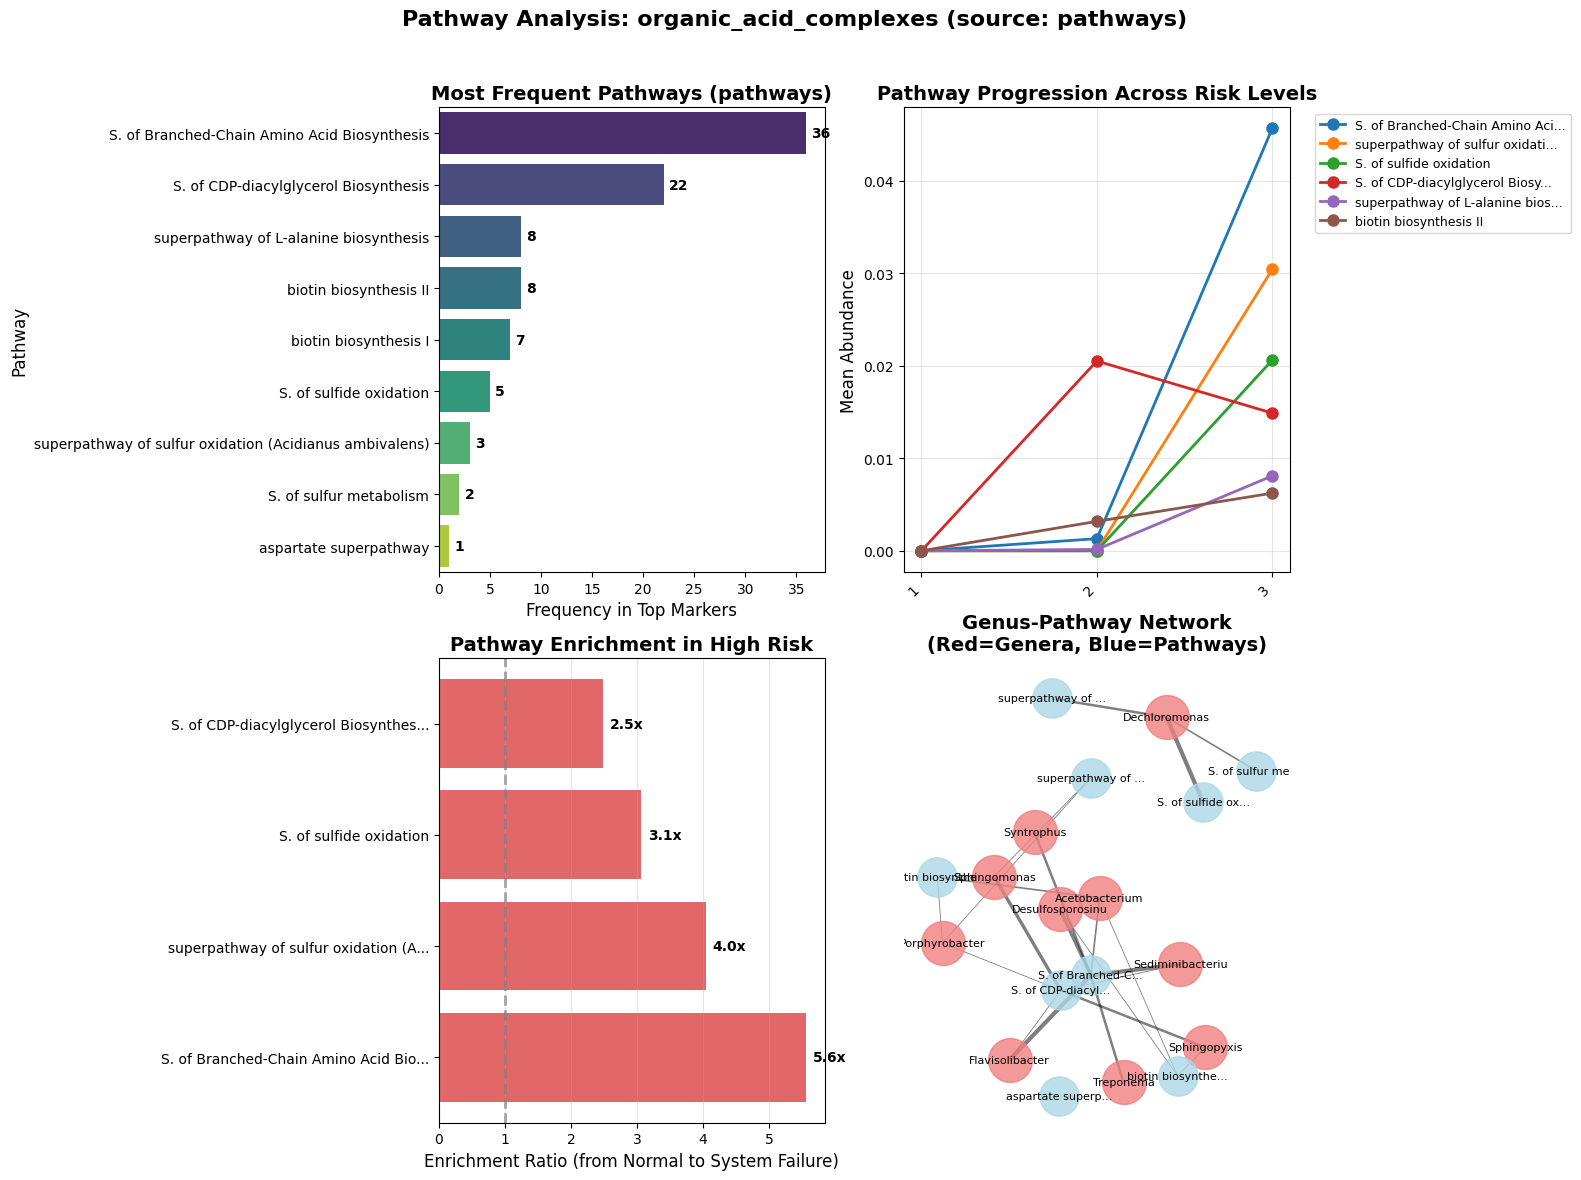

<Figure size 640x480 with 0 Axes>

In [20]:
fig, results = plot_pathway_analysis(high_metals_relevance, "organic_acid_complexes", top_n=200, score_col='combined_score', 
                                     pathway_source='pathways')

output_path = data_visual / "4_pathways_organic.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
#plt.close()

Pathway analysis for the organic_acid_complexes group (Repository 3_combined, 1_visual_protein.ipynb, section 3.3) reveals a metabolic profile dominated by the superpathway of branched‑chain amino acid biosynthesis, which appears at substantially higher frequency than all other pathways combined. This dominance of branched‑chain amino acid synthesis, alongside CDP‑diacylglycerol biosynthesis and UDP‑GlcA biosynthesis, suggests the biofilm community is simultaneously investing in amino acid production, membrane lipid precursors, and exopolysaccharide‑related sugar nucleotides.
The progression panel reveals an interesting divergence from the significant_markers group. Here, branched‑chain amino acid biosynthesis and related anabolic pathways (UDP‑GlcA and CDP‑diacylglycerol biosynthesis, glycerol degradation) already show clear increases in Category 2 and then reach maximum levels in Category 3, rather than a purely threshold‑like jump. This suggests the organic_acid_complexes community establishes its biosynthetic program during the early warning phase and intensifies as conditions deteriorate.
The enrichment ratios are notably lower than in the significant_markers group, with branched‑chain amino acid biosynthesis reaching about 5.0× enrichment, sulfur oxidation 3.7×, sulfide oxidation 2.8×, and the remaining pathways around 2.2–2.4×. This likely reflects the larger size of the organic_acid_complexes group diluting the signal with additional pathways that show more moderate enrichment patterns. The genus‑pathway network reveals a small number of genera that connect to multiple pathways, forming major hubs of association between particular bacteria and several of these organic‑acid‑linked functions, which will be investigate further.​
THe Organic_acid_complexes group (biofilm/organic‑acid niche) This group represents a subset of communities defined by organic acid chemistry, and its pathway profile is dominated by branched‑chain amino acid biosynthesis, L‑isoleucine and alanine pathways, CDP‑diacylglycerol and UDP‑sugar biosynthesis, plus glycerol and butanol/glycerol‑degradation routes.
These pathways support de novo amino‑acid production, membrane phospholipid synthesis and exopolysaccharide precursors, all of which are required for dense, surface‑attached biofilms in low‑pH, organic‑acid‑rich environments.
The temporal pattern (already active in intermediate‑risk Category 2, then increasing in Category 3) suggests this module marks early establishment and subsequent thickening of an organic‑acid biofilm, rather than appearing only at catastrophic failure.
Across all groups analyses, the same functional “spine” keeps reappearing:
sialic‑acid degradation (N‑acetylneuraminate pathways),
S. of CDP-diacylglycerol Biosynthesis , L-Isoleucine biosynthesis II, superpathway of L-alanine biosynthesis, biotin biosynthesis I and II, superpathway of L-alanine biosynthesis, 
CDP‑diacylglycerol and UDP‑sugar biosynthesis,
and sulfur/sulfide oxidation. 

This combination links host/matrix sugar scavenging, amino‑acid and membrane/exopolysaccharide anabolism, and redox‑active sulfur metabolism.

## 3.4. Temporal Transition and Mechanisms Distribution by Risk Categories

In [21]:
def temporal_transition(prioritized_markers: pd.DataFrame, name: str, weight_mode: str = "composite", normalize: bool = True,
                        category_dict: dict = None, abundance_col: str = "norm_abund_contri") -> go.Figure:
    """ Create a Sankey diagram: mechanism -> dominant risk category.
    Parameters    - prioritized_markers: DataFrame with columns: 'mechanisms_sub', 'mean_cat1','mean_cat2','mean_cat3', 'significance_score', 'max_abs_log2fc'
        and an abundance column (e.g., 'norm_abund_contri')
    - name: title suffix for the figure
    - weight_mode: 'composite' (default), 'composite_abs', 'significance', 'magnitude', 'counts'
      - composite: normalized product of (sig * mag * abundance)
      - composite_abs: normalized sig and mag, multiplied by ABSOLUTE abundance from abundance_col
      - significance: use significance_score alone
      - magnitude: use max_abs_log2fc alone
      - counts: each row contributes 1
    - normalize: if True, min-max normalization is applied to sig/mag when used. If normalize=False and weight_mode='composite', raw columns are multiplied.
    - category_dict: optional mapping Sites -> Category (used if 'Category' missing)
    - abundance_col: column name to use as the absolute abundance input 
    Returns: Plotly Figure (always a Figure; never None)
    """

    df = prioritized_markers.copy(deep=False)
    if isinstance(normalize, str):
        normalize = normalize.strip().lower() in ('1', 'true', 't', 'yes', 'y')
    def _empty_fig(title, message):
        fig = go.Figure()
        fig.update_layout(
            title=title,
            annotations=[dict(text=message, showarrow=False, x=0.5, y=0.5, xref='paper', yref='paper')]
        )
        return fig
    #category_dict = dict(zip(Integrated_T.index, Integrated_T["Category"].values))

    # Ensure Category exists or map if possible
    if 'Category' not in df.columns and category_dict is not None and 'Sites' in df.columns:
        df['Category'] = df['Sites'].map(category_dict)

    # Required mean columns
    required_mean_cols = ['mean_cat1', 'mean_cat2', 'mean_cat3']
    if not all(c in df.columns for c in required_mean_cols):
        return _empty_fig("No Sankey: missing mean_cat columns",
                          "Missing one of mean_cat1 / mean_cat2 / mean_cat3")

    # Compute dominant category (same logic as before)
    df['dominant_category_col'] = df[required_mean_cols].idxmax(axis=1)
    df['dominant_category'] = df['dominant_category_col'].map({
        'mean_cat1': 'Category 1',
        'mean_cat2': 'Category 2',
        'mean_cat3': 'Category 3'
    })
    df['dominant_value'] = df[required_mean_cols].max(axis=1)

    # Mechanism column
    if 'mechanisms_sub' not in df.columns and 'mechanisms' not in df.columns:
        return _empty_fig("No Sankey: missing mechanisms column",
                          "No 'mechanisms_sub' or 'mechanisms' column found.")
    mech_col = 'mechanisms_sub' if 'mechanisms_sub' in df.columns else 'mechanisms'

    # Check significance/magnitude
    if 'significance_score' not in df.columns:
        return _empty_fig("No Sankey: missing significance_score",
                          "Missing 'significance_score' column.")
    if 'max_abs_log2fc' not in df.columns:
        df['max_abs_log2fc'] = df['dominant_value'].abs()

    # USE CATEGORY-SPECIFIC ABUNDANCE for flows
    # Instead of one abundance value, use the actual mean_cat value for the dominant category
    df['category_specific_abundance'] = df.apply(
        lambda row: row.get(row['dominant_category_col'], 0) if pd.notna(row.get('dominant_category_col')) else 0,
        axis=1
    )

    # This is the abundance that matches where the flow goes!
    raw_ab = df['category_specific_abundance']
    # Normalization helpers
    def _safe_minmax(s):
        s = pd.to_numeric(s, errors='coerce').fillna(0.0)
        mn, mx = s.min(), s.max()
        if mx == mn:
            # constant series -> return series of ones (or small positive) so composite doesn't zero-out
            if mx == 0:
                return s.fillna(0.0)
            return pd.Series(1.0, index=s.index)
        return (s - mn) / (mx - mn)

    #================================================
    # Ensure abundance is normalized or raw, ready for use
    if abundance_col in ('norm_abund_contri', 'frequency_score') and normalize:
        # Use existing normalized column or normalize it
        norm_ab = pd.to_numeric(df[abundance_col], errors='coerce').fillna(0.0)
    elif normalize:
        # Normalize any other abundance column
        norm_ab = _safe_minmax(df[abundance_col])
    else:
        # Use raw abundance if normalization is turned off
        norm_ab = pd.to_numeric(df[abundance_col], errors='coerce').fillna(0.0)
    #==================================================
    # 94. Compute weights according to requested mode
    if weight_mode == 'counts':
        df['flow_weight'] = 1.0
        # NEW ROBUST MODE: Average Quality * Raw Abundance
    elif weight_mode == 'weighted_flow':
        # 1. Normalize Significance and Magnitude (always 0-1)
        norm_sig = _safe_minmax(df['significance_score'])
        norm_mag = _safe_minmax(df['max_abs_log2fc'].abs())

        # 2. Calculate the average QUALITY score (normalized 0-1)
        avg_quality = (norm_sig + norm_mag) / 2.0
        
        # 3. Scale the quality by the RAW abundance contribution
        # This is the key: it uses absolute abundance (raw_ab) as the scale factor.
        df['flow_weight'] = avg_quality * raw_ab
        
    # Introduce the new, robust weighting mode
    elif weight_mode == 'averaged_composite':
        # Always normalize Sig and Mag for fairness in an average calculation
        norm_sig = _safe_minmax(df['significance_score'])
        norm_mag = _safe_minmax(df['max_abs_log2fc'].abs())
        
        # Calculate the AVERAGE of the three normalized components
        df['flow_weight'] = (norm_sig + norm_mag + norm_ab) / 3.0
    
    # Existing 'composite' mode (multiplication)
    elif weight_mode == 'composite':
        norm_sig = _safe_minmax(df['significance_score']) if normalize else pd.to_numeric(df['significance_score'], errors='coerce').fillna(0.0)
        norm_mag = _safe_minmax(df['max_abs_log2fc'].abs()) if normalize else df['max_abs_log2fc'].abs().astype(float)
        
        # This is the original, punitive multiplication:
        df['flow_weight'] = norm_sig * norm_mag * norm_ab 
        
    elif weight_mode == 'composite_abs': #================================================================
        # keep sig and mag normalized to 0..1, but multiply by the absolute abundance (raw)
        norm_sig = _safe_minmax(df['significance_score']) if normalize else pd.to_numeric(df['significance_score'], errors='coerce').fillna(0.0)
        norm_mag = (pd.to_numeric(df['max_abs_log2fc'], errors='coerce').abs().fillna(0.0) / 10.0).clip(0.0, 1.0) if normalize else df['max_abs_log2fc'].abs().astype(float)
        if abundance_col in ('norm_abund_contri', 'frequency_score'):
            norm_ab = pd.to_numeric(df[abundance_col], errors='coerce').fillna(0.0)
        else:
            norm_ab = _safe_minmax(df[abundance_col])
        df['flow_weight'] = norm_sig * norm_mag * norm_ab

    elif weight_mode == 'absolute_flow':
        # NO NORMALIZATION - uses raw values for cross-dataset comparison
        raw_sig = pd.to_numeric(df['significance_score'], errors='coerce').fillna(0.0)
        raw_mag = pd.to_numeric(df['max_abs_log2fc'], errors='coerce').fillna(0.0).abs()
        
        # Simple average of raw scores times raw abundance
        df['flow_weight'] = ((raw_sig + raw_mag) / 2.0) * raw_ab

    else:
        return _empty_fig("No Sankey: unknown weight_mode",
                          f"Unknown weight_mode '{weight_mode}'. Supported: counts, significance, magnitude, composite, composite_abs")

    df['flow_weight'] = df['flow_weight'].fillna(0.0)

    # Build mechanisms set and order
    mechanisms_set = set(df[mech_col].dropna().unique().tolist())
    if len(mechanisms_set) == 0:
        return _empty_fig("No Sankey: no mechanisms", "All mechanisms_sub values are NA or empty.")

    mechanism_order = [
        "o2_consumption",           # +820 mV, highest energy yield
        "nitrogen_metabolism",      # +750 to +420 mV (NO3- → NO2- → N2O → N2)
        "iron_metabolism",          # +770 mV (Fe3+ → Fe2+), but lower than N compounds
        "manganese_metabolism",     # +500 mV (Mn4+ → Mn2+), but less common
        "sulfur_metabolism",        # +150 to -240 mV (SO4^2- → SO3^2- → S0 → H2S)
        "h2_consumption",           # -420 mV (H+ → H2), but couples with other acceptors
        "carbon_metabolism",        # -240 to -280 mV (CO2 → organics)
        "acid_production",          # Metabolic byproduct, not primary energy
        "metal_chelation",          # Binding process, minimal energy requirement
        "biofilm_formation",        # Structural process, energy cost not yield     
    ]
    mechanisms = [m for m in mechanism_order if m in mechanisms_set]
    other_mechs = sorted(list(mechanisms_set - set(mechanisms)))
    mechanisms.extend(other_mechs)

    categories = ['Category 1', 'Category 2', 'Category 3']
    all_nodes = mechanisms + categories
    node_indices = {n: i for i, n in enumerate(all_nodes)}

    # Construct flows (one mechanism string per row)
    flow_rows = []
    for _, r in df.iterrows():
        mech = r.get(mech_col)
        tgt = r.get('dominant_category')
        if pd.isna(mech) or pd.isna(tgt):
            continue
        if mech not in node_indices or tgt not in node_indices:
            continue
        flow_rows.append({'source': mech, 'target': tgt, 'value': float(r['flow_weight'])})

    flow_df = pd.DataFrame(flow_rows)
    if flow_df.empty:
        return _empty_fig("No Sankey: no valid flows",
                          "After filtering, no mechanism→category flows could be constructed.")

    agg = flow_df.groupby(['source', 'target'], as_index=False)['value'].sum()

    # Diagnostics
    print("Distribution by dominant category:", df['dominant_category'].value_counts().to_dict())
    print("Unique mechanisms:", len(mechanisms_set), "Aggregated flows:", len(agg), f"Total weight: {agg['value'].sum():.4f}")
    #category_colors = {1: '#008800',  2: '#FF8C00', 3: '#FF0000'}   # Red

    #categories_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}

    # get the colormap object (single-arg API)
    cmap = colormaps.get_cmap('viridis')

    n = len(mechanisms)
    if n == 0:
        mech_colors = {}
    elif n == 1:
        mech_colors = {mechanisms[0]: rgb2hex(cmap(0.0)[:3])}
    else:
        mech_colors = {
            m: rgb2hex(cmap(i / (n - 1))[:3])  # evenly spaced colors on [0,1]
            for i, m in enumerate(mechanisms)
        }

    category_name_to_num = {'Category 1': 1, 'Category 2': 2, 'Category 3': 3}
    node_colors = [mech_colors.get(node, '#9467bd') if node in mechanisms
                 else category_colors.get(category_name_to_num.get(node, 1), '#1f77b4') for node in all_nodes]
    
    agg['source_idx'] = agg['source'].map(node_indices)
    agg['target_idx'] = agg['target'].map(node_indices)

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
            hovertemplate="<b>%{label}</b><extra></extra>"
        ),
        link=dict(
            source=agg['source_idx'],
            target=agg['target_idx'],
            value=agg['value'],
            hovertemplate="<b>%{source.label}</b> → <b>%{target.label}</b><br>Weight: %{value:.3f}<extra></extra>"
        )
    )])

    fig.update_layout(
        title_text=f"Mechanisms → Risk Categories (weights={weight_mode}; abundance_col={abundance_col}) — {name}",
        title_font_size=16,
        font_size=13,
        height=800,
        width=1200,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    return fig

In [22]:
fig = temporal_transition(balanced_markers, "balanced_markers",
        weight_mode='counts',            #     "counts",  "composite", "composite_abs"       # use absolute abundance in composite
        abundance_col='norm_abund_contri',   #  or any column with abundance
        normalize=False,                      # True for min-max on sig/mag but keep abundance raw (see below)
        category_dict=category_dict, 
    )
fig.show()
output_path = data_visual / "10_sankey.png"
fig.write_image(output_path, width=1200, height=800)

"""Notes: - "composite" (default) = norm(significance) * norm(magnitude) * norm(Frequency)  (all min-max normalized)
 - "composite_abs" = norm(significance) * norm(magnitude) * ABS_ABUNDANCE
     -> ABS_ABUNDANCE is taken from abundance_col (no min-max on abundance by default, preserving absolute abundance)
 - For product of raw values (no normalization at all), pass normalize=False with weight_mode="composite".
 - Matplotlib colormap usage uses matplotlib.colormaps.get_cmap to avoid deprecation warnings."""

Distribution by dominant category: {'Category 3': 474, 'Category 2': 182}
Unique mechanisms: 8 Aggregated flows: 16 Total weight: 615.0000


'Notes: - "composite" (default) = norm(significance) * norm(magnitude) * norm(Frequency)  (all min-max normalized)\n - "composite_abs" = norm(significance) * norm(magnitude) * ABS_ABUNDANCE\n     -> ABS_ABUNDANCE is taken from abundance_col (no min-max on abundance by default, preserving absolute abundance)\n - For product of raw values (no normalization at all), pass normalize=False with weight_mode="composite".\n - Matplotlib colormap usage uses matplotlib.colormaps.get_cmap to avoid deprecation warnings.'

In [23]:
fig = temporal_transition(top_markers, "top_markers",
        weight_mode='counts',            #     "counts",  "composite", "composite_abs" 
        abundance_col='norm_abund_contri',   #  or any column with abundance
        normalize= True,                      # True for min-max on sig/mag but keep abundance raw (see below)
        category_dict=category_dict, 
    )
fig.show()
output_path = data_visual / "11_sankey.png"
fig.write_image(output_path, width=1200, height=800)

Distribution by dominant category: {'Category 3': 127, 'Category 2': 37}
Unique mechanisms: 6 Aggregated flows: 8 Total weight: 164.0000


acid productions
biofilm formation

The Sankey diagram for balanced_markers (n=779 protein-genus pairs across 85 genera) reveals the distribution of corrosion mechanisms across risk categories, reflecting an ecological succession model dominated by mid-to-late stage metabolic profiles. Category 3 (system failure) captures the majority of mechanism flows, with biofilm formation accounting for approximately one-third of all transitions and organic acid metabolism representing the second most prevalent mechanism. This distribution pattern indicates that the dataset predominantly reflects systems in active fermentative metabolism for this group which is already filtered. In contrat the plot of the more narrowed filtered group namely high corrosion relevance notably, contains less markers with oxigen consumption metabolism, and in comparison to the first group the acid production increases, whiles the biofilm formation decreased. High-energy mechanisms (O2 consumption, nitrogen metabolism, iron metabolism, sulfur metabolism) show relatively more representation on the first plot, and in the second the systems have progressed to more stable less energy metabolisms.  Category 3 (System Failure) exhibits exclusive enrichment in specialized anaerobic pathways sulfur metabolism, H2 consumption, and there is a predilection of acid formation mechanims The mechanism hierarchy arranged by redox potential (O2 > N > Fe > S > H2 > C) demonstrates a thermodynamic progression where acid production and biofilm formation, as lower-energy structural processes, accumulate as metabolic endpoints rather than primary energy-yielding reactions. This pattern supports a succession model: aerobic respiration (underrepresented) → fermentative acid production (Category 3 dominant) → anaerobic respiration (Category 3 exclusive), with the 85-genera filtered dataset capturing communities that have established mature, metabolically diverse consortia characteristic of chronic MIC conditions in industrial water systems.

## 3.5. Functional Categories Distribution across Risk Category

In [24]:
def plot_functional_distribution(prioritized_markers, name):
    """
    Creates stacked bar charts showing functional category distribution across risk categories.
    Uses existing mean columns, summing across proteins per category.
    """
    category_colors = {1: '#2E7D32', 2: '#F57C00', 3: '#D32F2F'}   
    categories_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}
    
    # Use functional_sub as the column
    functional_data = []
    for _, row in prioritized_markers.iterrows():
        if pd.notna(row['functional_sub']) and row['functional_sub']:
            functional_category = row['functional_sub']
            
            functional_data.append({
                'functional': functional_category,
                'mean_cat1': row.get('mean_cat1', 0),
                'mean_cat2': row.get('mean_cat2', 0),
                'mean_cat3': row.get('mean_cat3', 0)
            })
    
    if not functional_data:
        print("No functional category data available")
        return None
    
    # Convert to DataFrame
    functional_df = pd.DataFrame(functional_data)
    
    # Aggregate by functional category - SUM to get total contribution
    grouped = functional_df.groupby('functional', as_index=False).agg({
        'mean_cat1': 'sum',
        'mean_cat2': 'sum',
        'mean_cat3': 'sum'
    })
    
    # Calculate total abundance and get top 50
    grouped['total'] = grouped['mean_cat1'] + grouped['mean_cat2'] + grouped['mean_cat3']
    grouped = grouped.sort_values('total', ascending=False).head(50)
    
    # Prepare data for stacked bar chart
    data = []
    for risk_category in [1, 2, 3]:
        column_name = f'mean_cat{risk_category}'
        data.append(
            go.Bar(
                name=categories_labels[risk_category],
                x=grouped['functional'],
                y=grouped[column_name],
                text=grouped[column_name].round(2),
                textposition='auto',
                marker_color=category_colors[risk_category]
            )
        )
    
    # Create figure
    fig = go.Figure(data=data)
    
    # Update layout
    fig.update_layout(
        barmode='stack',
        title=f"Top 50 Functional Categories (sub Terms) for Group {name} by Risk Category",
        xaxis_title='Functional Categories',
        yaxis_title='Total Abundance',
        legend_title='Risk Category',
        hovermode='x',
        height=600,
        width=1000
    )
    
    return fig

In [25]:
fig = plot_functional_distribution(functional_all, "functional_all")

fun_path = data_visual / "11_func.png"
plt.savefig(str(fun_path), dpi=300, bbox_inches='tight')
fig.show()

<Figure size 640x480 with 0 Axes>

Functional_all represents the data classified by functional categories, the top 50 of them show to be involved mostly with organic acid metabolims and biofilm formation, followed by methanogenesis and iron metabolism. 

## 3.7  Dinamic Cluster Analysis UMAP visualizations colored by protein metadata 
_ former 3.6 A 
The dataset includes categorical features (e.g., functional categories, genus, or pathways) and numerical features (e.g., mean, abundance, fold change). UMAP uses the numerical features to calculate pairwise distances between samples and projects them into a two-dimensional space while preserving structural relationships (McInnes, Healy, & Melville, 2018). Each point represents a sample whose position reflects numerical similarity, and categorical annotations can be overlaid to reveal biological associations (Becht et al., 2019)

In [26]:
def create_enhanced_umap_dashboard(marker_data, category_dict):
    """
    Create interactive UMAP dashboard with biological context
    
    Parameters:
    marker_data: DataFrame with Genus-protein pairs and their features
    category_dict: Dictionary mapping Sites to risk Categories (1, 2, 3)
    """
    
    # Initialize the Dash app
    app = dash.Dash(__name__)
    marker_data = marker_data.copy(deep=False)
    
    # Define color schemes
    category_colors = {1: '#008800', 2: '#FF8C00', 3: '#FF0000'}
    categories_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}
    
    # Ensure Category column exists
    if 'Category' not in marker_data.columns and 'Sites' in marker_data.columns:
        marker_data['Category'] = marker_data['Sites'].map(category_dict)
    if 'pathways' in marker_data.columns:
        marker_data['pathways'] = marker_data['pathways'].apply(rename_pathway_single)
    
    # Define available numerical features for UMAP
    numerical_features = {
        'Abundance Patterns': ['mean_cat1', 'mean_cat2', 'mean_cat3'],
        'Fold Changes': ['log2fc_2vs1', 'log2fc_3vs2', 'log2fc_3vs1', 'max_abs_log2fc'],
        'Biological Scores': [
            'overall_functional_score',
            'overall_metal_score', 
            'overall_synergy_score',
            'corrosion_relevance_score',
            'pathways_score'
        ],
        'Statistical Metrics': [
            'significance_score',
            'p_value_score',
            'combined_score'
        ]
    }
    
    # Flatten and filter features that exist in data
    all_numerical_features = []
    for group, features in numerical_features.items():
        all_numerical_features.extend([f for f in features if f in marker_data.columns])
    
    # Default features for UMAP
    default_features = [
        'mean_cat1', 'mean_cat2', 'mean_cat3',
        'overall_functional_score',
        'overall_metal_score',
        'overall_synergy_score'
    ]
    default_features = [f for f in default_features if f in marker_data.columns]
    
    # Define categorical features for visualization
    categorical_options = []
    if 'Category' in marker_data.columns:
        categorical_options.append({'label': 'Risk Category', 'value': 'Category'})
    if 'functional_sub' in marker_data.columns:
        categorical_options.append({'label': 'Functional Sub', 'value': 'functional_sub'})
    if 'functional_child' in marker_data.columns:
        categorical_options.append({'label': 'Functional Child', 'value': 'functional_child'})
    if 'mechanisms_sub' in marker_data.columns:
        categorical_options.append({'label': 'Mechanism Sub', 'value': 'mechanisms_sub'})
    if 'synergy_child_list' in marker_data.columns:
        categorical_options.append({'label': 'synergy_child_list', 'value': 'synergy_child_list'})
    if 'pathways' in marker_data.columns:
        categorical_options.append({'label': 'Pathways', 'value': 'pathways'})
    if 'organic_complex' in marker_data.columns:
        categorical_options.append({'label': 'Organic Complexes', 'value': 'organic_complexes'})
    if 'inorganic_complex' in marker_data.columns:
        categorical_options.append({'label': 'Inorganic Complexes', 'value': 'inorganic_complexes'})
    if 'hierarchy' in marker_data.columns:
        categorical_options.append({'label': 'Hierarchy', 'value': 'hierarchy'})
    if 'enzyme_class' in marker_data.columns:
        categorical_options.append({'label': 'Enzyme Class', 'value': 'enzyme_class'})

    color_options = categorical_options # + continuous_options

    # Define size options
    size_options = [{'label': 'Uniform', 'value': 'uniform'}]
    if 'combined_score' in marker_data.columns:
        size_options.append({'label': 'Combined Score', 'value': 'combined_score'})
    if 'significance_score' in marker_data.columns:
        size_options.append({'label': 'Significance Score', 'value': 'significance_score'})
    if 'synergy_combi_score' in marker_data.columns:
        size_options.append({'label': 'Synergy Combined Score', 'value': 'synergy_combi_score'})
    if 'corrosion_relevance_score' in marker_data.columns:
        size_options.append({'label': 'Corrosion Relevance Score', 'value': 'corrosion_relevance_score'})
    
    app.layout = html.Div([
        html.H1("UMAP Projection of Protein-Genus Pairs with Biological Context", 
                style={'textAlign': 'center', 'marginBottom': 10, 'marginTop': 10}),
        #================= Control Panel =================
        ######
        # UMAP Parameters
        html.Div([
            html.H4("Parameters:", style={'marginBottom': 5}),
            html.Div([
                html.Div([
                    html.Label("Neighbors:", style={'fontSize': 12}),
                    dcc.Slider(id='n-neighbors', min=5, max=50, step=5, value=15,
                            marks={i: str(i) for i in [5, 15, 30, 50]}, tooltip={"placement": "bottom"}),
                ], style={'width': '30%', 'display': 'inline-block', 'marginRight': '3%'}),
                
                html.Div([
                    html.Label("Min Distance:", style={'fontSize': 12}),
                    dcc.Slider(id='min-dist', min=0.0, max=0.5, step=0.05, value=0.1,
                            marks={0: '0', 0.25: '0.25', 0.5: '0.5'}, tooltip={"placement": "bottom"}),
                ], style={'width': '30%', 'display': 'inline-block', 'marginRight': '3%'}),
                
                html.Div([
                    html.Label("Top N:", style={'fontSize': 12}),
                    dcc.Slider(id='top-n', min=20, max=500, step=20, value=100,
                            marks={20: '20', 100: '100', 300: '300', 500: '500'}, tooltip={"placement": "bottom"}),
                ], style={'width': '30%', 'display': 'inline-block'}),
            ]),
        ], style={'padding': 10, 'backgroundColor': '#f9f9f9', 'borderRadius': 5, 'marginBottom': 10}),

        # Visualization Controls
        html.Div([
            html.H4("Visualization:", style={'marginBottom': 5}),
            html.Div([
                html.Div([
                    html.Label("Color:", style={'fontSize': 12}),
                    dcc.Dropdown(
                        id='color-by',
                        options=color_options,
                        value='Category',
                        style={'width': '200px', 'fontSize': 12}
                    ),
                ], style={'display': 'inline-block', 'marginRight': 20}),
                
                html.Div([
                    html.Label("Size:", style={'fontSize': 12}),
                    dcc.Dropdown(
                        id='size-by',
                        options=size_options,
                        value='combined_score' if 'combined_score' in marker_data.columns else 'uniform',
                        style={'width': '200px', 'fontSize': 12}
                    ),
                ], style={'display': 'inline-block', 'marginRight': 20}),
                
                html.Div([
                    html.Button('Run UMAP', id='run-umap-btn', n_clicks=0,
                            style={'backgroundColor': '#4CAF50', 'color': 'white', 
                                    'padding': '8px 16px', 'fontSize': 14,
                                    'border': 'none', 'cursor': 'pointer', 'borderRadius': 4}),
                    html.Button('Find Clusters', id='find-clusters-btn', n_clicks=0,
                            style={'backgroundColor': '#2196F3', 'color': 'white',
                                    'padding': '8px 16px', 'fontSize': 14,
                                    'border': 'none', 'cursor': 'pointer', 'marginLeft': 10, 'borderRadius': 4}),
                ], style={'display': 'inline-block', 'verticalAlign': 'bottom'}),
            ]),
        ], style={'padding': 10, 'backgroundColor': '#f9f9f9', 'borderRadius': 5, 'marginBottom': 10}),
        # Feature Selection Panel
        html.Div([
            html.H4("UMAP Features:", style={'marginBottom': 5}),
            html.Div([
                html.Div([
                    html.Strong(group_name, style={'fontSize': 13, 'marginBottom': 5, 'display': 'block'}),
                    dcc.Checklist(
                        id=f'feature-group-{i}',
                        options=[{'label': f' {feat}', 'value': feat} 
                                for feat in features if feat in marker_data.columns],
                        value=[f for f in features if f in default_features and f in marker_data.columns],
                        style={'fontSize': 11}
                    )
                ], style={'width': '23%', 'display': 'inline-block', 'verticalAlign': 'top', 'marginRight': '2%'})
                for i, (group_name, features) in enumerate(numerical_features.items())
            ]),
        ], style={'padding': 10, 'backgroundColor': '#f9f9f9', 'borderRadius': 5, 'marginBottom': 10}),
        #=======================
                
        # Graph
        dcc.Loading(
            id="loading-umap",
            type="default",
            children=dcc.Graph(id='umap-plot', style={'height': '700px'}, config={'doubleClick': 'reset'})
        ),
        
        # Store components for data
        dcc.Store(id='umap-data'),
        dcc.Store(id='cluster-labels'),
        
        # Info panel
        html.Div(id='info-panel', 
                style={'marginTop': 20, 'padding': 20, 'backgroundColor': '#e8f4f8', 
                       'borderRadius': 5, 'fontSize': 14})
    ], style={'padding': 10, 'maxWidth': '1800px', 'margin': '0 auto'})
    
    @app.callback(
        [Output('umap-data', 'data'),
         Output('info-panel', 'children')],
        [Input('run-umap-btn', 'n_clicks')],
        [State(f'feature-group-{i}', 'value') for i in range(len(numerical_features))] +
        [State('n-neighbors', 'value'),
         State('min-dist', 'value'),
         State('top-n', 'value')]
    )
    def run_umap(n_clicks, *args):
        if n_clicks == 0:
            return None, "Configure features and parameters, then click 'Run UMAP Projection' to generate visualization"
        
        # Combine selected features from all groups
        selected_features = []
        for feature_list in args[:-3]:  # All except last 3 args (which are parameters)
            if feature_list:
                selected_features.extend(feature_list)
        
        n_neighbors, min_dist, top_n = args[-3:]
        
        if not selected_features or len(selected_features) < 2:
            return None, "⚠️ Please select at least 2 numerical features for UMAP projection"
        
        # Get top N data
        data_subset = marker_data.head(int(top_n)).copy()
        
        # Extract feature matrix
        try:
            X = data_subset[selected_features].values
        except KeyError as e:
            return None, f"⚠️ Feature not found in data: {e}"
        
        # Handle missing values
        if np.isnan(X).any():
            X = np.nan_to_num(X, nan=0.0)
        
        # Standardize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # UMAP projection
        try:
            reducer = umap.UMAP(
                n_neighbors=int(n_neighbors),
                min_dist=float(min_dist),
                n_components=2,
                random_state=42,
                verbose=False
            )
            embedding = reducer.fit_transform(X_scaled)
        except Exception as e:
            return None, f"⚠️ UMAP failed: {str(e)}"
        
        # Store results
        data_subset['umap_1'] = embedding[:, 0]
        data_subset['umap_2'] = embedding[:, 1]
        
        info_text = html.Div([
            html.Strong("✓ UMAP Projection Complete"),
            html.Br(),
            f"Observations: {len(data_subset)} Genus-protein pairs",
            html.Br(),
            f"Features used: {len(selected_features)} numerical features ({', '.join(selected_features[:5])}{'...' if len(selected_features) > 5 else ''})",
            html.Br(),
            f"Parameters: n_neighbors={n_neighbors}, min_dist={min_dist}"
        ])
        
        return data_subset.to_json(date_format='iso', orient='split'), info_text
    
    @app.callback(
        Output('cluster-labels', 'data'),
        [Input('find-clusters-btn', 'n_clicks')],
        [State('umap-data', 'data')]
    )
    def find_clusters(n_clicks, umap_json):
        if n_clicks == 0 or umap_json is None:
            return None
        
        data = pd.read_json(umap_json, orient='split')
        
        # DBSCAN clustering on UMAP coordinates
        clustering = DBSCAN(eps=0.5, min_samples=3)
        clusters = clustering.fit_predict(data[['umap_1', 'umap_2']].values)
        
        return clusters.tolist()
    
    @app.callback(
        Output('umap-plot', 'figure'),
        [Input('umap-data', 'data'),
         Input('cluster-labels', 'data'),
         Input('color-by', 'value'),
         Input('size-by', 'value')]
    )
    def update_plot(umap_json, clusters, color_by, size_by):
        print(f"DEBUG: color_by = {color_by}, size_by = {size_by}")  # Debug line
        
        if umap_json is None:
            # Empty plot with instructions
            fig = go.Figure()
            fig.add_annotation(
                text="Click 'Run UMAP Projection' to begin<br>Select numerical features above",
                xref="paper", yref="paper",
                x=0.5, y=0.5, showarrow=False,
                font=dict(size=18, color='#666')
            )
            fig.update_layout(
                xaxis=dict(showgrid=False, showticklabels=False, zeroline=False),
                yaxis=dict(showgrid=False, showticklabels=False, zeroline=False),
                height=800
            )
            return fig
        
        data = pd.read_json(umap_json, orient='split')
        
        # Add clusters if available
        if clusters is not None:
            data['Cluster'] = clusters
            data['Cluster'] = data['Cluster'].astype(str)
            data.loc[data['Cluster'] == '-1', 'Cluster'] = 'Noise'
        
        # Create hover text
        data['hover_text'] = (
            '<b>Genus:</b> ' + data['Genus'].astype(str) + '<br>' +
            '<b>Protein:</b> ' + data['protein_name'].astype(str) + '<br>' +
            '<b>Function:</b> ' + data['functional_sub'].fillna('N/A').astype(str) + '<br>' +
            '<b>Score:</b> ' + data['combined_score'].round(2).astype(str) + '<br>' +
            '<b>Risk:</b> ' + data['Category'].astype(str)
        )
        
        # Prepare size
        if size_by == 'uniform':
            size_values = None
        else:
            if size_by in data.columns:
                size_values = data[size_by].fillna(0)
                # Normalize to reasonable range
                if size_values.max() > size_values.min():
                    size_values = (size_values - size_values.min()) / (size_values.max() - size_values.min()) * 40 + 10
                else:
                    size_values = 25
            else:
                size_values = None
        
        # Create figure
        fig = go.Figure()
        
        # Handle coloring based on color_by selection
        if color_by == 'Category':
            # Risk category with specific colors
            for cat_num, cat_color in category_colors.items():
                mask = data['Category'] == cat_num
                if mask.any():
                    fig.add_trace(go.Scatter(
                        x=data.loc[mask, 'umap_1'],
                        y=data.loc[mask, 'umap_2'],
                        mode='markers',
                        marker=dict(
                            size=size_values[mask] if size_values is not None else 10,
                            color=cat_color,
                            line=dict(width=0.5, color='DarkSlateGrey')
                        ),
                        hovertext=data.loc[mask, 'hover_text'],
                        hovertemplate='%{hovertext}<extra></extra>',
                        name=categories_labels[cat_num]
                    ))
        
        elif color_by in data.columns:
            # Check if continuous or categorical
            if data[color_by].dtype in ['float64', 'float32', 'int64', 'int32']:
                # Continuous color scale
                fig.add_trace(go.Scatter(
                    x=data['umap_1'],
                    y=data['umap_2'],
                    mode='markers',
                    marker=dict(
                        size=size_values if size_values is not None else 10,
                        color=data[color_by],
                        colorscale='Viridis',
                        showscale=True,
                        colorbar=dict(title=color_by),
                        line=dict(width=0.5, color='DarkSlateGrey')
                    ),
                    hovertext=data['hover_text'],
                    hovertemplate='%{hovertext}<extra></extra>',
                    showlegend=False
                ))
            else:
                # Categorical - plot each category separately
                unique_vals = data[color_by].dropna().unique()
                # Limit to reasonable number of categories
                if len(unique_vals) > 20:
                    print(f"WARNING: {color_by} has {len(unique_vals)} categories - too many for effective visualization")
                
                for val in unique_vals[:20]:  # Limit to first 20 categories
                    mask = data[color_by] == val
                    if mask.any():
                        fig.add_trace(go.Scatter(
                            x=data.loc[mask, 'umap_1'],
                            y=data.loc[mask, 'umap_2'],
                            mode='markers',
                            marker=dict(
                                size=size_values[mask] if size_values is not None else 10,
                                line=dict(width=0.5, color='DarkSlateGrey')
                            ),
                            hovertext=data.loc[mask, 'hover_text'],
                            hovertemplate='%{hovertext}<extra></extra>',
                            name=str(val)
                        ))
        else:
            # Default single color
            fig.add_trace(go.Scatter(
                x=data['umap_1'],
                y=data['umap_2'],
                mode='markers',
                marker=dict(
                    size=size_values if size_values is not None else 10,
                    color='#1f77b4',
                    line=dict(width=0.5, color='DarkSlateGrey')
                ),
                hovertext=data['hover_text'],
                hovertemplate='%{hovertext}<extra></extra>',
                showlegend=False
            ))
        
        fig.update_layout(
            title=dict(
                text=f"UMAP Projection (colored by {color_by})",
                font=dict(size=18)
            ),
            height=800,
            hovermode='closest',
            xaxis_title='UMAP Dimension 1',
            yaxis_title='UMAP Dimension 2',
            plot_bgcolor='white',
            xaxis=dict(showgrid=True, gridcolor='#f0f0f0'),
            yaxis=dict(showgrid=True, gridcolor='#f0f0f0'),
            legend=dict(
                yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99
            )
        )
        
        return fig
    
    return app

# To run the dashboard:
app = create_enhanced_umap_dashboard(synergy_all, category_dict)
app.run(debug=True, port=8050)

The UMAP projection reveals biologically meaningful clustering patterns when combining abundance profiles (mean_cat3), biological relevance scores (functional, metal, synergy), and statistical metrics (significance, p-value, combined score). The separation by enzyme_class demonstrates that proteins group according to their catalytic mechanisms - oxidoreductases acting on CH-OH groups of donors form the largest distinct cluster, spatially separated from enzymes acting on peroxide as acceptor, sulfur groups, and CH-NH groups, with minimal mixing between classes. This spatial organization corresponds closely to functional_sub categories: carbon metabolism proteins overlap with CH-OH-acting enzymes, metal-binding proteins align with peroxide acceptors, and organic acid metabolism proteins cluster with sulfur-acting enzymes, reflecting the intrinsic relationship between catalytic activity and metabolic function. The dominance of mean_cat3 over mean_cat1 and mean_cat2 in driving separation is expected given that this analysis focuses on proteins enriched in high-risk environments (Category 3), where abundance in lower-risk categories approaches zero. Notably, the inclusion of statistical metrics proves essential for achieving clear separation - projections using only abundance patterns or biological scores alone produce substantially more overlap, suggesting that confidence measures (significance, p-value) capture orthogonal information about protein reliability as biomarkers. Synergistic interaction patterns (synergy_child_list) reveal additional complexity: proteins sharing the same functional category but different synergistic partners (e.g., carbon metabolism with versus without acetate-ferredoxin coupling) occupy distinct spatial regions, indicating that co-occurrence patterns encode mechanistic context beyond primary metabolic function. This multi-dimensional feature integration successfully resolves proteins into functionally coherent groups that reflect both biochemical activity and ecological context in corrosion environments.

## 3.8. Static  Cluster Analysis UMAP visualizations colored by protein metadata- static
The UMAP visualization presents the dimensional reduction of protein-genus pairs belonging to the high_biological_relevance group. This dimensionality reduction technique transforms the complex multivariate relationships between these pairs into a two-dimensional representation, allowing for the identification of clustering patterns and functional relationships.

In [27]:
def create_simple_umap_visualization(marker_data, name, top_n=20, 
    n_neighbors=30, min_dist=0.3, spread=1.5, point_size=40, random_state=42, category_dict=category_dict):
    """
    Creates a scaled UMAP visualization colored by dominant category.
    Includes parameter tuning for better separation and interpretability.
    """
    # Define category colors and labels
    category_colors = {1: '#008800', 2: '#FF8C00', 3: '#FF0000'}
    categories_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}
    # Get top N entries
    marker_data = marker_data.head(top_n).copy()
    # Ensure Category is there and integer type to prevent mapping issues
    if 'Category' in marker_data.columns:
        marker_data = marker_data.drop(columns="Category")

    marker_data = marker_data.drop_duplicates(subset=['Sites', 'Genus', 'protein_name'], keep='first')
    
    marker_data['Category'] = marker_data['Sites'].map(category_dict)
    marker_data['Category'] = pd.to_numeric(marker_data['Category'].astype('int8'))
    # Select and standardize numerical features
    numerical_cols = [col for col in marker_data.columns if col.startswith('mean_')]
    X = marker_data[numerical_cols].values
    X = StandardScaler().fit_transform(X)
    # Compute UMAP embedding with balanced parameters
    umap_model = umap.UMAP(
        n_neighbors=n_neighbors, 
        min_dist=min_dist,
        spread=spread,
        random_state=random_state
    )
    embedding = umap_model.fit_transform(X)
    # Create plot
    fig, ax = plt.subplots(figsize=(14, 10))
    dominant_cats = marker_data['Category'].values    
    colors = [category_colors.get(cat, '#000000') for cat in dominant_cats]
    # Scatter plot
    ax.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=point_size, alpha=0.6)

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               label=label, markersize=10)
        for color, label in zip(category_colors.values(), categories_labels.values())
    ]
    ax.legend(handles=legend_elements, title="Risk Category",
              bbox_to_anchor=(1.05, 1), loc='upper left')
    # Annotate selectively (avoid clutter)
    for i, (_, row) in enumerate(marker_data.iterrows()):
        label = f"{row['Genus']}-{str(row['protein_name'])[:10]}"
        if i % 3 == 0:  # label 1/3 points for readability
            ax.text(embedding[i, 0], embedding[i, 1], label,
                    fontsize=8, ha='right', va='top',
                    bbox=dict(facecolor='white', alpha=0.3, pad=0.6))
    # Titles and layout
    ax.set_title(f"UMAP Projection of Protein Data for group {name}", fontsize=16)
    ax.set_xlabel('UMAP Dimension 1', fontsize=14)
    ax.set_ylabel('UMAP Dimension 2', fontsize=14)
    plt.tight_layout()
    return fig

/home/beatriz/MIC/3_combined/.venv_combi/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



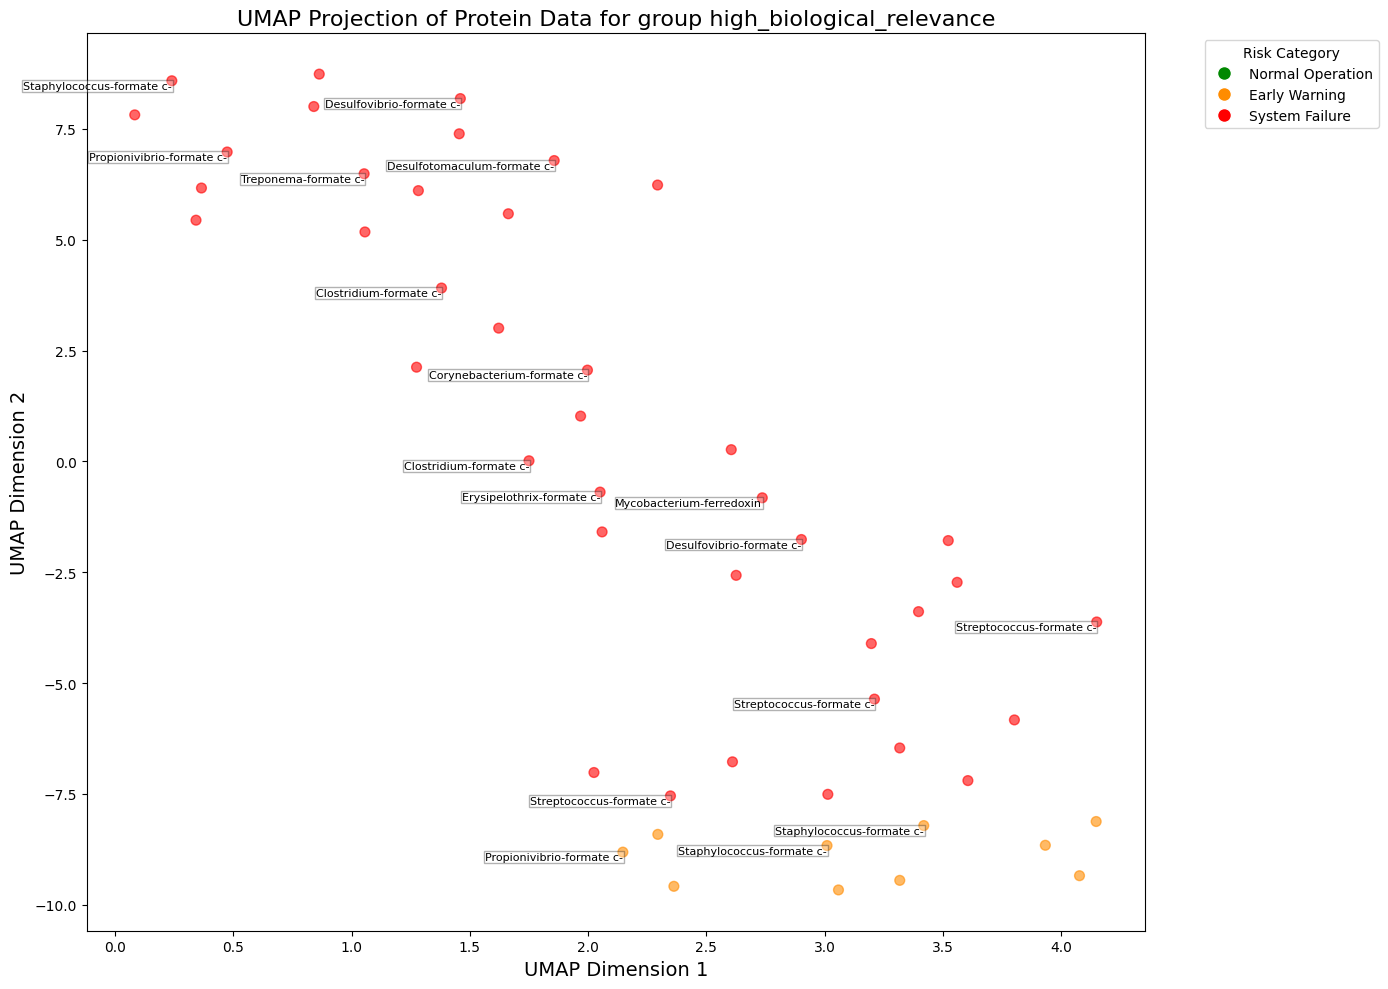

In [28]:
plot = create_simple_umap_visualization(high_biological_relevance, "high_biological_relevance", 50, n_neighbors=15, min_dist=0.5, point_size=50, category_dict=category_dict)
# Lower (e.g., 5-15): Focuses on very local structure → more clusters, tighter groups; Higher (e.g., 50-100): Focuses on global structure → broader patterns, fewer clusters
# min_dist: espace between points, Lower values (0.-0.1) keep points closer, higher values (0.5-0,99) spread them out more.
umap_path = data_visual / "14_umap_high_biological.png"
#plt.savefig(umap_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close('all')

The UMAP visualization (section 3.9, 1_visual_protein.ipynb) shows the high_biological_relevance group projected into two dimensions, revealing a clear diagonal gradient dominated by formate C‑acetyltransferase (FCT) markers across multiple genera, with a single ferredoxin marker as an exception.

The upper left part of the gradient contains Early Warning markers from pioneer sulfate‑reducing and syntrophic genera (Desulfovibrio, Desulfotomaculum, Desulfomicrobium, Propionivibrio) expressing FCT, consistent with active Wood–Ljungdahl‑linked acetogenesis and formate/H₂ consumption that can drive cathodic depolarization in MIC settings.

The diagonal progression through Streptococcus, Treponema and Clostridium represents a transitional zone in which FCT is shared by fermentative and sulfate‑reducing taxa, with Mycobacterium‑ferredoxin appearing as the only non‑FCT protein marker in this region.

The lower right region is dominated by System Failure markers, where Corynebacterium–FCT and the same pioneer sulfate‑reducing genera reappear at higher relative abundance rather than being newly recruited, consistent with an intensification of the same metabolic module along the risk gradient.

The absence of Normal Operation markers in this embedding and the overwhelming dominance of FCT‑linked proteins support formate C‑acetyltransferase metabolism as a core functional signature of corrosive communities in these systems

/home/beatriz/MIC/3_combined/.venv_combi/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



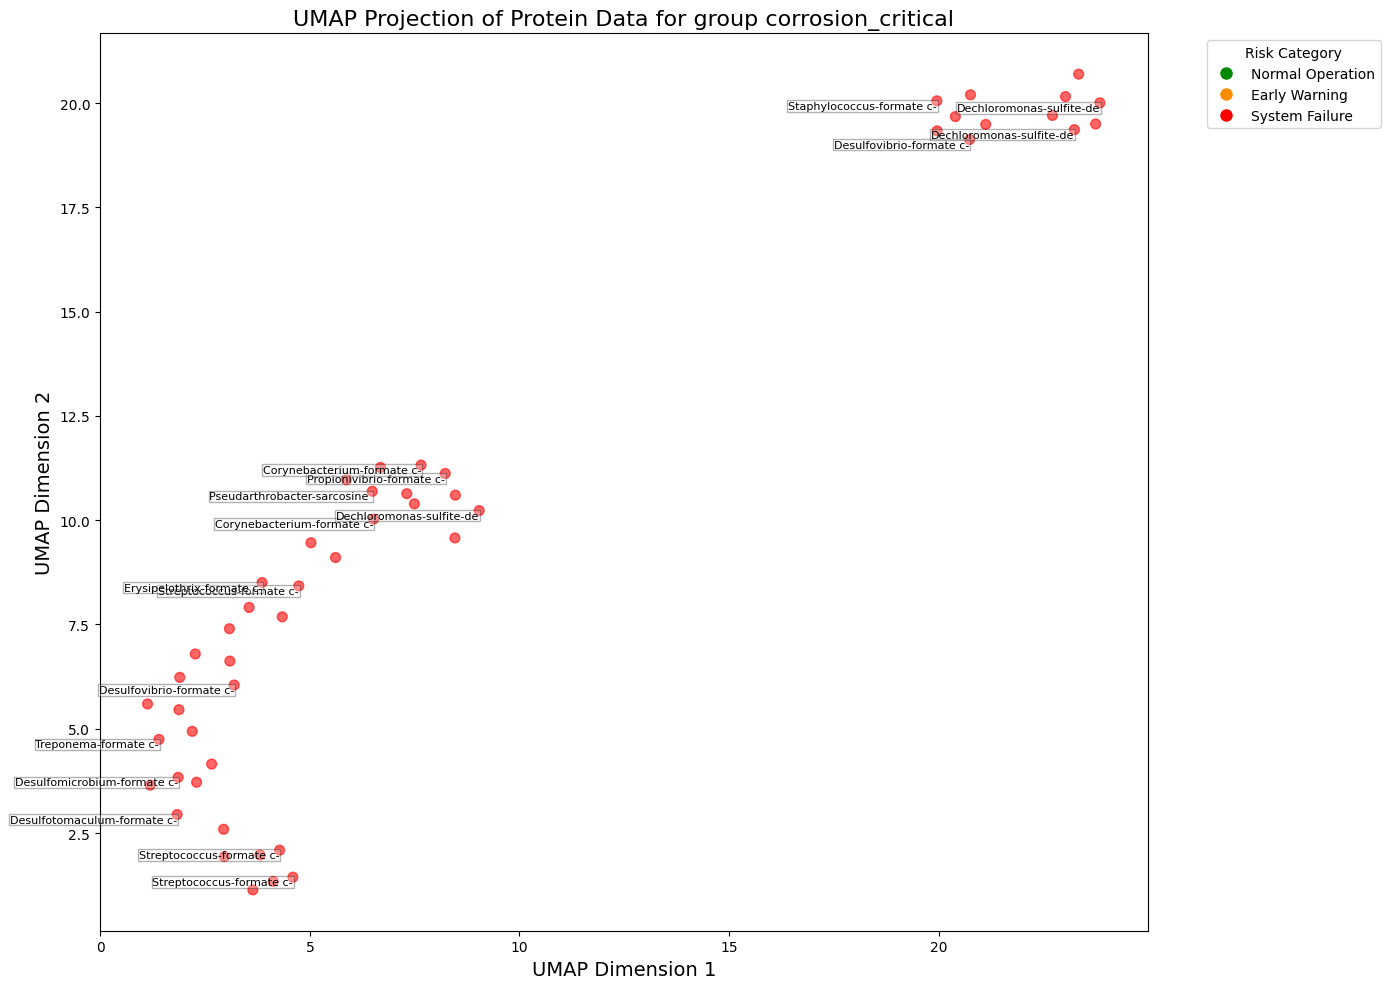

In [29]:
plot = create_simple_umap_visualization(corrosion_critical, "corrosion_critical", 50, n_neighbors=15, min_dist=0.5, point_size=50, category_dict=category_dict)
# Lower (e.g., 5-15): Focuses on very local structure → more clusters, tighter groups; Higher (e.g., 50-100): Focuses on global structure → broader patterns, fewer clusters
# min_dist: espace between points, Lower values (0.-0.1) keep points closer, higher values (0.5-0,99) spread them out more.
umap_path = data_visual / "14_umap_high_biological.png"
#plt.savefig(umap_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close('all')

High_metal_relevance highlights the sulfur/thiol arm of MIC (3‑mercapto / sulfite dominated).

Corrosion_critical shows that, when tightinen the criteria, both arms remain, the formate(acid metabolism) and the sulfur metabolism(sulfite dominate), two lobes on the same UMAP line: the system can reach severe corrosion via either a formate‑centric route, a sulfur‑centric route, or mixed consortia that contain both

## 3.9. Genus-functional category relationships with pathways annotations (fallback to functional_child)

In [30]:
def plot_functional_group_scatter(classified_results, pathway_categories, name, top_n=None, max_genera=8):
    """
    Create scatter plot showing genus–pathway-category relationships.
    Dot size = count of markers, dot color = pathway classification.
    Labels show pathway name (fallback to functional_child if pathway is NaN).
    """
    # make sure no change in group
    classified_results = classified_results.copy()
    
    # normalize pathways
    if 'pathways' in classified_results.columns:
        classified_results = classified_results.copy()
        classified_results['pathways'] = classified_results['pathways'].apply(rename_pathway_single)

    # Use all rows if top_n is None, otherwise take top N by score
    if top_n is not None:
        top_markers = classified_results.sort_values('combined_score', ascending=False).head(top_n)
    else:
        top_markers = classified_results.sort_values('combined_score', ascending=False)

    if top_markers.empty:
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig

    # Filter to top N genera by average combined_score
    top_genera = (
        top_markers.groupby('Genus')['combined_score']
        .mean()
        .nlargest(max_genera)
        .index
        .tolist()
    )
    top_markers = top_markers[top_markers['Genus'].isin(top_genera)]

    # Use the passed pathway_categories as list of category keys; otherwise, fall back to all keys in cs.pathway_dict
    all_cat_terms = {k: v for k, v in cs.pathway_dict.items()}
    pathway_categories= {'biofilm_formation', 'carbon_metabolism','iron_sulfur_redox', 'metal_organic_interaction', 'nitrogen_metabolism', 'organic_acid_metabolism','sulfur_metabolism'}

    if isinstance(pathway_categories, (list, tuple, set)):
        category_keys = [k for k in all_cat_terms.keys() if k in pathway_categories]
    else:
        category_keys = list(all_cat_terms.keys())

    category_keys = sorted(category_keys)

    # Helper: does this row’s pathway belong to a given category key?
    def row_in_category(row, cat_key):
        pw = str(row.get('pathways', '')).lower()
        terms = all_cat_terms.get(cat_key, [])
        return any(term.lower() in pw for term in terms)

    genera = sorted(top_genera)

    if len(category_keys) == 0 or len(genera) == 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.text(0.5, 0.5, 'No pathway categories or genera found', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig

    # Group by (Genus, category_key) using cs.pathway_dict membership
    plot_data = []
    for genus in genera:
        genus_markers = top_markers[top_markers['Genus'] == genus]
        for cat_key in category_keys:
            cat_markers = genus_markers[genus_markers.apply(lambda r: row_in_category(r, cat_key), axis=1)]
            if len(cat_markers) > 0:
                # pathway_classification (most common)
                mode_vals = cat_markers['pathway_classification'].mode()
                classification = mode_vals[0] if len(mode_vals) > 0 else 'unknown'

                # Best marker for annotation
                best_marker = cat_markers.loc[cat_markers['combined_score'].idxmax()]

                # Label: pathway (fallback functional_child) – unchanged
                label = ''
                if 'pathways' in cat_markers.columns:
                    pathway = str(best_marker['pathways'])
                    if pd.notna(pathway) and pathway not in ['nan', '', 'None', '<NA>']:
                        label = pathway[:35]

                if not label and 'functional_child' in cat_markers.columns:
                    func_child = str(best_marker['functional_child'])
                    if pd.notna(func_child) and func_child not in ['nan', '', 'None', '<NA>']:
                        label = func_child[:30]

                count = len(cat_markers)

                plot_data.append({
                    'genus': genus,
                    'category': cat_key,       # <<-- category key from cs.pathway_dict
                    'classification': classification,
                    'label': label,
                    'count': count
                })

    plot_df = pd.DataFrame(plot_data)

    if plot_df.empty:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.text(0.5, 0.5, 'No valid combinations found', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig

    # Dynamic figure size
    fig_width = max(10, len(category_keys) * 2)
    fig_height = max(6, len(genera) * 0.8)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    color_map = {
        'universal': '#3498db',
        'niche-specific': '#e67e22',
        'mixed': '#95a5a6',
        'unknown': '#cccccc'
    }

    cat_to_x = {cat: i for i, cat in enumerate(category_keys)}
    genus_to_y = {g: i for i, g in enumerate(genera)}

    for classification in plot_df['classification'].unique():
        subset = plot_df[plot_df['classification'] == classification]
        x = [cat_to_x[c] for c in subset['category']]
        y = [genus_to_y[g] for g in subset['genus']]
        sizes = subset['count'] * 100

        ax.scatter(
            x, y, s=sizes,
            c=color_map.get(classification, '#cccccc'),
            alpha=0.6, edgecolors='black', linewidth=0.5,
            label=classification, zorder=2
        )

    # Annotations: unchanged (pathways → functional_child)
    for idx, row in plot_df.iterrows():
        if row['label']:
            x = cat_to_x[row['category']]
            y = genus_to_y[row['genus']]
            xytext = (6, 6) if idx % 2 == 0 else (6, -10)

            ax.annotate(
                row['label'],
                xy=(x, y),
                xytext=xytext,
                textcoords='offset points',
                fontsize=10,
                alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'),
                zorder=3
            )

    ax.set_xticks(range(len(category_keys)))
    ax.set_xticklabels(category_keys, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(genera)))
    ax.set_yticklabels(genera, fontsize=10)

    ax.set_xlabel('Pathway category (cs.pathway_dict keys)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Genus (Top {max_genera} by Avg Score)', fontsize=12, fontweight='bold')

    title_suffix = f"Top {top_n} markers" if top_n else f"All {len(top_markers)} markers"
    ax.set_title(
        f'Genus–Pathway Category Relationships: {name}\n'
        f'({title_suffix}, dot size = count), Annotations: pathways (fallback functional_child)',
        fontsize=12, fontweight='bold', pad=10
    )

    ax.legend(
        title='Pathway classification',
        loc='lower right',
        bbox_to_anchor=(1, 0),
        bbox_transform=fig.transFigure,
        frameon=True,
        fancybox=True,
        shadow=True
    )

    ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
    ax.set_axisbelow(True)
    plt.tight_layout()
    return fig


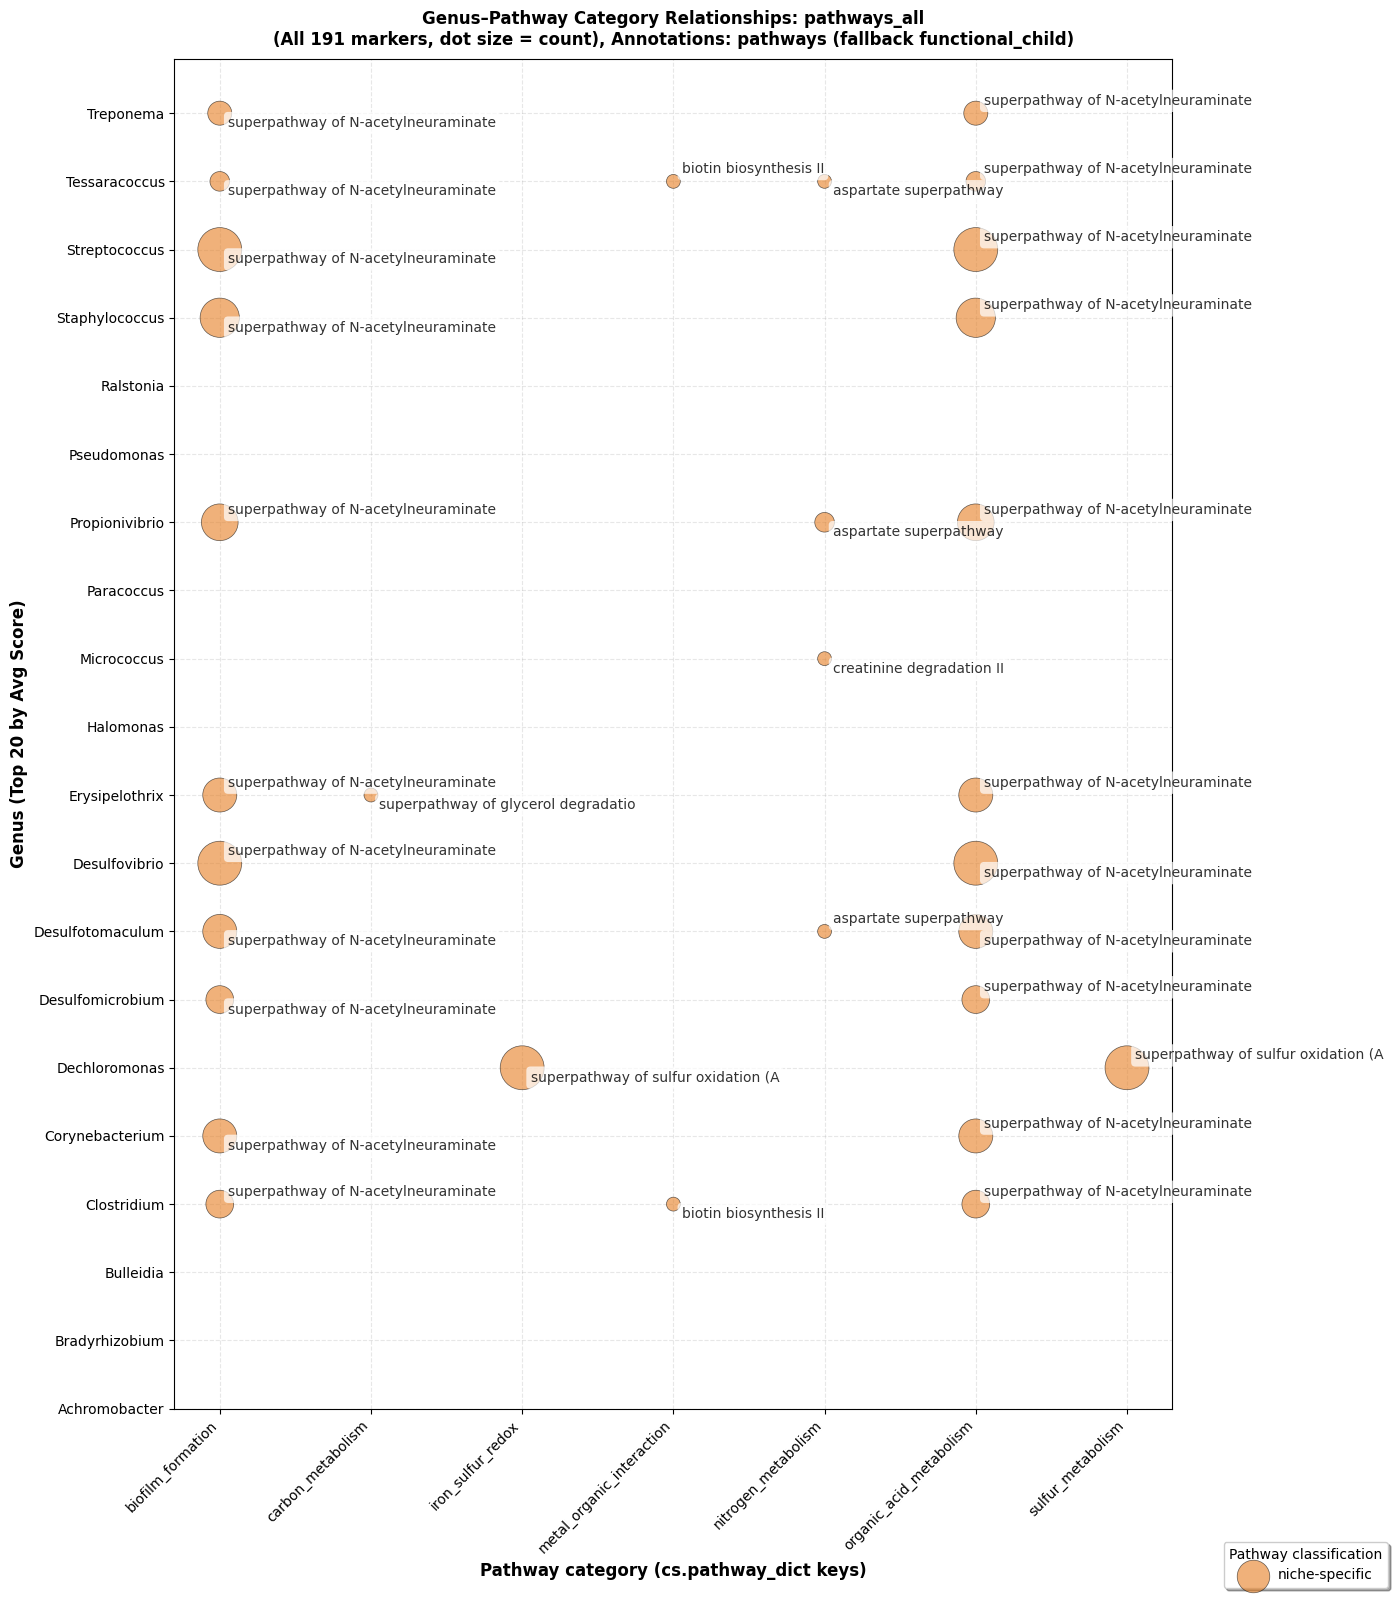

<Figure size 640x480 with 0 Axes>

In [31]:
fig = plot_functional_group_scatter(pathways_all, cs.pathway_dict, "pathways_all", max_genera=20)
plt.show()
opath = data_visual/"16_functional_pathways.png"
plt.savefig(opath, dpi=300, bbox_inches='tight')

Pathway_all is functionally very similar to synergy_all, but comprise all the pathways annotated in the data, then it captures more of the sulfur and metal‑organic annotations and therefore shows up as a separate branch in the similarity dendrogram: it is the “maximally integrated” view where biofilm/organic acids, sulfur oxidation, biotin and nitrogen organics all co‑occur in the same group, instead of being split.
Biofilm & organic acid sub‑categories: repeatedly annotated with the superpathway of N‑acetylneuraminate degradation, so Neu5Ac/sialic‑acid use is clearly part of a biofilm/organic‑acid lifestyle, i.e. bacteria stripping terminal sialic acids from matrix or host glycoconjugates.
Iron–sulfur / sulfur metabolism subs: annotated with superpathway of sulfur oxidation (and sometimes general sulfur metabolism), consistent with a reduced‑sulfur → oxidized‑sulfur redox arm that is directly linked to MIC in steel systems.
Metal–organic interaction sub: biotin biosynthesis I/II, which are Fe–S–cluster enzymes (BioB, etc.), tying cofactor production directly to iron–sulfur cluster chemistry and anaerobic metabolism.
Nitrogen metabolism sub: purine nucleobase salvage, aspartate degradation / NAD de novo biosynthesis from aspartate, and creatinine degradation II, indicating recycling of nitrogenous organics and purines rather than simple inorganic nitrate reduction.

The most recurrent pathway (superpathway of N‑acetylneuraminate degradation) and the most recurrent protein (formate C‑acetyltransferase) likely represent different tiers of the same metabolic module. Sialic‑acid degradation supplies pyruvate and glycolytic intermediates from biofilm‑derived glycoconjugates, and pyruvate formate lyase then converts this pyruvate into formate and acetyl‑CoA, yielding the small organic acids and formate profile that we observe in corrosion‑associated communities.

## 3.10 Genera as a Function of Functional Subcategories, pathway annotated  

In [32]:
def plot_functional_group_scatter(classified_results, name, top_n=None, max_genera=8):
    """    Create scatter plot showing genus-pathway category relationships.
    Dot size = count of markers, dot color = pathway classification.
    Labels show pathway name (fallback to functional_child if pathway is NaN).
        Parameters:
        classified_results: DataFrame with classified pathways
        name: Name of the group for title, top_n: Number of top markers to use (default: None = use all rows)
        max_genera: Maximum number of genera to display (default: 8)
    Returns: matplotlib figure
    """
    # make sure no change in group
    classified_results = classified_results.copy()
    
    # make sure pathways are complete:
    if 'pathways' in classified_results.columns:
        classified_results['pathways'] = classified_results['pathways'].apply(rename_pathway_single)
    # Use all rows if top_n is None, otherwise take top N by score
    if top_n is not None:
        top_markers = classified_results.sort_values('combined_score', ascending=False).head(top_n)
    else:
        top_markers = classified_results.sort_values('combined_score', ascending=False)
    
    # Validate we have data
    if top_markers.empty or 'functional_sub' not in top_markers.columns:
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig
    
    # Filter to top N genera by average combined_score
    top_genera = top_markers.groupby('Genus')['combined_score'].mean().nlargest(max_genera).index.tolist() #max_genera
    top_markers = top_markers[top_markers['Genus'].isin(top_genera)]
    
    # Extract observed functional subcategories/pathway sub and genera
    functional_subs = sorted(top_markers['functional_sub'].dropna().unique())
    genera = sorted(top_genera)
    
    # Check if we have any data to plot
    if len(functional_subs) == 0 or len(genera) == 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.text(0.5, 0.5, 'No functional categories or genera found', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig
    
    # Group by (Genus, functional_sub) and aggregate
    plot_data = []
    for genus in genera:
        genus_markers = top_markers[top_markers['Genus'] == genus]
        for func_sub in functional_subs:
            func_markers = genus_markers[genus_markers['functional_sub'] == func_sub]
            if len(func_markers) > 0:
                # Get pathway classification (most common)
                classification = func_markers['pathway_classification'].mode()[0] if len(func_markers['pathway_classification'].mode()) > 0 else 'unknown'
                
                # Get label: try pathway first, fallback to functional_child
                best_marker = func_markers.loc[func_markers['combined_score'].idxmax()]
                
                # Try pathway first
                label = ''
                if 'pathways' in func_markers.columns:
                    pathway = str(best_marker['pathways'])
                    if pd.notna(pathway) and pathway not in ['nan', '', 'None', '<NA>']:
                        label = pathway[:35]
                
                # Fallback to functional_child if pathway is empty
                if not label and 'functional_child' in func_markers.columns:
                    func_child = str(best_marker['functional_child'])
                    if pd.notna(func_child) and func_child not in ['nan', '', 'None', '<NA>']:
                        label = func_child[:30]
                
                count = len(func_markers)
                plot_data.append({
                    'genus': genus,
                    'functional_sub': func_sub,
                    'classification': classification,
                    'label': label,
                    'count': count
                })
    
    # Convert to DataFrame for easier plotting
    plot_df = pd.DataFrame(plot_data)
    
    if plot_df.empty:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.text(0.5, 0.5, 'No valid combinations found', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig
    
    # Dynamic figure width based on number of functional subcategories
    fig_width = max(10, len(functional_subs) * 2)
    fig_height = max(6, len(genera) * 0.8)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Color mapping for pathway classification
    color_map = {
        'universal': '#3498db',      # Blue
        'niche-specific': '#e67e22', # Orange
        'mixed': '#95a5a6',          # Gray
        'unknown': '#cccccc'         # Light gray
    }
    
    # Create numeric mappings for x and y axes
    func_sub_to_x = {cat: i for i, cat in enumerate(functional_subs)}
    genus_to_y = {g: i for i, g in enumerate(genera)}
    
    # Plot each point
    for classification in plot_df['classification'].unique():
        subset = plot_df[plot_df['classification'] == classification]
        x = [func_sub_to_x[fs] for fs in subset['functional_sub']]
        y = [genus_to_y[g] for g in subset['genus']]
        sizes = subset['count'] * 100  # Scale for visibility
        
        ax.scatter(x, y, s=sizes, c=color_map.get(classification, '#cccccc'),
                  alpha=0.6, edgecolors='black', linewidth=0.5,
                  label=classification, zorder=2)
    
    # Add labels on dots with alternating positions to reduce overlap
    for idx, row in plot_df.iterrows():
        if row['label']:  # Only annotate if label exists
            x = func_sub_to_x[row['functional_sub']]
            y = genus_to_y[row['genus']]
            
            # Alternate positions based on row index to reduce overlap
            if idx % 2 == 0:
                xytext = (6, 6)   # Upper right
            else:
                xytext = (6, -10)  # Lower right
                
            ax.annotate(row['label'], 
                       xy=(x, y), 
                       xytext=xytext,
                       textcoords='offset points',
                       fontsize=7,
                       alpha=0.8,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'),
                       zorder=3)
    
    # Set axis labels and ticks
    ax.set_xticks(range(len(functional_subs)))
    ax.set_xticklabels(functional_subs, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(genera)))
    ax.set_yticklabels(genera, fontsize=10)
    
    # Labels and title
    ax.set_xlabel('Functional Subcategory', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Genus (Top {max_genera} by Avg Score)', fontsize=12, fontweight='bold')
    
    # Title shows row count used
    title_suffix = f"Top {top_n} markers" if top_n else f"All {len(top_markers)} markers"
    ax.set_title(f'Genus-Functional Category Relationships: {name}\n({title_suffix}, dot size = count), Annotations: pathways (fallback functional_child)', 
                 fontsize=14, fontweight='bold', pad=10)
    
    # Legend
    legend = ax.legend(title='Annotations: pathways (fallback functional_child)', loc='lower right', bbox_to_anchor=(1, 0),
                      bbox_transform=fig.transFigure, frameon=True, fancybox=True, shadow=True)
    
    # Grid for readability
    ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
    ax.set_axisbelow(True)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return fig

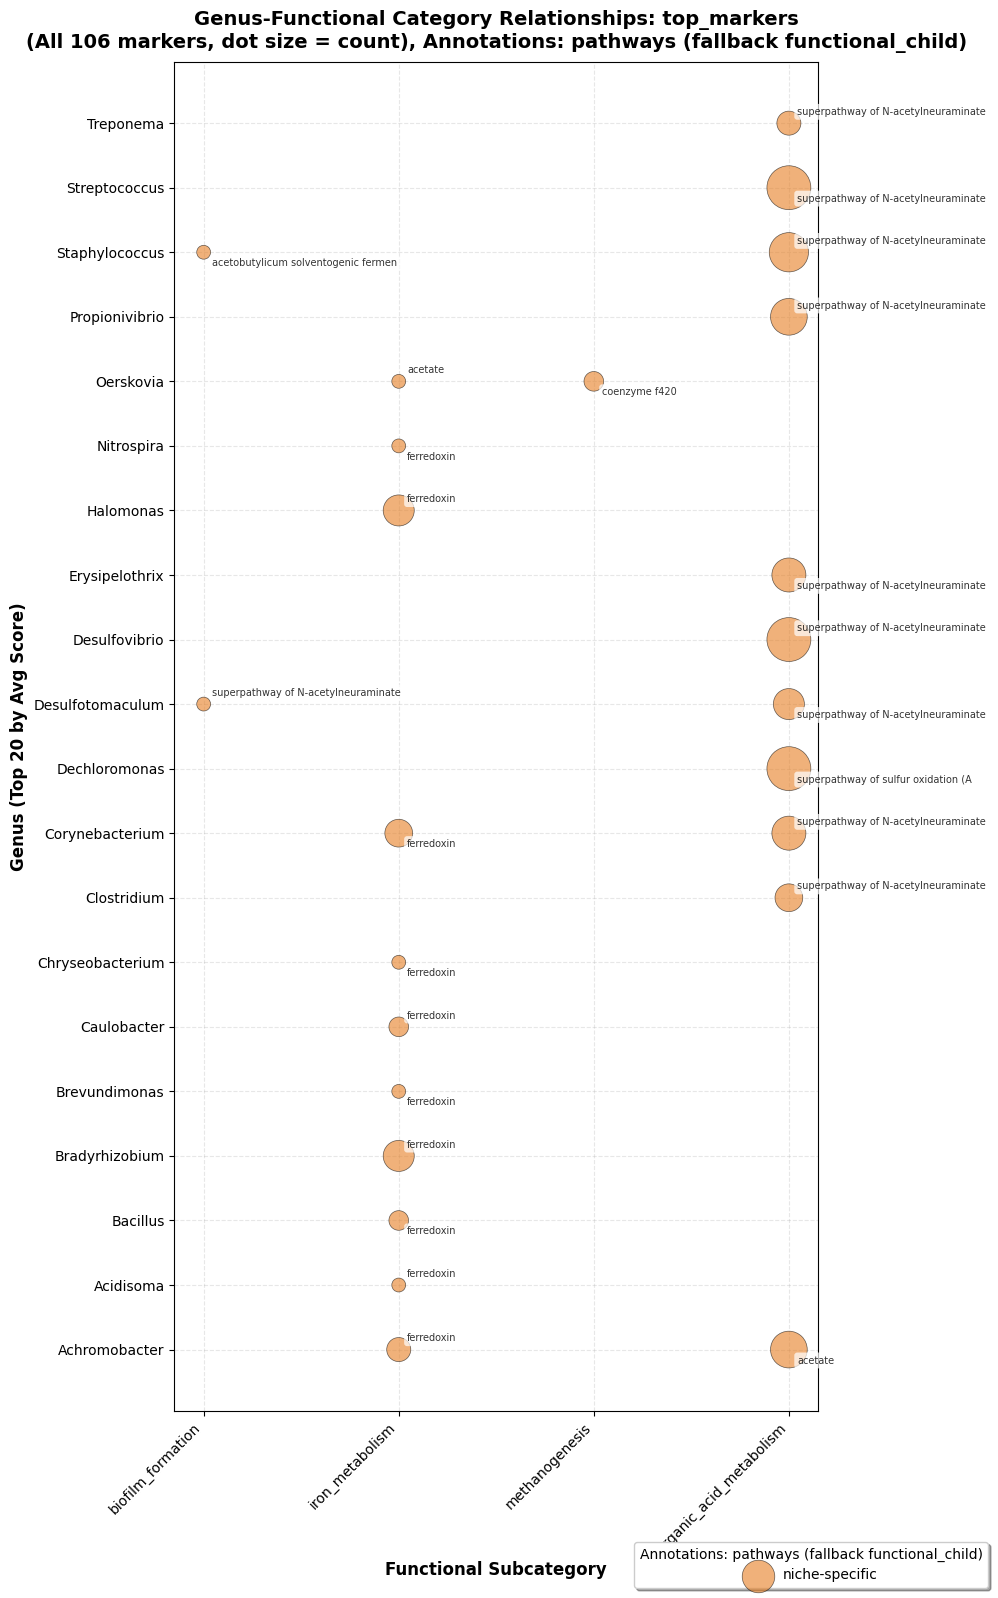

<Figure size 640x480 with 0 Axes>

In [33]:
fig = plot_functional_group_scatter(top_markers, "top_markers", max_genera=20)
plt.show()
opath = data_visual/"16_functional_pathways.png"
plt.savefig(opath, dpi=300, bbox_inches='tight')

Functional Specialization Analysis
Section 3.10 analysis top 20 highest-scoring genera as a function of functional subcategories, annotated with the respective pathways and falling back to functional child terms, all of which are niche specific. The genus–functional subcategory plot for the top markers group highlights two dominant clusters: an organic acid metabolism cluster where multiple genera (Corynebacterium, Clostridium, Desulfotomaculum, Desulfovibrio, Erysipelothrix, Propionivibrio, Staphylococcus, Streptococcus, Treponema) are annotated with the superpathway of N‑acetylneuraminate degradation, and an iron_metabolism cluster where a broad range of genera are associated with ferredoxin, highlighting widespread use of low‑potential iron–sulfur electron carriers. A smaller set of markers links methanogenesis (coenzyme F420 in Oerskovia), solventogenesis (Staphylococcus) and sulfur oxidation (Dechloromonas) to these core functions. Clearly none of the genera here depicted are bystanders, even when the annotations are some like protein name from functional child categories. Ferredoxin is a mistake on the anotation falling back to protein but clearly indicating iron-sulfur redox capacity and organic acid metabolism. The Ferredoxins having very negative reduction potentials (−400 to −500 mV vs. SHE) are capable to accept electrones directly through outer‑membrane cytochromes, nanowires, or sulfide bridges, bypassing H₂ as an intermediate. Then it is direct respiration metabolism from Fe0. 

## 3.11 Functional Categories as a Function of Protein-Genus Pair

In [34]:
def plot_functional_group_scatter(classified_results, name, top_n=None, max_genera=8):
    """    Create scatter plot showing genus-pathway category relationships.
    Dot size = count of markers, dot color = pathway classification.
    Labels show pathway name (fallback to functional_child if pathway is NaN).
        Parameters:
        classified_results: DataFrame with classified pathways
        name: Name of the group for title, top_n: Number of top markers to use (default: None = use all rows)
        max_genera: Maximum number of genera to display (default: 8)
    Returns: matplotlib figure
    """
    # make sure no change in group
    classified_results = classified_results.copy()
    
    #Create the combined Protein-Genus column ---
    classified_results['Protein_Genus'] = (
        classified_results['protein_name'].astype(str) + " - " + 
        classified_results['Genus'].astype(str)
    )
    
    # make sure pathways are complete:
    if 'pathways' in classified_results.columns:
        classified_results['pathways'] = classified_results['pathways'].apply(rename_pathway_single)
    # Use all rows if top_n is None, otherwise take top N by score
    if top_n is not None:
        top_markers = classified_results.sort_values('combined_score', ascending=False).head(top_n)
    else:
        top_markers = classified_results.sort_values('combined_score', ascending=False)
    
    # Validate we have data
    if top_markers.empty or 'functional_sub' not in top_markers.columns:
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig
    
    # Filter to top N genera-protein by average combined_score
    top_genera = top_markers.groupby('Protein_Genus')['combined_score'].mean().nlargest(max_genera).index.tolist() #max_genera
    top_markers = top_markers[top_markers['Protein_Genus'].isin(top_genera)]
    
    # Extract observed functional subcategories/pathway sub and genera
    functional_subs = sorted(top_markers['functional_sub'].dropna().unique())
    genera = sorted(top_genera)
    
    # Check if we have any data to plot
    if len(functional_subs) == 0 or len(genera) == 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.text(0.5, 0.5, 'No functional categories or genera found', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig
    
    # Group by (Genus, functional_sub) and aggregate
    plot_data = []
    for genus in genera:
        genus_markers = top_markers[top_markers['Protein_Genus'] == genus]
        for func_sub in functional_subs:
            func_markers = genus_markers[genus_markers['functional_sub'] == func_sub]
            if len(func_markers) > 0:
                # Get pathway classification (most common)
                classification = func_markers['pathway_classification'].mode()[0] if len(func_markers['pathway_classification'].mode()) > 0 else 'unknown'
                
                # Get label: try pathway first, fallback to functional_child
                best_marker = func_markers.loc[func_markers['combined_score'].idxmax()]
                
                # Try pathway first
                label = ''
                if 'pathways' in func_markers.columns:
                    pathway = str(best_marker['pathways'])
                    if pd.notna(pathway) and pathway not in ['nan', '', 'None', '<NA>']:
                        label = pathway[:35]
                
                # Fallback to functional_child if pathway is empty
                if not label and 'functional_child' in func_markers.columns:
                    func_child = str(best_marker['functional_child'])
                    if pd.notna(func_child) and func_child not in ['nan', '', 'None', '<NA>']:
                        label = func_child[:30]
                
                count = len(func_markers)
                plot_data.append({
                    'genus': genus, # contains protein-genus
                    'functional_sub': func_sub,
                    'classification': classification,
                    'label': label,
                    'count': count
                })
    
    # Convert to DataFrame for easier plotting
    plot_df = pd.DataFrame(plot_data)
    
    if plot_df.empty:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.text(0.5, 0.5, 'No valid combinations found', ha='center', va='center', fontsize=14)
        ax.set_title(f"{name} - No Data")
        return fig
    
    # Dynamic figure width based on number of functional subcategories
    fig_width = max(10, len(functional_subs) * 2)
    fig_height = max(6, len(genera) * 0.8)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Color mapping for pathway classification
    color_map = {
        'universal': '#3498db',      # Blue
        'niche-specific': '#e67e22', # Orange
        'mixed': '#95a5a6',          # Gray
        'unknown': '#cccccc'         # Light gray
    }
    
    # Create numeric mappings for x and y axes
    func_sub_to_x = {cat: i for i, cat in enumerate(functional_subs)}
    genus_to_y = {g: i for i, g in enumerate(genera)}
    
    # Plot each point
    for classification in plot_df['classification'].unique():
        subset = plot_df[plot_df['classification'] == classification]
        x = [func_sub_to_x[fs] for fs in subset['functional_sub']]
        y = [genus_to_y[g] for g in subset['genus']]
        sizes = subset['count'] * 100  # Scale for visibility
        
        ax.scatter(x, y, s=sizes, c=color_map.get(classification, '#cccccc'),
                  alpha=0.6, edgecolors='black', linewidth=0.5,
                  label=classification, zorder=2)
    
    # Add labels on dots with alternating positions to reduce overlap
    for idx, row in plot_df.iterrows():
        if row['label']:  # Only annotate if label exists
            x = func_sub_to_x[row['functional_sub']]
            y = genus_to_y[row['genus']]
            
            # Alternate positions based on row index to reduce overlap
            if idx % 2 == 0:
                xytext = (6, 6)   # Upper right
            else:
                xytext = (6, -10)  # Lower right
                
            ax.annotate(row['label'], 
                       xy=(x, y), 
                       xytext=xytext,
                       textcoords='offset points',
                       fontsize=7,
                       alpha=0.8,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'),
                       zorder=3)
    
    # Set axis labels and ticks
    ax.set_xticks(range(len(functional_subs)))
    ax.set_xticklabels(functional_subs, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(genera)))
    ax.set_yticklabels(genera, fontsize=10)
    
    # Labels and title
    ax.set_xlabel('Functional Subcategory', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Protein_Genus (Top {max_genera} by Avg Score)', fontsize=12, fontweight='bold')
    
    # Title shows row count used
    title_suffix = f"Top {top_n} markers" if top_n else f"All {len(top_markers)} markers"
    ax.set_title(f'Protein_Genus Functional Category Relationships: {name}\n({title_suffix}, dot size = count), Annotations: pathways (fallback functional_child)', 
                 fontsize=14, fontweight='bold', pad=10)
    
    # Legend
    legend = ax.legend(title='Annotations: pathways (fallback functional_child)', loc='lower right', bbox_to_anchor=(1, 0),
                      bbox_transform=fig.transFigure, frameon=True, fancybox=True, shadow=True)
    
    # Grid for readability
    ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
    ax.set_axisbelow(True)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return fig

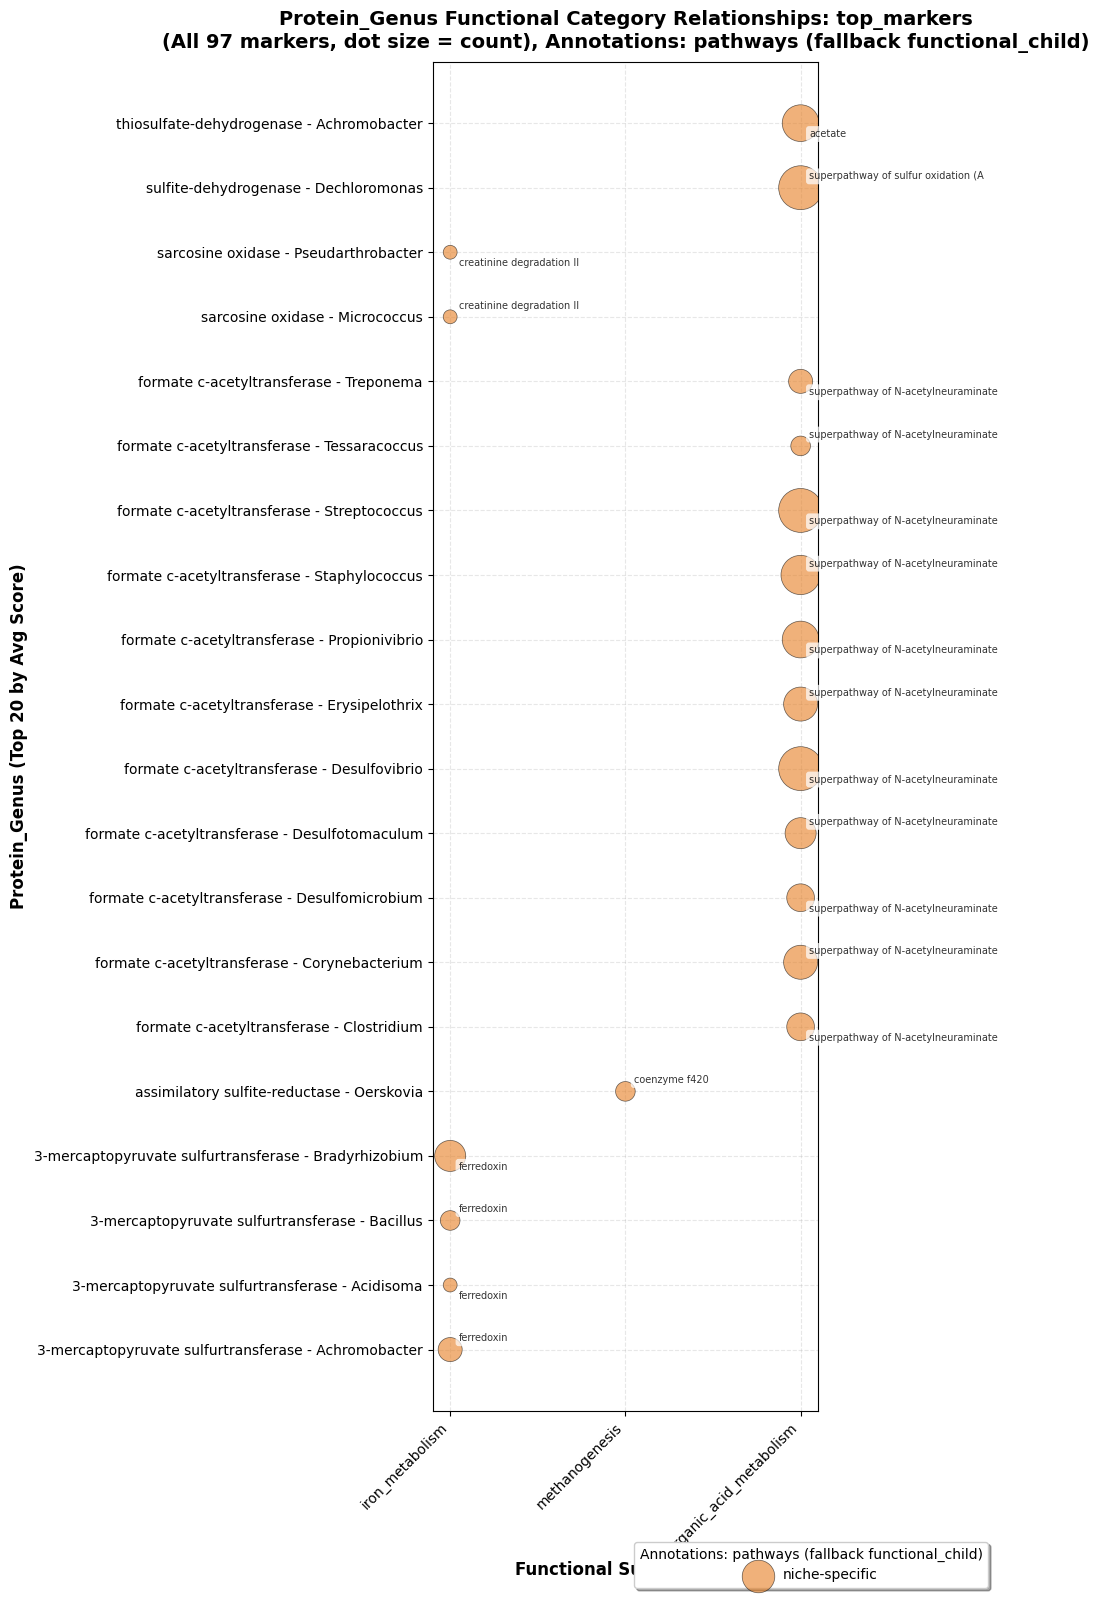

<Figure size 640x480 with 0 Axes>

In [35]:
fig = plot_functional_group_scatter(top_markers, "top_markers", max_genera=20)
plt.show()
opath = data_visual/"16_functional_pathways.png"
plt.savefig(opath, dpi=300, bbox_inches='tight')

combination of protein-genus pair as the dependent variable has improve the plot by bringing the 3 mercaptopyruvate sufurtransferase to the iron metabolism, however it is better to have more information to complete the information, so a table with the most interesting information is done in the next step.

## 3.12 Concensus Tables

In [36]:
# Extract non-None values from dict/list columns
def extract_non_none(lst_or_dict):
    if pd.isna(lst_or_dict):
        return ''
    if isinstance(lst_or_dict, dict):
        return ', '.join([k for k,v in lst_or_dict.items() if v is not None])
    return ', '.join([str(x) for x in lst_or_dict if x is not None])

def create_consensus_table(df):
    df = df.copy()
        
    #Create the combined Protein-Genus column ---
    df['protein_genus'] = (
        df['protein_name'].astype(str) + " - " + df['Genus'].astype(str)
    )
    
    # make sure pathways are complete:
    if 'pathways' in df.columns:
        df['pathways'] = df['pathways'].apply(rename_pathway_single)
    # 1. Create protein-genus identifier
    # df['protein_genus'] = df['Genus'] + '-' + df['protein_name']
    
    # 2. Select/extract requested columns
    table_df = pd.DataFrame({
        'protein_name': df['protein_name'],
        'Genus' : df['Genus'],
        'pathway': df['pathways'],
        'synergy_description': df['synergy_description'],
        'organic_complex': df.get('organic_complex', pd.Series(['']*len(df), index=df.index)),  # Safe if column missing
        #'functional_sub': df['functional_sub'],
        'synergy_child_list': df['synergy_child_list'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x),
        #'operational_sub': df['operational_sub'],
        'synergy_combi': df['synergy_combi'], #.apply(extract_non_none),
        'norm_abund_contri': df['norm_abund_contri'],
        'combined_score': df['combined_score']
    })
    
    # 3. Extract mech_combi (only non-None mechanisms), remove, doesnt apport extra info but noise
    #df['mech_combi_extracted'] = df['mechanisms_combi'].apply(extract_non_none)
    #table_df['mech_combi'] = df['mech_combi_extracted']
    
    # 4. Extract functional_combi (only non-None functional subs with their children)
    def extract_func_combi(func_dict):
        if pd.isna(func_dict) or not isinstance(func_dict, dict):
            return ''
        extracted = []
        for subcat, children in func_dict.items():
            if children:  # Only if not None/empty
                if isinstance(children, list):
                    extracted.append(f"{subcat}: {', '.join(children)}")
                else:
                    extracted.append(f"{subcat}: {children}")
        return '; '.join(extracted)
    
    table_df['functional_combi'] = df['functional_combi'].apply(extract_func_combi)
    
    # 5. Sort by combined_score DESC, then norm_abund_contri DESC
    table_df = table_df.sort_values(['combined_score', 'norm_abund_contri'], 
                                   ascending=[False, False]).reset_index(drop=True)
    
    # 6. Select final columns in order
    final_cols = ['protein_name', 'Genus', 'pathway', 'synergy_child_list','synergy_combi','synergy_description', # 'functional_sub', 'operational_sub','mech_combi',
                  'organic_complex', 'functional_combi', 'norm_abund_contri','combined_score']
    
    return table_df[final_cols].head(20)  # Top 20


In [37]:
consensus_table_synergy = create_consensus_table(synergy_all)
#print(consensus_table.to_markdown(index=False))

In [38]:
consensus_table_synergy

,protein_name,Genus,pathway,synergy_child_list,synergy_combi,synergy_description,organic_complex,functional_combi,norm_abund_contri,combined_score
0,formate c-acetyltransferase,Desulfovibrio,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.877696,1.484093
1,formate c-acetyltransferase,Propionivibrio,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.870813,1.484093
2,formate c-acetyltransferase,Desulfovibrio,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.636061,1.484093
3,formate c-acetyltransferase,Tessaracoccus,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.631973,1.484093
4,formate c-acetyltransferase,Desulfovibrio,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.630767,1.484093
5,formate c-acetyltransferase,Staphylococcus,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.610955,1.484093
6,formate c-acetyltransferase,Staphylococcus,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.570161,1.484093
7,formate c-acetyltransferase,Desulfotomaculum,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.309575,1.484093
8,formate c-acetyltransferase,Desulfomicrobium,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.300889,1.484093
9,formate c-acetyltransferase,Propionivibrio,superpathway of N-acetylneuraminate degradation,"[acetyl, fermentation, formate, iron sulfur cluster, pyruvate, succinate]","[organic_acid_metabolism, direct_eet]",TOC-chelation Synergy (TOC-chelate),,organic_acid_metabolism: ['3 oxoacyl'],0.241005,1.484093


In [39]:
consensus_table_top = create_consensus_table(high_metals_relevance)
consensus_table_top

,protein_name,Genus,pathway,synergy_child_list,synergy_combi,synergy_description,organic_complex,functional_combi,norm_abund_contri,combined_score
0,sulfite-dehydrogenase,Dechloromonas,superpathway of sulfur oxidation (Acidianus ambivalens),"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],1.000000,1.432637
1,sulfite-dehydrogenase,Dechloromonas,S. of sulfide oxidation,"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],0.961233,1.432637
2,sulfite-dehydrogenase,Dechloromonas,superpathway of sulfur oxidation (Acidianus ambivalens),"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],0.900929,1.432637
3,sulfite-dehydrogenase,Dechloromonas,superpathway of sulfur oxidation (Acidianus ambivalens),"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],0.899776,1.432637
4,sulfite-dehydrogenase,Dechloromonas,S. of sulfide oxidation,"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],0.532468,1.432637
5,sulfite-dehydrogenase,Dechloromonas,S. of sulfur metabolism,"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],0.333189,1.432637
6,sulfite-dehydrogenase,Dechloromonas,S. of sulfide oxidation,"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],0.229361,1.432637
7,sulfite-dehydrogenase,Dechloromonas,S. of sulfide oxidation,"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],0.102167,1.432637
8,sulfite-dehydrogenase,Dechloromonas,S. of sulfide oxidation,"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],0.072326,1.432637
9,sulfite-dehydrogenase,Dechloromonas,S. of sulfur metabolism,"[acetate, oxidase, oxidative phosphorylation, sulfite, sulfur metabolism, sulfur oxidation, thiosulfate]","[organic_acid_metabolism, direct_eet]",Multi-pathway Synergy (3 categories),,organic_acid_metabolism: ['acetate'],0.040000,1.432637


# 4. Proteins 
## 4.1. Protein Abundance Trajectories across risk categories

Fold change thresholds are standard practice (Love et al., 2014; DESeq2) the idea is to calculate which and how much the protein have an increase when changing the risk category from one lower to a high category. 
Reference
Love, M. I., Huber, W., & Anders, S. (2014). Moderated estimation of fold change and dispersion for RNA-seq data with DESeq2. Genome Biology, 15(12), 550. https://doi.org/10.1186/s13059-014-0550-8.

In [40]:
def plot_abundance_across_categories(marker_group, name, top_n=25, sort_by='combined_score'):
    """
    Plot abundance patterns across corrosion categories for top markers.
    Uses global term dictionaries and pre-calculated fold change columns.
    
    Parameters:
        marker_group: DataFrame containing marker data
        name: Name of the group for the title
        top_n: Number of top markers to display
        sort_by: Column name to sort markers by (default: 'combined_score')
        
    Returns:
        Plotly figure object with the abundance plot
    """
    # Make a copy to avoid modifying the original
    markers_df = marker_group.copy()
    
    # Get mean columns
    mean_cols = [col for col in markers_df.columns if col.startswith('mean_cat')]
    if not mean_cols:
        raise ValueError("No mean abundance columns found (should start with 'mean_cat')")
    
    # Sort and get top markers
    if sort_by in markers_df.columns:
        top_markers = markers_df.sort_values(sort_by, ascending=False).head(top_n)
    else:
        # If sort column not found, try combined_score, otherwise sort by first mean column
        if 'combined_score' in markers_df.columns:
            top_markers = markers_df.sort_values('combined_score', ascending=False).head(top_n)
        else:
            top_markers = markers_df.sort_values(mean_cols[0], ascending=False).head(top_n)
    
    # Extract category numbers from column names
    categories = [col.replace('mean_cat', 'Category ') for col in mean_cols]
    category_nums = [int(col.replace('mean_cat', '')) for col in mean_cols]
    
    # Create a list to store traces for each marker
    traces = []
    
    # Add trace for each marker
    for i, (_, row) in enumerate(top_markers.iterrows()):
        # Create shorter, more readable labels
        protein_name = row['protein_name'] if 'protein_name' in row else row.get('Marker', 'Unknown')
        if isinstance(protein_name, str) and len(protein_name) > 20:
            protein_name = protein_name[:25] + "..."
        
        # Add genus for better identification
        label = f"{row.get('Genus', 'Unknown')} - {protein_name}"
        
        # Get abundance values
        values = [row[col] for col in mean_cols]
        
        # Add trace with hover information
        hover_text = []
        for i, cat in enumerate(categories):
            hover_info = f"Category: {cat}<br>Abundance: {values[i]:.4f}"
            if 'Genus' in row:
                hover_info += f"<br>Genus: {row['Genus']}"
            
            # Add fold changes to hover info if available
            if 'fold_change_3vs1' in row and i == 2:  # For category 3
                hover_info += f"<br>FC vs Cat1: {row['fold_change_3vs1']:.2f}"
            if 'fold_change_2vs1' in row and i == 1:  # For category 2
                hover_info += f"<br>FC vs Cat1: {row['fold_change_2vs1']:.2f}"
            if 'fold_change_3vs2' in row and i == 2:  # For category 3
                hover_info += f"<br>FC vs Cat2: {row['fold_change_3vs2']:.2f}"
                
            # Add additional hover information if available

            if 'combined_score' in row:
                hover_info += f"<br>Score: {row['combined_score']:.2f}"    
            if 'pattern' in row:
                hover_info += f"<br>Pattern: {row['pattern']}"

            hover_text.append(hover_info)
        
        # Create trace for this marker
        trace = go.Scatter(
            x=category_nums,
            y=values,
            mode='lines+markers',
            name=label,
            line=dict(width=2),
            marker=dict(size=8),
            hovertext=hover_text,
            hoverinfo='text'
        )
        
        traces.append(trace)
    
    # Create figure
    fig = go.Figure(data=traces) 
    fig.update_layout(title=f'Abundance Patterns of Group {name} Across Corrosion Categories (Top {top_n} Markers)', xaxis=dict(tickfont=dict(size=18, family="Arial"), tickmode='array', tickvals=category_nums, ticktext=categories, domain=[0, 1]), yaxis=dict(title=dict(text='Mean Abundance', font=dict(size=14))), legend=dict(orientation="h", yanchor="bottom", y=-0.8, xanchor="center", x=0.5), margin=dict(t=100, b=150, l=100, r=100), height=700, width=1000, hovermode='closest', annotations=[dict(x=0.5, y=1.05, xref="paper", yref="paper", text="Corrosion Category", showarrow=False, font=dict(size=14))])

    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
    
    return fig

In [41]:
abun= plot_abundance_across_categories(high_synergy_relevance, "high_synergy_relevance",  top_n=20, sort_by='combined_score')
output_path= data_visual /"18_increase.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
abun.show()

<Figure size 640x480 with 0 Axes>

Protein abundance trajectories across risk categories are shown in section 3.10 of 1_visual_protein.ipynb, using fold change thresholds of abundance patterns across corrosion categories from Category 1 to 2 to 3. The dominant protein expressed is consistently formate C-acetyltransferase across multiple groups including top_markers, high_biological_relevance, high_corrosion_relevance, and significant_markers. Formate C-acetyltransferase aka Pyruvate Formate Lypase PFL catalyzes the reversible conversion of pyruvate and CoA to acetyl-CoA and formate, a key reaction in mixed-acid fermentation under anaerobic conditions. PFL is ubiquitous because it's the main anaerobic pyruvate sink when respiration stalls → pyruvate → formate + acetyl‑CoA → mixed acids (acetate, succinate, lactate, etc.).  More over is a strong organic acid that directly drives corrosion and acidifies the local environment. PFL enables survival and grow by regenerating Nicotinamide Adenine Dinucleotide NAD+ from glycolysis(mixed acid fermentation). Providing acetyl CoA for biosynthesis (lipids, aminoacids) and producing formate as electron carrier. The formate produced can be utilised as last electron donor for respiration on the last energy step for energy of the colony, formate from PFL feeds the formate hydrogenlyase (FHL) complex → formate + 2H⁺ → CO₂ + 2H₂, which consumes protons and generates H₂ that can diffuse away. This H₂ can then be consumed by sulfate reducers or directly reduce the metal surface (cathodic depolarization). Ultimately PFL substains biomass (when oxigen finishes piruvate de lypase not longer scavanges sugars) and provides formate(H2 for metal attack). However PFL doesnt directly bind metals or extract electrons from the metal. 
The redundancy of this protein across top-ranking groups led to importance heatmap ranking and subsequent hierarchical clustering to narrow down the persistent protein-genus pairs most strongly associated with corrosion.

## 4.2 Protein-Group Heatmap which proteins rank highest in which groups 

In [42]:
def plot_protein_importance_heatmap(groups_dict, top_n_proteins=30, top_n_per_group=50):
    """
    Create heatmap showing which proteins are important across different marker groups.
    Parameters: groups_dict: Dictionary of {group_name: DataFrame}
        top_n_proteins: Number of unique proteins to show (rows)
        top_n_per_group: Top N markers to consider from each group
    Returns: matplotlib figure
    """   
    # Collect protein rankings across all groups
    protein_ranks = {}
    
    for group_name, group_df in groups_dict.items():
        # Sort by combined_score and get top N
        sorted_group = group_df.sort_values('combined_score', ascending=False).head(top_n_per_group)
        
        # Create protein identifier (genus + protein_name)
        sorted_group['protein_id'] = sorted_group['Genus'] + ' - ' + sorted_group['protein_name'].str[:20]
        
        # Assign ranks (1 = highest score)
        for rank, (idx, row) in enumerate(sorted_group.iterrows(), start=1):
            protein_id = row['protein_id']
            if protein_id not in protein_ranks:
                protein_ranks[protein_id] = {}
            protein_ranks[protein_id][group_name] = rank
    
    # Convert to DataFrame
    rank_df = pd.DataFrame(protein_ranks).T.fillna(top_n_per_group + 1)  # Non-present = worst rank
    
    # Get proteins that appear in most groups
    protein_appearances = (rank_df < top_n_per_group).sum(axis=1)
    top_proteins = protein_appearances.nlargest(top_n_proteins).index
    
    # Filter to top proteins
    plot_df = rank_df.loc[top_proteins]
    
    # Invert ranks for visualization (lower rank = darker color = more important)
    plot_df = top_n_per_group + 1 - plot_df
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, max(8, len(top_proteins) * 0.4)))
    
    # Create heatmap
    sns.heatmap(plot_df, cmap='YlOrRd', linewidths=0.5, linecolor='gray',
                cbar_kws={'label': 'Importance (darker = higher rank)'},
                ax=ax, vmin=1, vmax=top_n_per_group)
    
    ax.set_title(f'Protein Importance Across Marker Groups\n(Top {top_n_proteins} proteins by group prevalence)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Marker Group', fontsize=12, fontweight='bold')
    ax.set_ylabel('Protein (Genus - Name)', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    
    # Print summary
    print(f"\n=== Protein Distribution Summary ===")
    print(f"Total unique proteins across all groups: {len(protein_ranks)}")
    print(f"\nProteins appearing in most groups:")
    for protein, count in protein_appearances.nlargest(10).items():
        print(f"  {protein}: {count}/{len(groups_dict)} groups")
    
    return fig


=== Protein Distribution Summary ===
Total unique proteins across all groups: 123

Proteins appearing in most groups:
  Treponema - formate c-acetyltran: 14/16 groups
  Streptococcus - formate c-acetyltran: 14/16 groups
  Tessaracoccus - formate c-acetyltran: 14/16 groups
  Propionivibrio - formate c-acetyltran: 14/16 groups
  Clostridium - formate c-acetyltran: 14/16 groups
  Erysipelothrix - formate c-acetyltran: 14/16 groups
  Desulfovibrio - formate c-acetyltran: 14/16 groups
  Desulfotomaculum - formate c-acetyltran: 14/16 groups
  Desulfomicrobium - formate c-acetyltran: 14/16 groups
  Corynebacterium - formate c-acetyltran: 14/16 groups


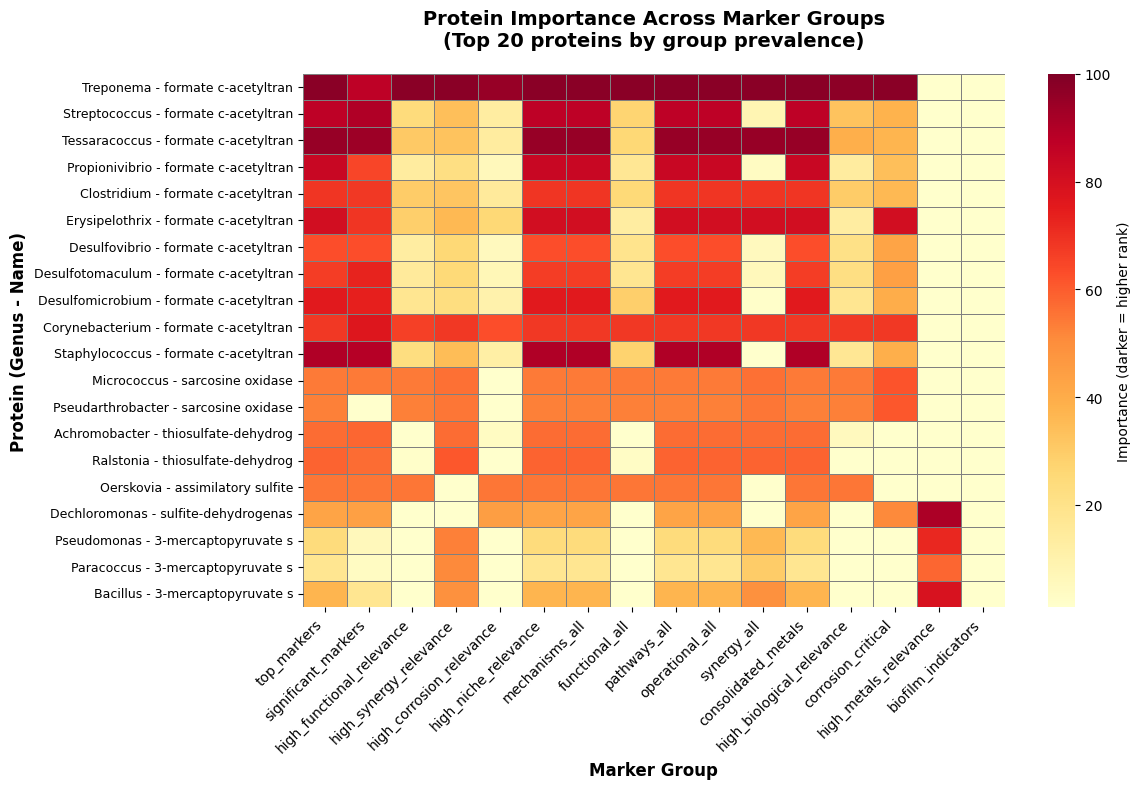

In [43]:
# Supergroups dictionary
groups_dict = {
    'top_markers': top_markers,
    'significant_markers': significant_markers,
    'high_metals_relevance': high_metals_relevance,
    'high_functional_relevance': high_functional_relevance,
    'high_synergy_relevance': high_synergy_relevance,
    'high_corrosion_relevance': high_corrosion_relevance,
    'high_niche_relevance': high_niche_relevance,
    'mechanisms_all': mechanisms_all,
    'functional_all': functional_all,
    'pathways_all': pathways_all,
    'operational_all': operational_all,
    'synergy_all': synergy_all,
    'consolidated_metals': consolidated_metals,
    #'inorganic_acid_complexes': inorganic_acid_complexes, # Removed due to low significance and relevance 
    #'organic_acid_complexes': organic_acid_complexes,
    'biofilm_indicators': biofilm_indicators,
    'high_biological_relevance': high_biological_relevance,
    'corrosion_critical': corrosion_critical
}

fig = plot_protein_importance_heatmap(groups_dict, top_n_proteins=20, top_n_per_group=100)
plt.show()

As can be seen in this plot there are redundancy on the information provided by symilar groups [pathways_all, consolidated_metals, funcional all, etc] all produce similar data, then there is another groups like high functional relevance and high biological relevance that also tell similar story. Ultimately the groups would be consolidated so that only some groups would be identify and consolidate the groups on 2-4.

## 4.3. Group Consolidation via Similarity Clustering
Here groups are reduce by identifying which ones tell the same biological story. This is a group similarity problem, no protein importance

In [44]:
def analyze_group_similarity_clustering(groups_dict, top_n_per_group=50, method='average'):
    """
    Cluster marker groups based on protein overlap to identify redundant groups
    and suggest consolidated super-groups.
    
    Parameters:
        groups_dict: Dictionary of {group_name: DataFrame}
        top_n_per_group: Number of top markers to consider from each group
        method: Clustering linkage method ('average', 'complete', 'single', 'ward')
    
    Returns:
        fig: matplotlib figure with dendrogram
        similarity_matrix: DataFrame showing pairwise Jaccard similarities
        cluster_assignments: DataFrame showing which groups belong to which cluster
    """
    # make sure no changing group dict
    group_dict = {k: v.copy() for k, v in groups_dict.items()}
    
    # Extract top proteins from each group
    group_proteins = {}
    
    for group_name, group_df in groups_dict.items():
        # Sort by combined_score and get top N
        sorted_group = group_df.sort_values('combined_score', ascending=False).head(top_n_per_group)
        
        # Create protein identifier (genus + protein_name)
        protein_ids = set(sorted_group['Genus'] + ' - ' + sorted_group['protein_name'])
        
        group_proteins[group_name] = protein_ids
        print(f"{group_name}: {len(protein_ids)} unique proteins")
    
    # Calculate Jaccard similarity matrix
    group_names = list(group_proteins.keys())
    n_groups = len(group_names)
    similarity_matrix = np.zeros((n_groups, n_groups))
    
    for i, group1 in enumerate(group_names):
        for j, group2 in enumerate(group_names):
            if i == j:
                similarity_matrix[i, j] = 1.0
            else:
                proteins1 = group_proteins[group1]
                proteins2 = group_proteins[group2]
                
                # Jaccard similarity: intersection / union
                intersection = len(proteins1 & proteins2)
                union = len(proteins1 | proteins2)
                
                similarity_matrix[i, j] = intersection / union if union > 0 else 0
    
    # Convert similarity to distance for clustering
    distance_matrix = 1 - similarity_matrix
    
    # Convert to condensed distance matrix for scipy
    condensed_dist = squareform(distance_matrix)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method=method)
    
    # Create dendrogram
    fig, ax = plt.subplots(figsize=(14, 8))
    
    dendrogram(
        linkage_matrix,
        labels=group_names,
        ax=ax,
        leaf_rotation=60,
        leaf_font_size=7, 
        color_threshold=0.001  # Can adjust this to see different cut levels 0.01-0.5
    )

    ax.set_title(f"Hierarchical Clustering of Marker Groups\n(Based {top_n_per_group} Protein Overlap)", 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Marker Group', fontsize=12, fontweight='bold')
    ax.set_ylabel('Distance (1 - Jaccard Similarity)', fontsize=12, fontweight='bold')
    
    # Add horizontal lines showing potential cut points for 3, 4, 5 clusters
    heights = linkage_matrix[:, 2]
    
    # Find distances that would give 3, 4, 5 clusters
    for n_clusters in [3, 4, 5]:
        if n_groups > n_clusters:
            # Get the merge height for n_clusters
            cut_height = heights[-(n_clusters-1)]
            ax.axhline(y=cut_height, color='red', linestyle='--', alpha=0.4, linewidth=1)
            ax.text(0.02, cut_height, f'{n_clusters} clusters',
                   transform=ax.get_yaxis_transform(), fontsize=7, color='red')
    
    plt.tight_layout()
    
    # Create similarity DataFrame for inspection
    similarity_df = pd.DataFrame(similarity_matrix, 
                                 index=group_names, 
                                 columns=group_names)
    
    # Generate cluster assignments for 3, 4, and 5 clusters
    print("\n=== SUGGESTED CLUSTER ASSIGNMENTS ===\n")
    
    cluster_results = {}
    for n_clusters in [3, 4, 5]:
        if n_groups > n_clusters:
            clusters = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
            
            print(f"--- {n_clusters} Clusters ---")
            cluster_dict = {}
            for cluster_id in range(1, n_clusters + 1):
                members = [group_names[i] for i, c in enumerate(clusters) if c == cluster_id]
                cluster_dict[f"Cluster_{cluster_id}"] = members
                print(f"Cluster {cluster_id} ({len(members)} groups):")
                for member in members:
                    print(f"  - {member}")
                print()
            
            cluster_results[n_clusters] = cluster_dict
    
    # Print highest similarity pairs to understand groupings
    print("\n=== HIGHEST SIMILARITY PAIRS ===")
    similarity_pairs = []
    for i in range(n_groups):
        for j in range(i+1, n_groups):
            similarity_pairs.append((group_names[i], group_names[j], similarity_matrix[i, j]))
    
    similarity_pairs.sort(key=lambda x: x[2], reverse=True)
    
    for group1, group2, sim in similarity_pairs[:10]:
        print(f"{group1} <-> {group2}: {sim:.3f} ({sim*100:.1f}% overlap)")
    
    return fig, similarity_df, cluster_results

top_markers: 31 unique proteins
significant_markers: 31 unique proteins
high_metals_relevance: 38 unique proteins
high_functional_relevance: 20 unique proteins
high_synergy_relevance: 29 unique proteins
high_corrosion_relevance: 18 unique proteins
high_niche_relevance: 31 unique proteins
mechanisms_all: 31 unique proteins
functional_all: 20 unique proteins
pathways_all: 31 unique proteins
operational_all: 31 unique proteins
synergy_all: 29 unique proteins
consolidated_metals: 31 unique proteins
biofilm_indicators: 62 unique proteins
high_biological_relevance: 20 unique proteins
corrosion_critical: 14 unique proteins

=== SUGGESTED CLUSTER ASSIGNMENTS ===

--- 3 Clusters ---
Cluster 1 (14 groups):
  - top_markers
  - significant_markers
  - high_functional_relevance
  - high_synergy_relevance
  - high_corrosion_relevance
  - high_niche_relevance
  - mechanisms_all
  - functional_all
  - pathways_all
  - operational_all
  - synergy_all
  - consolidated_metals
  - high_biological_relevanc

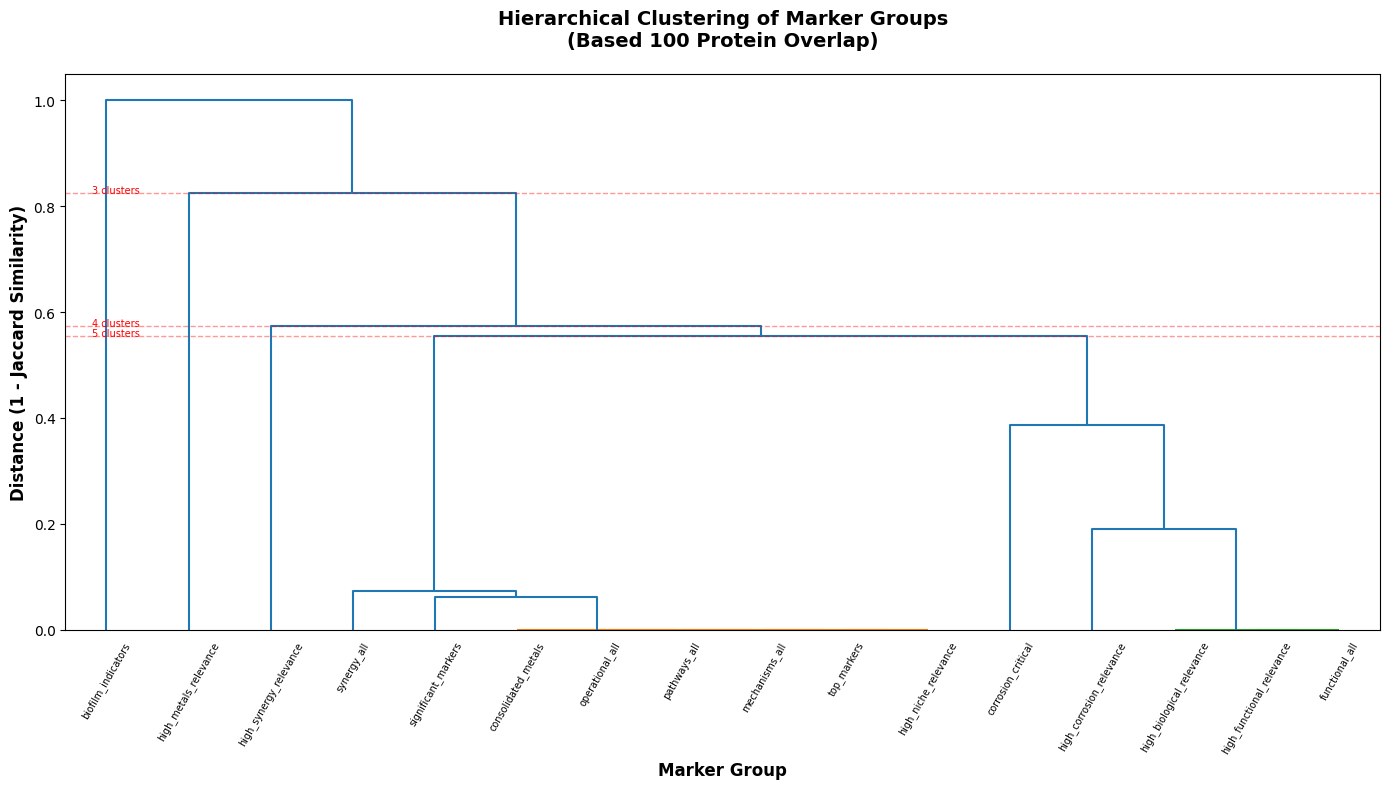


=== FULL SIMILARITY MATRIX ===
                           top_markers  significant_markers  \
top_markers                1.000        0.938                 
significant_markers        0.938        1.000                 
high_metals_relevance      0.278        0.278                 
high_functional_relevance  0.457        0.417                 
high_synergy_relevance     0.429        0.395                 
high_corrosion_relevance   0.441        0.441                 
high_niche_relevance       1.000        0.938                 
mechanisms_all             1.000        0.938                 
functional_all             0.457        0.417                 
pathways_all               1.000        0.938                 
operational_all            1.000        0.938                 
synergy_all                0.935        0.875                 
consolidated_metals        1.000        0.938                 
biofilm_indicators         0.000        0.000                 
high_biological_relevan

<Figure size 640x480 with 0 Axes>

In [45]:
fig, similarity_matrix, cluster_results = analyze_group_similarity_clustering(groups_dict, top_n_per_group=100, method='average')# average, single
plt.show()
output_path= data_visual /"10_hierarchi_group.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

# To see the full similarity matrix
print("\n=== FULL SIMILARITY MATRIX ===")
print(similarity_matrix.round(3))

## 4.4. Supergroups Creation 
To avoid redundancy across marker groups, a regrouping strategy was implemented by integrating nearest groups based on Jaccard similarity of their top 100 proteins (section 4.4, 1_visual_protein.ipynb). The ultimate objective is to identify protein-genus pairs as critical drivers of corrosion; In this study, the same protein in different genera represents different community members performing same function. Literature indicates that identical proteins across genera can serve different ecological roles. For instance, sarcosine oxidase in Micrococcus operates in an aerobic biofilm-forming context, while sarcosine oxidase in Pseudomonas functions in a facultative, planktonic lifestyle—these are not interchangeable from an ecological perspective (Hedlund et al., 1999). However the present data shown that the protein here expressed are highly redundant, so for these corrosion biomarkers, tracking the specific protein-organism provides better specificity and predictability. However, because these 85 genera derive from already classified and filtered groups, the protein-genus pairs seem to share metabolic similarity, and prior filtering validates functional equivalence within clusters.

The hierarchical clustering dendrogram reveals eight distinct clusters at the 5-cluster threshold:

cluster analysis:
|                        Cluster Members                   |                        Thematic Grouping                                                  | 
| :---------------------------------------------------------: | :------------------------------------------------------------------------------------- | 
|Cluster 1 (1 groups) : biofilm_indicators | Unique proteins, likely includes large, diverse structural genes (like EPS or cell wall components) that are distinct from the smaller metabolic/redox proteins driving the other groups.|  
|Cluster 2 (1 group): high_metal_relevance |high relevance scores to metal binding or transformation. |
|Cluster 3 (1 groups)--> organic_acid_complexes | group with presence of organic_complexes column |
|Cluster 4 (1 groups)--> inorganic_acid_complexes | group with presence of inorganic_complexes column |
|Cluster 5 (2 groups)--> synergy_control : high_synergy_relevance, synergy_all |groups markers characterized by synergistic interactions between multiple corrosion mechanisms.|
|Cluster 6 (8 groups)--> broad_corrosion: top_markers, significant_markers, high_niche_relevance, mechanisms_all,pathways_all, operational_all, consolidated_metals| This group is the Highly Redundant. All members have overlap in their top 50 proteins.|  
|Cluster 7 (1 groups)--> corrosion_critical : corrosion_critical| acid-mediated corrosion processes.|
|Cluster 8 (4 groups)--> bio_functional: high_functional_relevance, high_corrosion_relevance, functional_all, high_biological_relevance |This group focuses on the functional role of the genes. It separates groups explicitly related to general biological/functional importance |

Hedlund, B. P., Geiselbrecht, A. D., Bair, T. J., & Staley, J. T. (1999). Polycyclic aromatic hydrocarbon degradation by a new marine bacterium, Neptunomonas naphthovorans gen. nov., sp. nov. Applied and Environmental Microbiology, 65(1), 251–259. https://doi.org/10.1128/


In [46]:
def create_consolidated_supergroups(groups_dict, balanced_markers):
    """ Merge redundant groups into consolidated super-groups.
    Parameters:   groups_dict: dict of individual DataFrames (group_name -> DataFrame)
        balanced_markers: original balanced_markers DataFrame (not modified)
    Returns:  supergroups: dict with keys:- biofilm_structural- broad_metabolic- synergy_control - core_corrosion- metal_specific- pathway_specific    """
    balanced_markers = balanced_markers.copy()  # Ensure we don't modify the original
    supergroups = {}

    # Helper to safely concat a list of group names -> list of DataFrames
    def _concat_groups(names):
        dfs = [groups_dict[g] for g in names if g in groups_dict and groups_dict[g] is not None]
        return pd.concat(dfs, ignore_index=False) if dfs else None
    # SUPERGROUP 1: biofilm and structural drivers (same as previously)
    # SUPERGROUP 2: high_metal_relevance: metal specific drivers  (same as previously)
    #high_metals_relevance = high_metals_relevance
    
    # SUPERGROUP 3: synergy control
    synergy =['high_synergy_relevance','synergy_all']
    sg_con = _concat_groups(synergy)
    if sg_con is not None:
        supergroups['synergy_control'] = sg_con.drop_duplicates(subset=['idx'])
    # SUPERGROUP 4: broad corrosion drivers
    broad_names = ['top_markers', 'significant_markers', 'high_niche_relevance', 'mechanisms_all', 'pathways_all', 'operational_all', 'consolidated_metals', 'inorganic_acid_complexes']
    sg_met = _concat_groups(broad_names)
    if sg_met is not None:
        supergroups['broad_corrosion'] = sg_met.drop_duplicates(subset=['idx'])
   
    # SUPERGROUP 6: bio_functional drivers 
    high_names = ['high_functional_relevance', 'high_corrosion_relevance', 'functional_all', 'high_biological_relevance']
    sg_core = _concat_groups(high_names)
    if sg_core is not None:
        supergroups['bio_functional'] = sg_core.drop_duplicates(subset=['idx'])

    return supergroups

In [47]:
supergroups = create_consolidated_supergroups(groups_dict, balanced_markers)
# calling each of the groups individually # biofilm_indicators, high_metals_relevance
broad_corrosion = supergroups.get('broad_corrosion', pd.DataFrame())
bio_functional = supergroups.get('bio_functional', pd.DataFrame())
synergy_control = supergroups.get('synergy_control', pd.DataFrame())

## 4.5 Three-panel plot showing functional categories for each risk category's sites

In [48]:
def plot_functional_by_site_category(prioritized_markers, name):
    """Three-panel plot showing functional categories for each risk category's sites"""
    
    df = prioritized_markers.copy()
    
    # Ensure Category column exists
    if 'Category' not in df.columns:
        df['Category'] = df['Sites'].map(category_dict)
    
    # Validate all sites have categories
    if df['Category'].isna().any():
        missing_sites = df[df['Category'].isna()]['Sites'].unique()
        print(f"Warning: Sites missing from category_dict: {missing_sites}")
        df = df.dropna(subset=['Category'])
    
    df['Category'] = df['Category'].astype(int)
    
    # Collect data by site and category
    site_data = []
    
    for _, row in df.iterrows():
        site = row['Sites']
        category = row['Category']
        func_cat = row.get('functional_sub', '')
        
        if pd.notna(func_cat) and func_cat:
            # Use the abundance column matching this site's category
            abundance = row.get(f'mean_cat{category}', 0)
            
            site_data.append({
                'Site': site,
                'Category': category,
                'functional_cat': func_cat,
                'abundance': abundance
            })
    
    if not site_data:
        print("No functional_sub data available")
        return None
    
    site_df_agg = pd.DataFrame(site_data)
    
    # Create 3-panel figure
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)
    
    category_colors = {1: '#2E7D32', 2: '#F57C00', 3: '#D32F2F'}
    category_labels = {1: 'Normal Operation', 2: 'Early Warning', 3: 'System Failure'}
    
    for i, cat in enumerate([1, 2, 3]):
        cat_data = site_df_agg[site_df_agg['Category'] == cat]
        
        if len(cat_data) == 0:
            axes[i].text(0.5, 0.5, f'No sites in Category {cat}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f"{category_labels[cat]}\n(0 sites)")
            continue
        
        # Aggregate by functional category
        func_agg = cat_data.groupby('functional_cat')['abundance'].sum().sort_values(ascending=False).head(15)
        
        axes[i].barh(func_agg.index, func_agg.values, color=category_colors[cat])
        axes[i].set_title(f"{category_labels[cat]}\n({len(cat_data['Site'].unique())} sites)", fontsize=12)
        axes[i].set_xlabel('Total Abundance', fontsize=10)
        axes[i].tick_params(axis='y', labelsize=9)
        
        # Add value labels
        for idx, (func, val) in enumerate(func_agg.items()):
            axes[i].text(val + 0.02, idx, f'{val:.2f}', 
                        va='center', fontsize=8)
        
        if i == 0:
            axes[i].set_ylabel('Functional Category', fontsize=10)
    
    plt.suptitle(f"Functional Categories by Site Risk Category: {name}", fontsize=14, y=0.98)
    plt.tight_layout()
    return fig

/tmp/ipykernel_19840/2383537764.py:4: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



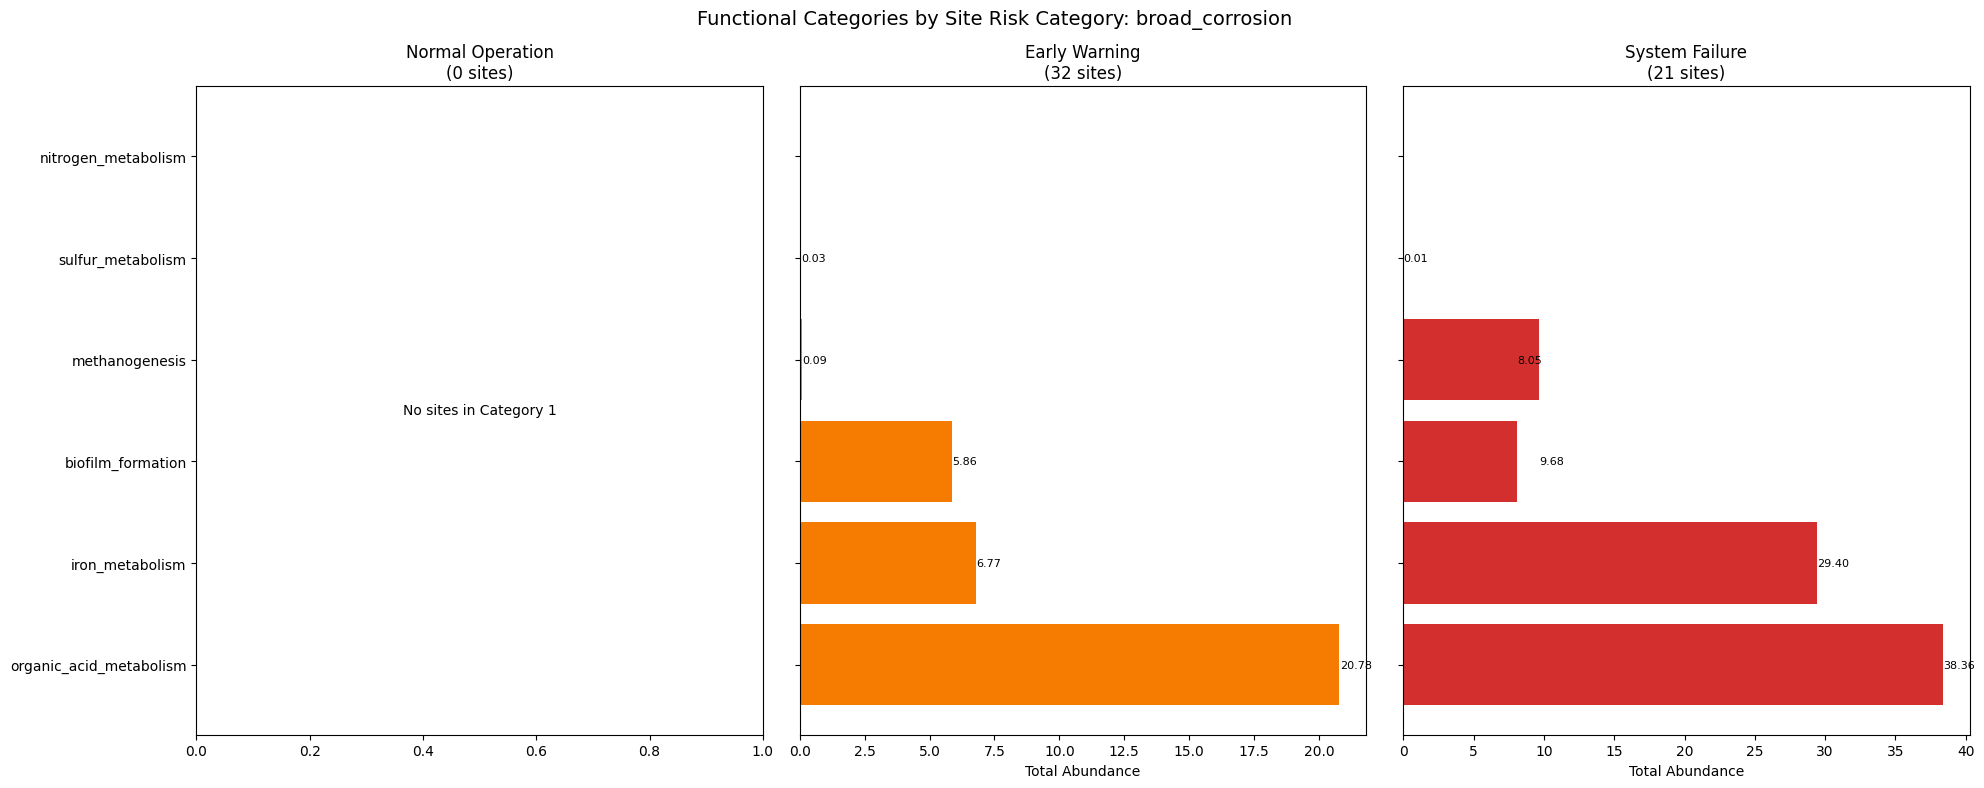

In [49]:
fig_12 = plot_functional_by_site_category(broad_corrosion,  'broad_corrosion')
fc_path = data_visual / "12_func_broad.png"
plt.savefig(str(fc_path), dpi=300, bbox_inches='tight')
fig_12.show()

DEBUG: color_by = Category, size_by = combined_score


/tmp/ipykernel_19840/3438165721.py:4: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



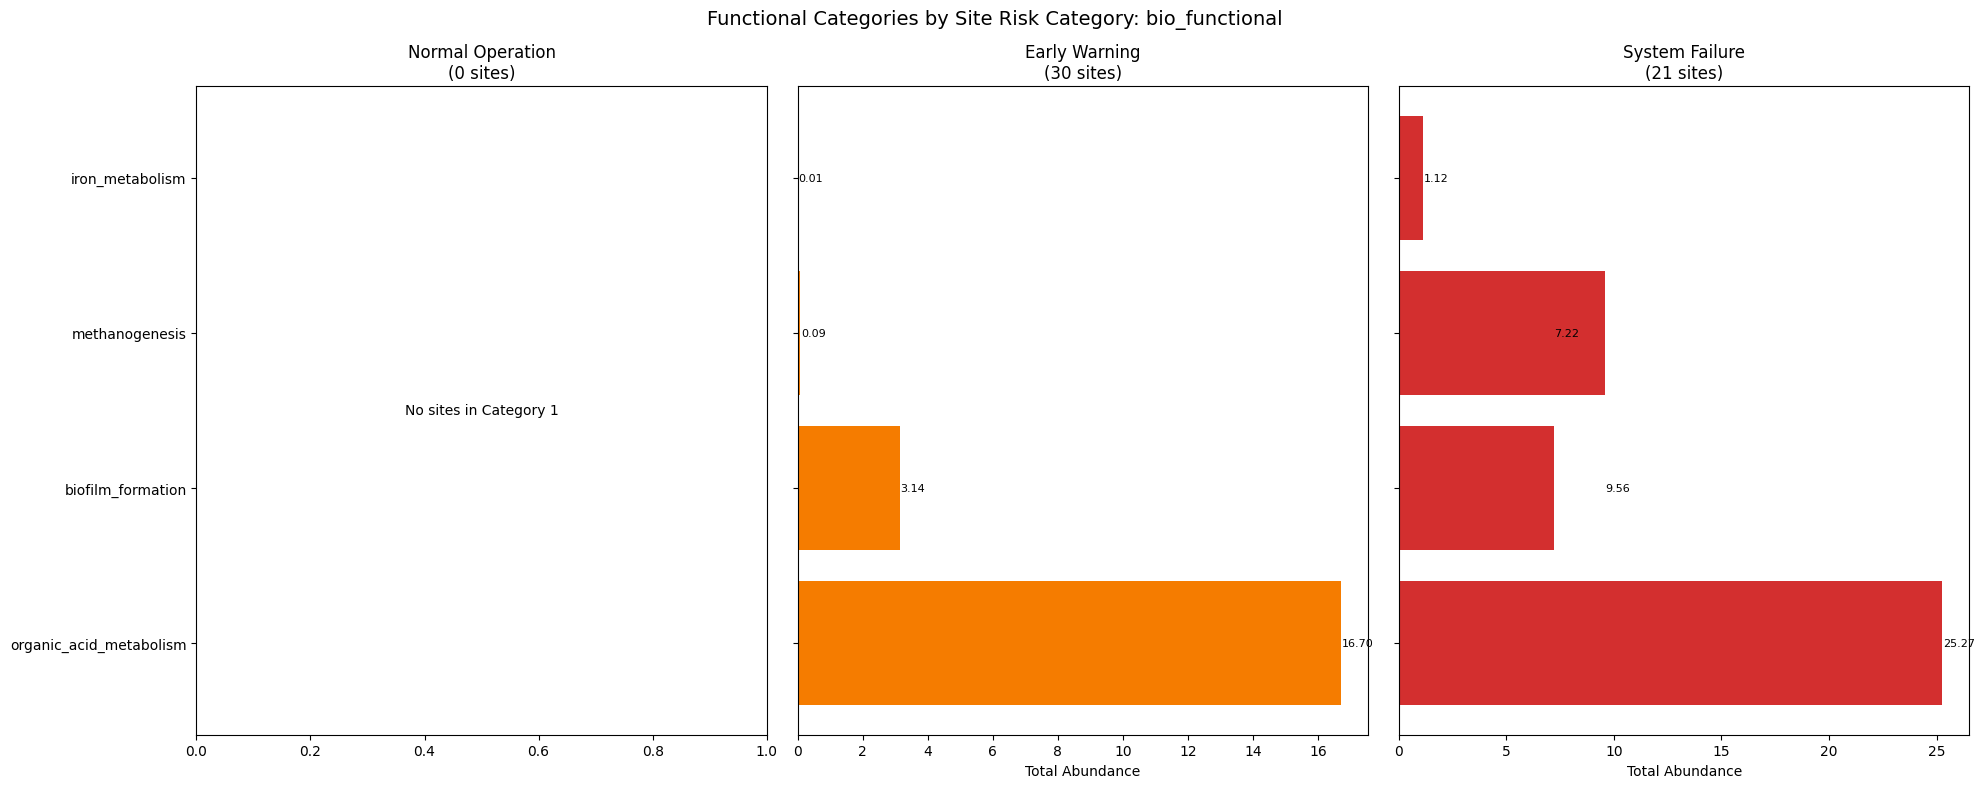

In [50]:
fig_12 = plot_functional_by_site_category(bio_functional, 'bio_functional')
fc_path = data_visual / "12_func_core.png"
plt.savefig(str(fc_path), dpi=300, bbox_inches='tight')
fig_12.show()

The functional category distribution (section 4.5, 1_visual_protein.ipynb) across risk categories confirms that the main mechanisms influencing corrosion across all consolidated groups are consistently organic acid metabolism, followed by biofilm formation toward system early warning and sytem failure, with methanogenesis and iron metabolism appearing only in failed systems. The absence of Normal Operation sites in these filtered groups is expected. These results, while derived from actual operational systems, are very consistent with established MIC environments.

## 4.6. Protein-genus by complexation type with Inorganic Complex and Organic Complex as Annotations

In [51]:
def plot_complexation_proteins(df, name):
    """
    Plot protein-genus by complexation type with complex details as annotations.
    
    X-axis: Inorganic vs Organic complexation
    Y-axis: Protein-Genus pairs
    Annotations: Specific complex agents
    """
    df = df.copy()
    # Filter to rows with complexation
    has_inorg = df['inorganic_complex'].str.len() > 0
    has_org = df['organic_complex'].str.len() > 0
    df_complex = df[has_inorg | has_org].copy()
    
    if len(df_complex) == 0:
        print("No complexation data found")
        return None
    
    # Create protein-genus label
    df_complex['protein_genus'] = (
        df_complex['Genus'].astype(str) + " - " + 
        df_complex['protein_name'].astype(str).str[:30]
    )
    
    # Extract complex agents (text after "with")
    def extract_agents(complex_str):
        if not isinstance(complex_str, str) or not complex_str.strip():
            return ""
        if ' with ' in complex_str:
            return complex_str.split(' with ', 1)[1]
        return ""
    
    df_complex['inorg_agents'] = df_complex['inorganic_complex'].apply(extract_agents)
    df_complex['org_agents'] = df_complex['organic_complex'].apply(extract_agents)
    
    # Prepare data for plotting
    plot_data = []
    
    for _, row in df_complex.iterrows():
        protein_genus = row['protein_genus']
        
        # Inorganic
        if row['inorg_agents']:
            plot_data.append({
                'protein_genus': protein_genus,
                'type': 'Inorganic',
                'agents': row['inorg_agents'],
                'abundance': row.get('mean_cat3', 0)
            })
        
        # Organic
        if row['org_agents']:
            plot_data.append({
                'protein_genus': protein_genus,
                'type': 'Organic',
                'agents': row['org_agents'],
                'abundance': row.get('mean_cat3', 0)
            })
    
    if not plot_data:
        print("No complex agents extracted")
        return None
    
    plot_df = pd.DataFrame(plot_data)
    
    # Get top proteins by abundance
    top_proteins = (plot_df.groupby('protein_genus')['abundance']
                    .mean()
                    .sort_values(ascending=False)
                    .head(20)
                    .index)
    
    plot_df = plot_df[plot_df['protein_genus'].isin(top_proteins)]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Set up discrete positions
    type_pos = {'Inorganic': 0, 'Organic': 1}
    protein_order = list(top_proteins)
    
    # Plot points
    for idx, row in plot_df.iterrows():
        x = type_pos[row['type']]
        y = protein_order.index(row['protein_genus'])
        
        # Size by abundance
        size = max(50, min(300, row['abundance'] * 100))
        
        # Color by type
        color = '#ff7f0e' if row['type'] == 'Inorganic' else '#2ca02c'
        
        ax.scatter(x, y, s=size, c=color, alpha=0.6, edgecolors='black', linewidth=0.5)
        
        # Annotate with agents
        ax.text(x + 0.05, y, row['agents'], 
                fontsize=8, va='center', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'))
    
    # Format plot
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Inorganic', 'Organic'], fontsize=11)
    ax.set_yticks(range(len(protein_order)))
    ax.set_yticklabels(protein_order, fontsize=9)
    ax.set_xlabel('Complexation Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('Genus - Protein', fontsize=12, fontweight='bold')
    ax.set_title(f'Protein Complexation Patterns - {name}\n(Size = abundance, annotations = complex agents)', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xlim(-0.3, 1.3)
    
    plt.tight_layout()
    
    print(f"\n=== Complexation Summary for {name} ===")
    print(f"Total protein-genus with complexation: {len(df_complex)}")
    print(f"Inorganic complexes: {has_inorg.sum()}")
    print(f"Organic complexes: {has_org.sum()}")
    print(f"Top 20 shown in plot")
    
    return fig


=== Complexation Summary for synergy_all ===
Total protein-genus with complexation: 179
Inorganic complexes: 75
Organic complexes: 108
Top 20 shown in plot


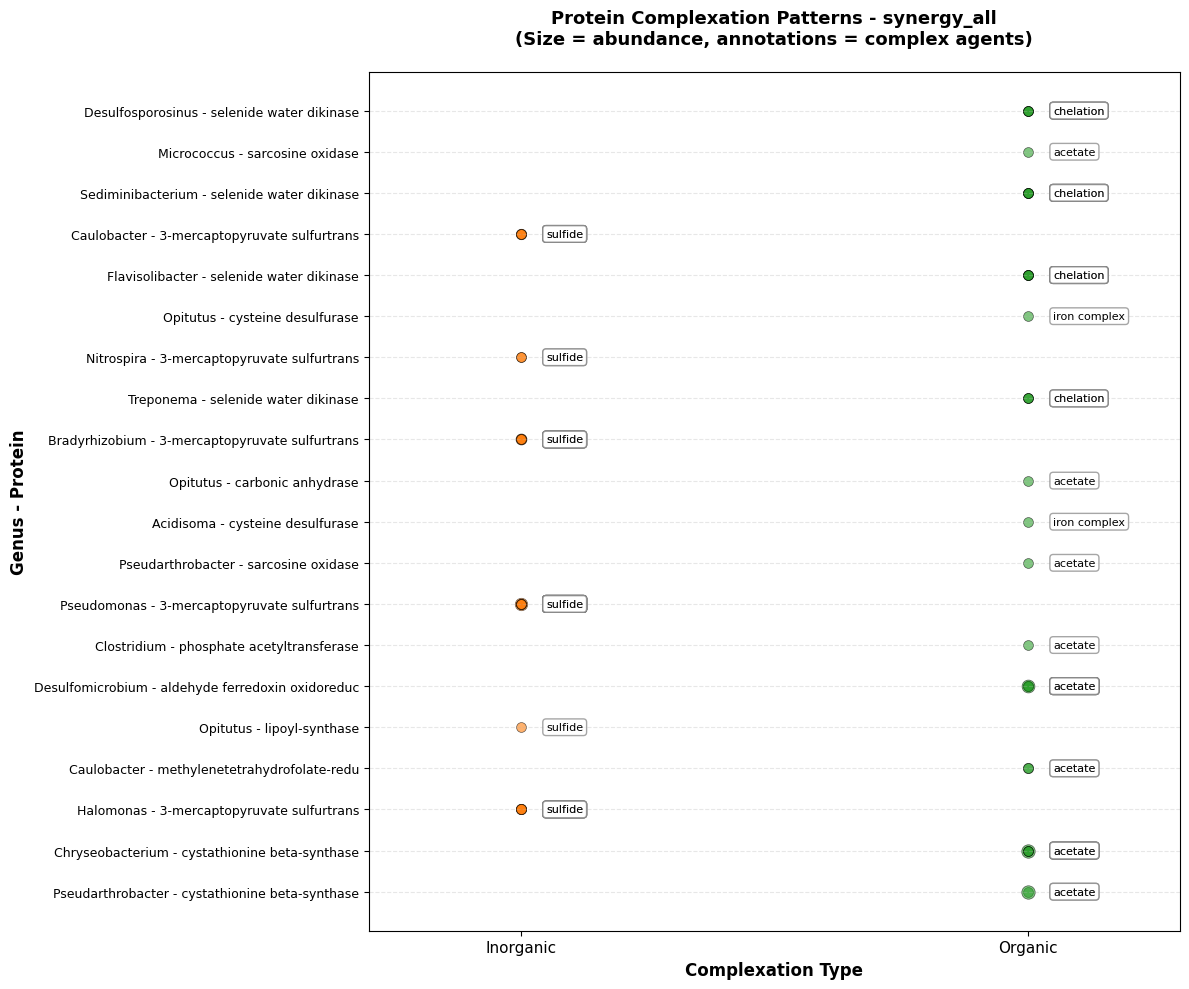

<Figure size 640x480 with 0 Axes>

In [52]:
fig = plot_complexation_proteins(synergy_all, "synergy_all")
plt.show()
prot_path = data_visual/"28_synergy_matrix.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

This plots present the relationship of the genus-protein pairs with the iorganic/organic complexes. It can be seen a missclassification of sulfide on the inorganic type. 3-Mercaptopyruvate Sulfurtransferase (3-MST) catalyzes 3-mercaptopyruvate + cyanide producing  pyruvate + thiocyanate, which makes part of the organic sulfur metabolism by producing sulfide (H₂S) from organic sulfur compounds (cysteine, mercaptopyruvate), so the sulfide noted as inorganic is in reality organic. 


=== Complexation by Function - Synergy All ===
Functional categories: 2
Categories: iron_metabolism, organic_acid_metabolism
Top 25 protein-genus pairs shown


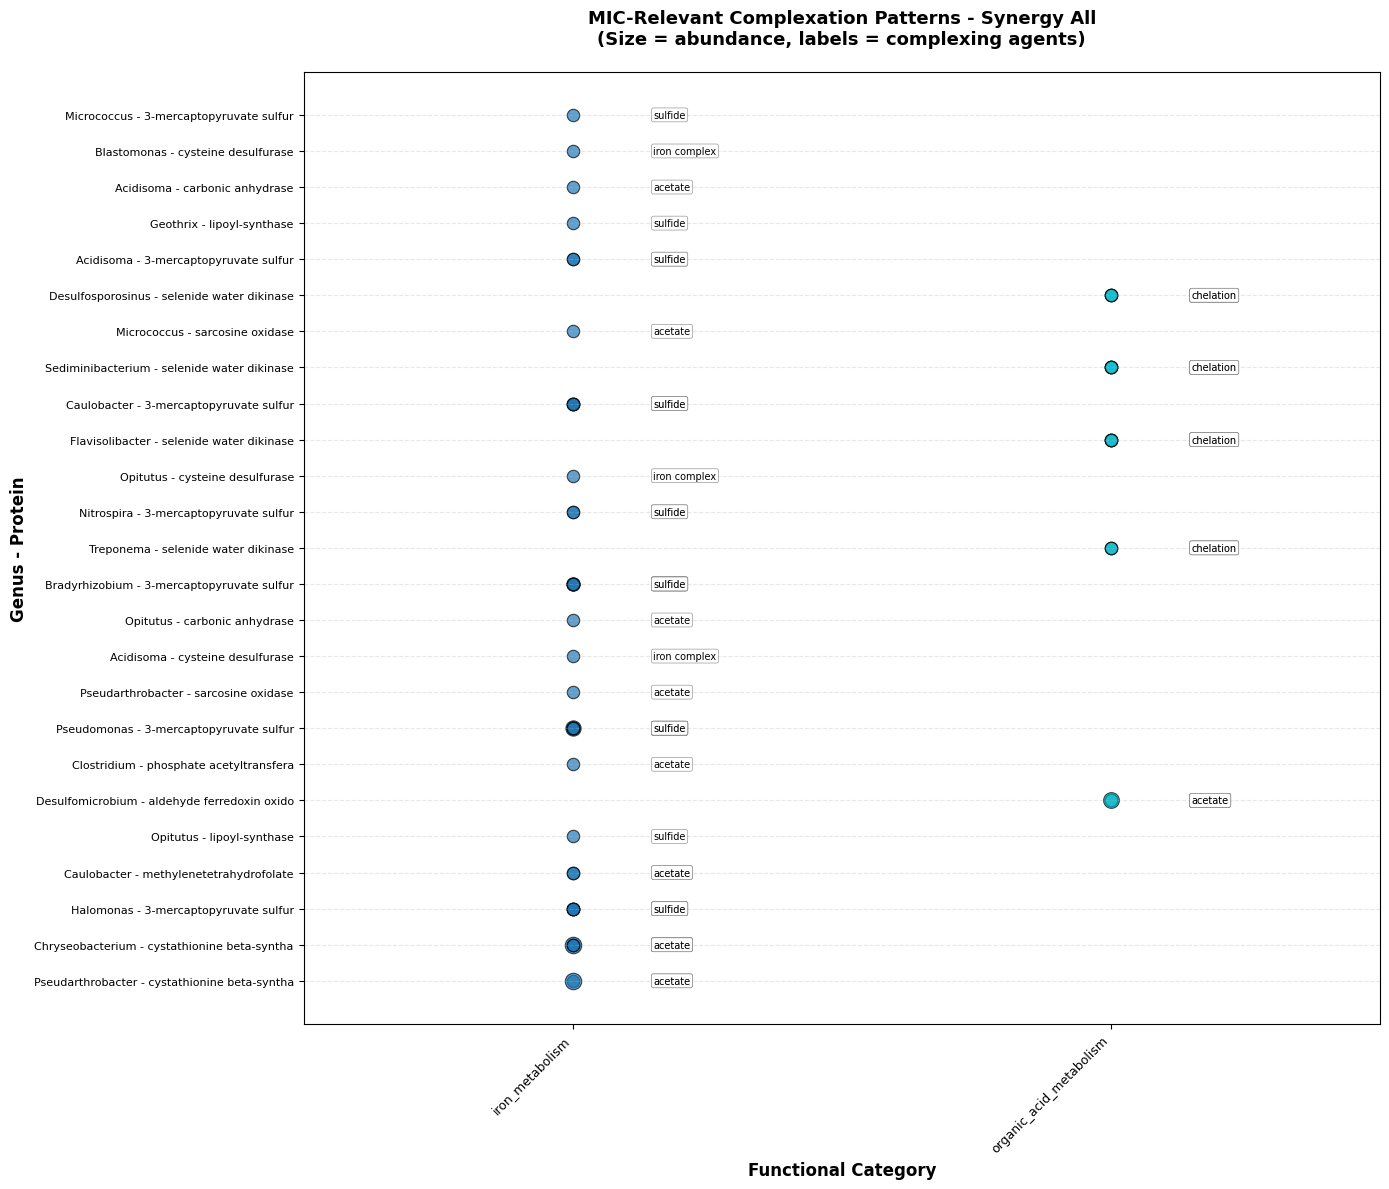

In [53]:
def plot_complexation_by_function(df, name, top_n=30):
    """
    Plot protein-genus by functional category with complex details.
    
    X-axis: functional_sub categories
    Y-axis: Protein-Genus pairs
    Annotations: Complex agents
    """
    df = df.copy()
    # Filter to rows with complexation AND functional_sub
    has_complex = (df['inorganic_complex'].str.len() > 0) | (df['organic_complex'].str.len() > 0)
    has_func = df['functional_sub'].notna() & (df['functional_sub'].str.strip() != '')
    df_complex = df[has_complex & has_func].copy()
    
    if len(df_complex) == 0:
        print("No complexation data with functional categories found")
        return None
    
    # Create protein-genus label
    df_complex['protein_genus'] = (
        df_complex['Genus'].astype(str) + " - " + 
        df_complex['protein_name'].astype(str).str[:25]
    )
    
    # Extract ALL complex agents (combine inorg + org)
    def extract_all_agents(row):
        agents = []
        
        # Inorganic agents
        inorg = row['inorganic_complex']
        if isinstance(inorg, str) and ' with ' in inorg:
            agents.extend([a.strip() for a in inorg.split(' with ', 1)[1].split(';')])
        
        # Organic agents
        org = row['organic_complex']
        if isinstance(org, str) and ' with ' in org:
            agents.extend([a.strip() for a in org.split(' with ', 1)[1].split(';')])
        
        return ', '.join(set(agents)) if agents else ''
    
    df_complex['all_agents'] = df_complex.apply(extract_all_agents, axis=1)
    
    # Keep only rows with agents
    df_complex = df_complex[df_complex['all_agents'] != ''].copy()
    
    # Get top protein-genus by abundance
    top_proteins = (df_complex.groupby('protein_genus')['mean_cat3']
                    .mean()
                    .sort_values(ascending=False)
                    .head(top_n)
                    .index)
    
    df_plot = df_complex[df_complex['protein_genus'].isin(top_proteins)].copy()
    
    # Get unique functional categories
    func_cats = df_plot['functional_sub'].unique()
    
    print(f"\n=== Complexation by Function - {name} ===")
    print(f"Functional categories: {len(func_cats)}")
    print(f"Categories: {', '.join(func_cats)}")
    print(f"Top {top_n} protein-genus pairs shown")
    
    # Create plot
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Assign positions
    func_pos = {cat: i for i, cat in enumerate(sorted(func_cats))}
    protein_order = list(top_proteins)
    
    # Color palette for functional categories
    colors = plt.cm.tab10(np.linspace(0, 1, len(func_cats)))
    func_colors = {cat: colors[i] for i, cat in enumerate(sorted(func_cats))}
    
    # Plot points
    for _, row in df_plot.iterrows():
        x = func_pos[row['functional_sub']]
        y = protein_order.index(row['protein_genus'])
        
        # Size by abundance
        size = max(80, min(400, row['mean_cat3'] * 150))
        
        ax.scatter(x, y, s=size, 
                  c=[func_colors[row['functional_sub']]], 
                  alpha=0.7, edgecolors='black', linewidth=0.8)
        
        # Annotate with agents (shortened)
        agents_short = row['all_agents'][:40] + '...' if len(row['all_agents']) > 40 else row['all_agents']
        ax.text(x + 0.15, y, agents_short, 
                fontsize=7, va='center', ha='left',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.5))
    
    # Format plot
    ax.set_xticks(list(func_pos.values()))
    ax.set_xticklabels(list(func_pos.keys()), fontsize=9, rotation=45, ha='right')
    ax.set_yticks(range(len(protein_order)))
    ax.set_yticklabels(protein_order, fontsize=8)
    ax.set_xlabel('Functional Category', fontsize=12, fontweight='bold')
    ax.set_ylabel('Genus - Protein', fontsize=12, fontweight='bold')
    ax.set_title(f'MIC-Relevant Complexation Patterns - {name}\n(Size = abundance, labels = complexing agents)', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xlim(-0.5, len(func_cats) - 0.5)
    
    plt.tight_layout()
    
    return fig

# Usage:
fig = plot_complexation_by_function(synergy_all, "Synergy All", top_n=25)
plt.show()

## 4.7. Top Markers by Score -
Bar chart showing the highest scoring markers

In [54]:
def plot_top_markers_by_score(prioritized_markers, name, top_n=20, figsize=(8, 6)):
    """
    Create a horizontal bar chart of top markers by score
    """
    prioritized_markers = prioritized_markers.copy()
    # Get top markers
    top_markers = prioritized_markers.head(top_n)

    # Create labels
    labels = [f"{row['Genus']} - {row['protein_name'][:100]}"
              for _, row in top_markers.iterrows()]

    # Create figure
    plt.figure(figsize=figsize)

    # Plot horizontal bars
    plt.barh(range(len(labels)), top_markers['combined_score'], color='steelblue')

    # Add labels and title
    plt.yticks(range(len(labels)), labels)
    plt.xlabel('Combined Score')
    plt.title(f'{top_n} {name} Markers by Score')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    return plt.gcf()

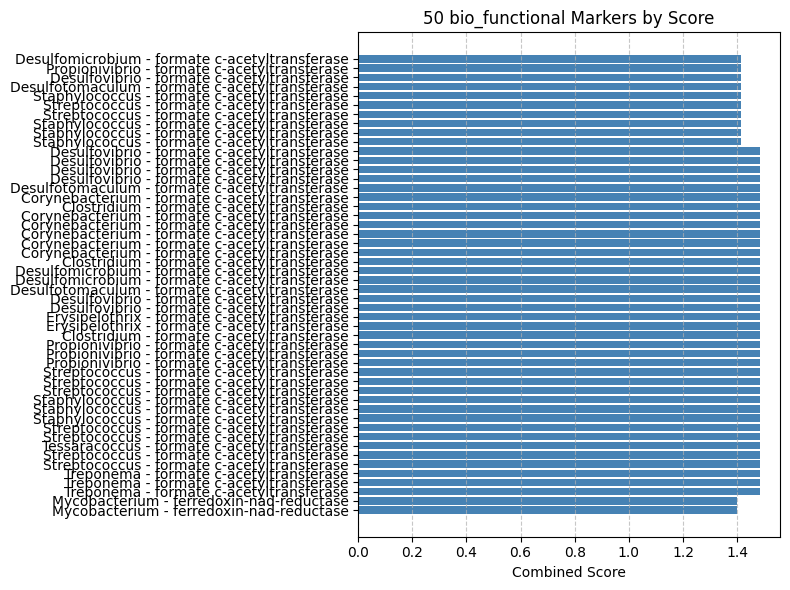

In [55]:
plot_top_markers_by_score(bio_functional, "bio_functional", top_n=50, figsize=(8, 6))

prot_path = data_visual/"22_prot-genus.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

Previous sections demonstrate that different genera express different metabolic enzymes but converge on the same corrosion-critical proteins at high abundance, validating that substrate utilization capacity depends on expressed protein concentration, not encoded pathway potential. This shifts prevention strategy from targeting specific bacterial taxa or metabolic pathways, instead should shift towards disrupting the expression or function of the convergent protein set that all successful corrosion communities must deploy regardless of their metabolic route to failure. 
There are persistent proteins that are common to several groups and therefore likely to be important, such as formate C‑acetyltransferase, thiosulfate dehydrogenase, assimilatory sulfite reductase, sarcosine oxidase and sulfite dehydrogenase. However, these heatmaps do not answer the question of which specific protein–genus pairs are most influential for corrosion.

## 4.8. Top Proteins by Shared Genera
This plot aims to convey the top protein paired with the actual genera expresing them for the top 20 markers, so that the actual most dramatically populated pairs are diluciated.

In [56]:
def plot_top_proteins_by_shared_genera(prioritized_markers, name, top_n=20, min_score=0, figsize=(12, 8)):
    """
    Create a horizontal bar plot showing proteins and all genera that express them.
    Sorted by combined score with better display of genera information.
    """
    prioritized_markers = prioritized_markers.copy()
    # Filter by minimum score if needed
    if min_score > 0:
        prioritized_markers = prioritized_markers[prioritized_markers['combined_score'] >= min_score]
    
    # Create protein-genus mapping with ALL occurrences
    protein_genus_data = []
    
    for _, row in prioritized_markers.iterrows():
        protein_name = row['protein_name']
        genus = row['Genus']
        score = row['combined_score']
        
        # Standardize protein name
        if isinstance(protein_name, str):
            # Clean up protein names
            protein_name = protein_name.replace('[', '').replace(']', '').strip()
        
        protein_genus_data.append({'protein_name': protein_name,'genus': genus,'combined_score': score})
    
    df_mapping = pd.DataFrame(protein_genus_data)
    
    # Group by protein and aggregate ALL genera (don't limit to top_markers only)
    protein_analysis = df_mapping.groupby('protein_name').agg({'genus': lambda x: list(x.unique()),'combined_score': 'max'}).reset_index()
    
    # Add count of unique genera per protein
    protein_analysis['genus_count'] = protein_analysis['genus'].apply(len)
    
    # Sort by combined score and take top N
    protein_analysis = protein_analysis.sort_values('combined_score', ascending=False).head(top_n)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare data for plotting
    y_positions = range(len(protein_analysis))
    scores = protein_analysis['combined_score']
    
    # Create horizontal bars
    bars = ax.barh(y_positions, scores, color='steelblue', alpha=0.7)
    
    # Create detailed labels
    labels = []
    for _, row in protein_analysis.iterrows():
        protein_name = row['protein_name']
        # Truncate very long protein names
        if len(protein_name) > 40:
            protein_name = protein_name[:37] + "..."
        
        # Format genera list
        genera = sorted(row['genus'])
        genus_count = row['genus_count']
        
        # Show all genera if 5 or less, otherwise show first 3 and count
        if genus_count <= 5:
            genera_display = ', '.join(genera)
        else:
            genera_display = f"{', '.join(genera[:3])}, ... (+{genus_count-3} more)"
        
        # Combine into label
        labels.append(f"{protein_name}\n({genus_count} genera: {genera_display})")
    
    # Set labels and formatting
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Combined Score', fontsize=11)
    ax.set_title(f' Group {name}:Genera  grouped by Top {top_n} Proteins', fontsize=13)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}', 
                ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    return fig

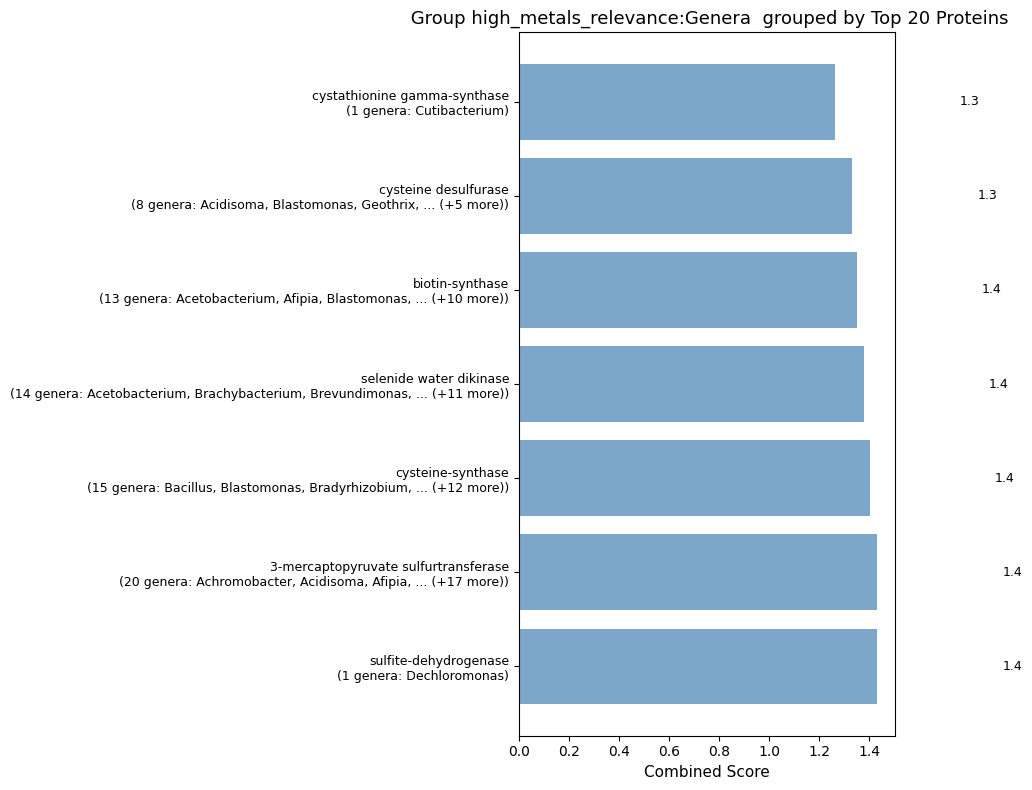

In [57]:
fig1 = plot_top_proteins_by_shared_genera(high_metals_relevance,  "high_metals_relevance", top_n=20)#biofilm_indicators, "biofilm_indicators", top_n=20) #
plt.figure(fig1.number)
plt.show()
prot_path = data_visual/"24_prot-genus.png"
#plt.savefig(prot_path, dpi=300, bbox_inches='tight')

The heatmaps in Section 4.7 showed that different genera converge on a subset of persistent proteins, which motivated the development of the function plot_top_proteins_by_shared_genera. This plot visualises proteins ranked by combined score and the number of genera that encode them, allowing inspection of proteins that recur across taxonomically diverse communities

-The high_metals_relevance group shows 3-mercaptopyruvate sulfurtransferase (20), cysteine synthase (15),  selenide, water dikinase (14) and biotin synthase (13), cysteine desulfurase (8) as the major protein shared by most genera. These enzymes underscore the criticality of sulfur trafficking and the potential for biogenic sulfide production or iron-sulfur cluster repair in metal-rich environments.

For the group corrosion_critical, the profile focuses on organic acidogenesis and oxidative stress management, formate c-acetyltransferase(11) is the most frequent proteins. Revealing a profile centered on organic acid production and oxidative stress response

Group bio_functional contains formate c-acetyltransferase(15), cytein desulfurase(8), L-aspartate oxidase(30), catalase(19), cysteine-syntase(14), alcohol dehydrogenase(13), indicating that oxygen scavenging and amino acid catabolism are widespread survival strategies.
 
Broad_corrosion group has formate c-acetyltransferase(15),  selenide, water dikinase(15), L-aspartate oxidase(30), catalase(25), cysteine-syntase(16), alcohol-dehydrogenase(13), acetate-kinase (23), 3-mercaptopyruvate sulfurtransferase(20)

synergy all group major players are: formate c-acetyltransferase(15),lipoyl syntase (12), selenide, water dikinase(15), L-aspartate oxidase(22),alcohol dehydrogenase (11), 3-mercaptopyruvate sulfurtransferase(19),glycerol kinase(8).

high_synergy_relevance:  formate c-acetyltransferase(15), selenide, water dikinase (15),lipoyl syntase (12), glycerol kinase (8), cysteine desulfurase(8)

Biofilm_indicators has varios specific markers: 3-hydroxy-acid dehydratase (56), ketol-acid reductoisomerase (46) which is involved in isoleucine/valine synthesis, acetolactate synthase small subunit (44), succinate dehydrogenase iron sulfur subunit (6), succinate dehydrogenase flavoprotein (17), alcohol dehydrogenase (15) suggesting a reliance on different proteins for biofilm formation. The Biofilm_indicators group features unique, high-scoring proteins tied to branched-chain amino acid (BCAA) biosynthesis and respiratory metabolism, distinguishing it from other groups. These enzymes support biofilm matrix production via hydrophobic amino acids (e.g., leucine, isoleucine) that enhance adhesion and structural integrity. BCAA Biosynthesis Cluster: The top three (3-hydroxy-acid dehydratase/ilvD, ketol-acid reductoisomerase/ilvC, acetolactate synthase/ilvH) form a coordinated pathway for isoleucine/leucine/valine production. In biofilms, BCAAs contribute to protein hydrophobicity, EPS stabilization, and quorum sensing signals, making this a hallmark of persistent adhesion under nutrient limitation. This group is in itself no related to MIC.

Alcohol Dehydrogenase Overlap: Its ubiquity across groups reinforces redox balancing for mixed fermentation, but here it may specifically oxidize alcohols from BCAA catabolism to sustain matrix polysaccharides.

Formate C-acetyltransferase is a major player on all the groups and a catabolic enzyme. It converts pyruvate into acetyl-CoA and formate. In several MIC-relevant species, formate can be used to degrade sialic acids (components of the biofilm matrix). This suggests a metabolic shift: rather than accumulating thick, protective exopolysaccharides (EPS), the community may be prioritizing acidogenesis. The resulting production of formic acid and acetic acid (via acetate kinase) drives localized pH drops at the metal interface. Therefore, the "failed system" is showing clearly now as previously also indicated, the decrease in biofilm  because the metabolic flux is diverted toward aggressive organic acid activity, which is often more corrosive than the physical presence of the biofilm itself.

The consistent appearance of sulfur-handling proteins (3-mercaptopyruvate sulfurtransferase, cysteine synthase, selenide, water dikinase) alongside organic acid proteins (formate C-acetyltransferase, acetate kinase, alcohol dehydrogenase) across multiple groups confirms these two functional axes—sulfur metabolism and acidogenesis—as the irreducible core of these MIC communities.
It can seen that many proteins on this systems overlap between groups,  but also have some proteins that are no common to other bacteria, but have similar function.
There are three major axis of recurring proteins :

    The Sulfur Axis (S-Trafficking & Mineralization)

        3-mercaptopyruvate sulfurtransferase: Key for cyanide detoxification and H₂S signaling.

        cysteine synthase/cysteine desulfurase: Critical for mobilizing sulfur from amino acids to form Fe-S clusters.

        selenide, water dikinase (14): Involved in selenoprotein synthesis, often linked to high-efficiency redox enzymes and anaerobic respiration.

    Acid / redox axis (Metabolic Force)

        formate C-acetyltransferase: The gatekeeper of anaerobic glucose fermentation to organic acids.

        acetate kinase:Primary enzyme for ATP generation via acetate production.

        alcohol dehydrogenase: Manages redox balance (NAD+/NADH) during fermentation.

        carbonic anhydrase: Regulates local pH and CO2​/HCO3−​ equilibria, influencing carbonate scaling.

   The stress tolerance and persistence axis

        catalase: Protects the community from oxidative bursts (often triggered by corrosion products or biocides).

        L-aspartate oxidase: 
        A precursor for NAD biosynthesis, essential for all metabolic activity.

        lipoyl synthase: Essential for the function of the pyruvate dehydrogenase complex.
    

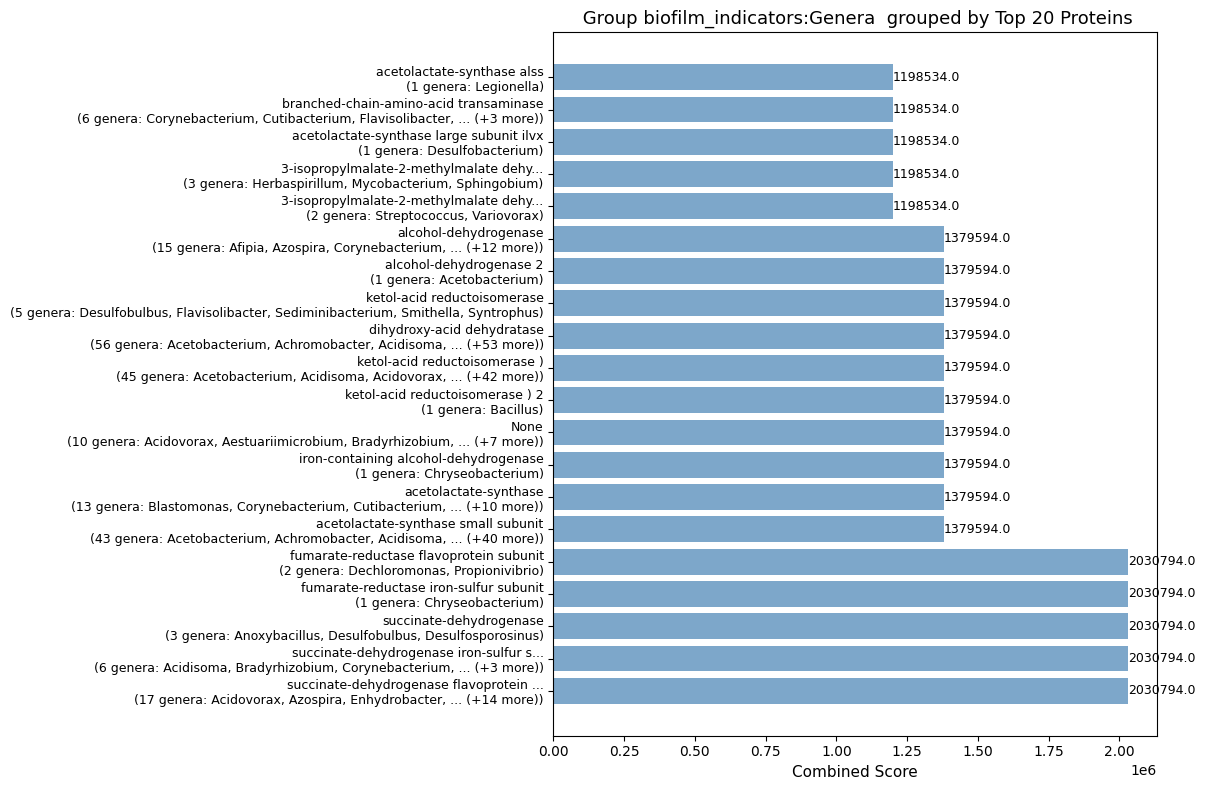

<Figure size 640x480 with 0 Axes>

In [58]:
fig1 = plot_top_proteins_by_shared_genera(biofilm_indicators,  "biofilm_indicators", top_n=20)#biofilm_indicators, "biofilm_indicators", top_n=20) #
plt.figure(fig1.number)
plt.show()
prot_path = data_visual/"24_prot-genus.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

The biofilm_indicators group showed very few shared proteins which explain its isolation in the dendrogram. This is no consistent with previous analyses where numerous biofilm-associated proteins were identified as significant, which in this plot are not seen, that could be explained due to the fact that the pipeline analyze_corrosion_proteins separated universal from niche specific pathways which in turn decreased the influence of such proteins like elonyl and 3-oxyl that were most notorious when the pipeline was done on the first approximation. In this implementation the top 20 markers pathways resulted from notebook 6_functional_picrust were integrated and the whole pipeline analyze_corrosion_proteins was run again integrating the biofilm indicators as a parallel set of markers that are only gone through the pattern filter, universal/niche classification, pattern separation and knee abundance (relaxed to 50%). The grouping criteria for biofilm_indicators contains different set of markers per Site because the markers criteria is expresely enfatising on metal presence. Now the biofilm functional signature exists as a parallel feature on the general landscape of corrosion environment features that influence corrosion.

We have stablish that main metabolism when starting the 85 genera on section 3.1 for the general group was oxigen consumption and that for more filter group was organic acid metabolim. We have stablished that there are pioneer species that tip at cat 2 and are neglegible at cat 3. We also know that no all the top protein present on the most interesting groups correspond directly to metal eaters, but there is a huge presence of generalist such as PFL/Neu5Ac building cells, that ultimately also are use for respiration. So such proteins are the enginee that keep formate/H2 flowing to the piting specialist, this specialist are directly corrosive bacteria. It is also certain that in failed  systems organic acid metabolism is the lead cause of corrosion followed by iron metabolism, and sulfur metabolism and biofilm formation. So priorities has to be stablishes as follows:
__Priority 1__: Direct metal respirators and sulfur redox catalysts:
Proteins such as ferredoxin‑linked enzymes (including aldehyde:ferredoxin oxidoreductase), cysteine desulfurase, assimilatory sulfite reductase and sulfite/thiosulfate dehydrogenases sit at the interface of iron–sulfur cluster metabolism and reduced sulfur pools, and are frequently associated with Fe²⁺/Fe³⁺, S²⁻/SO₄²⁻ and other metals in the metal–organic profiles. These enzymes are best interpreted as direct metal respirators or high‑flux sulfur redox hubs, capable of accepting or routing electrons from Fe⁰ or from metal‑sulfur complexes and thereby driving pitting.

__Priority 2__: Metal–organic acid accelerators and detox–redox connectors, enzymes such as 3‑mercaptopyruvate sulfurtransferase, sarcosine oxidase, selenide:water dikinase (selD) and cysteine synthase link organic‑acid and amino‑acid metabolism to sulfur, selenium and transition‑metal chemistry. These proteins are often associated with Fe²⁺, Zn²⁺, Cd²⁺ and other metals together with acetate or other low‑molecular‑weight organics, consistent with metal–organic complex formation, detoxification, and redox cycling that can accelerate corrosion in the presence of organic acids.


__Priority 3__: Biomass and formate/H₂ suppliers. Those are generalist central‑metabolism enzymes such as PFL/formate C‑acetyltransferase, alcohol dehydrogenases and related organic‑acid pathways are nearly ubiquitous in the filtered data, reflecting their role in breaking down sugars and Neu5Ac to pyruvate, formate and small acids. These enzymes are not primary initiators of metal attack but act as the engine that sustains growth and supplies diffusible electron carriers (formate, H₂, acetate) to the Priority‑1 and Priority‑2 systems. Their ubiquity across genera supports the view that they define the metabolic backbone of corrosive biofilms, while the metal‑associated proteins above determine how efficiently that backbone is coupled to direct metal dissolution

# 5. Metal Explosions
## 5.1. Ion Species Involvement by important Proteins
Which proteins bind ion species (selective) and are relevant and important to the markers we targeted.


=== Ion Species-Protein Analysis ===
Total ion-protein associations: 2736
Unique proteins: 24
Ion diversity range: 4-19
Adaptive threshold for 'selective': ≤6 ion species
Selective proteins (≤6 species): 6


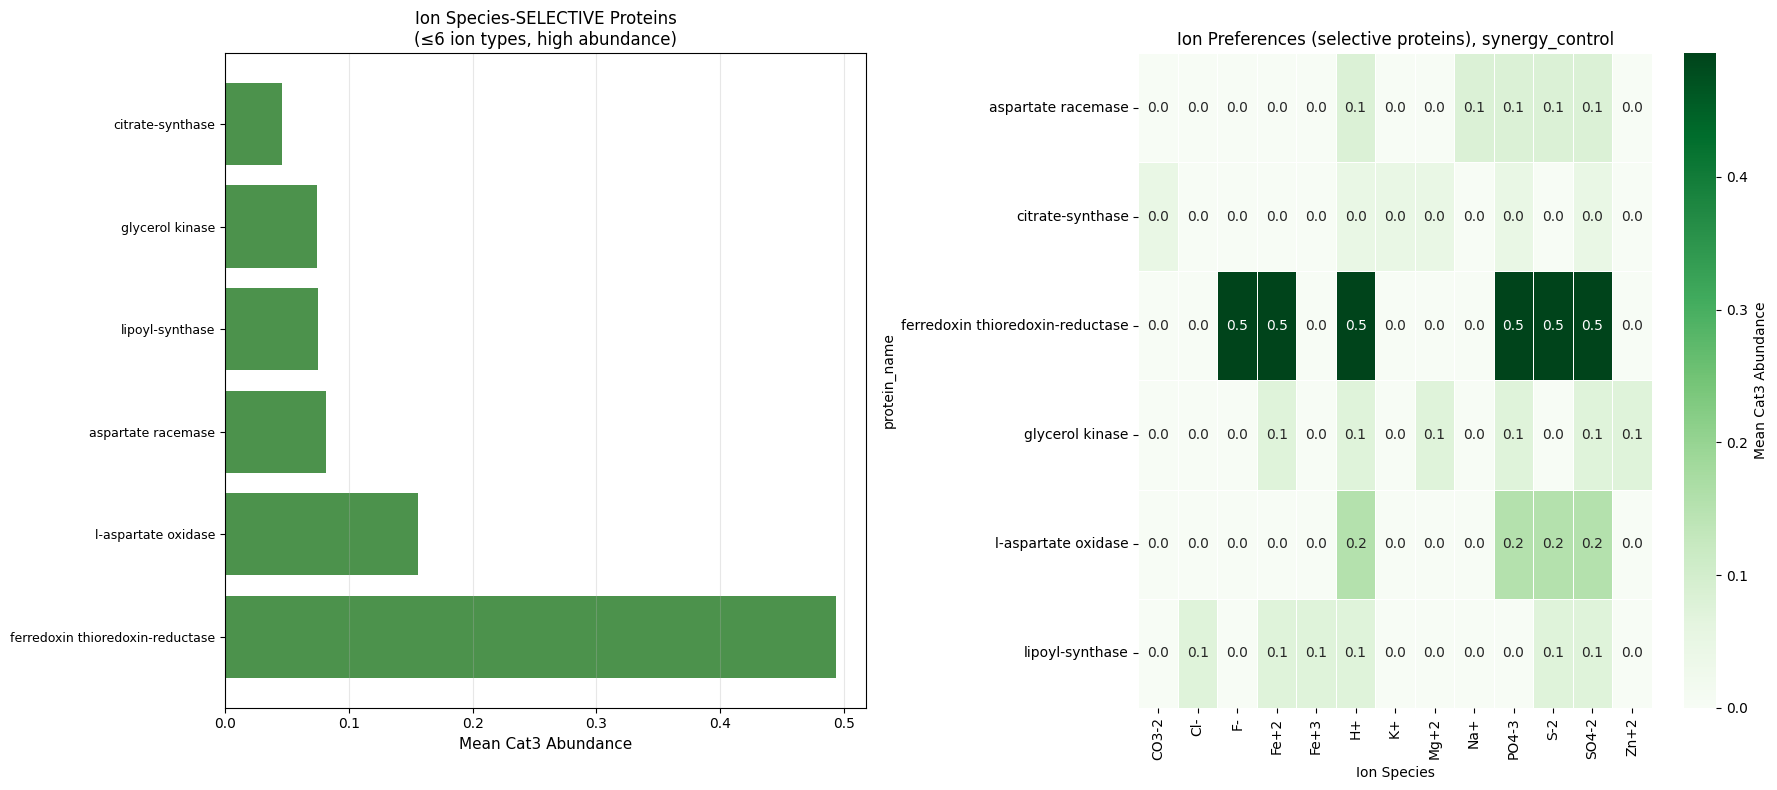

<Figure size 640x480 with 0 Axes>

In [59]:
def plot_metal_protein_specificity(prioritized_markers, name):
    """
    Shows which proteins are SELECTIVE vs PROMISCUOUS for metal ION SPECIES.
    Uses actual ion species from consolidated_metals (Fe+2, Fe+3, SO4-2, etc.)
    Adaptive threshold based on dataset.
    """
    prioritized_markers = prioritized_markers.copy()
    metal_protein_data = []
    
    for _, row in prioritized_markers.iterrows():
        metals_val = row.get('consolidated_metals')
        
        if not isinstance(metals_val, (list, np.ndarray)) or len(metals_val) == 0:
            continue
        
        for ion_species in metals_val:
            if not ion_species or pd.isna(ion_species):
                continue
            
            metal_protein_data.append({
                'protein_name': row.get('protein_name', 'Unknown')[:40],
                'ion_species': str(ion_species).strip(),
                'mean_cat3': row.get('mean_cat3', 0)
            })
    
    if not metal_protein_data:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        ax.text(0.5, 0.5, 'No metal-protein data found', 
                ha='center', va='center', fontsize=12)
        ax.axis('off')
        return fig
    
    df = pd.DataFrame(metal_protein_data)
    
    # Calculate ion species diversity PER PROTEIN
    protein_ion_counts = df.groupby('protein_name')['ion_species'].nunique()
    protein_abundance = df.groupby('protein_name')['mean_cat3'].mean()
    
    # ADAPTIVE THRESHOLD - use 25th percentile of ion diversity
    threshold = int(protein_ion_counts.quantile(0.25))
    threshold = max(threshold, 2)  # At least 2
    
    print(f"\n=== Ion Species-Protein Analysis ===")
    print(f"Total ion-protein associations: {len(metal_protein_data)}")
    print(f"Unique proteins: {df['protein_name'].nunique()}")
    print(f"Ion diversity range: {protein_ion_counts.min()}-{protein_ion_counts.max()}")
    print(f"Adaptive threshold for 'selective': ≤{threshold} ion species")
    
    # Filter: selective proteins (bottom 25% diversity) with high abundance
    selective = protein_ion_counts[protein_ion_counts <= threshold].index
    selective_high = protein_abundance[selective].sort_values(ascending=False).head(20)
    
    if len(selective_high) == 0:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        ax.text(0.5, 0.5, 
                f'No proteins found with ≤{threshold} ion species\n'
                f'(All proteins in this group use {protein_ion_counts.min()}+ ion types)', 
                ha='center', va='center', fontsize=12)
        ax.axis('off')
        return fig
    
    # Create plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Plot 1: Metal-selective proteins
    ax1.barh(range(len(selective_high)), selective_high.values, color='darkgreen', alpha=0.7)
    ax1.set_yticks(range(len(selective_high)))
    ax1.set_yticklabels(selective_high.index, fontsize=9)
    ax1.set_xlabel('Mean Cat3 Abundance', fontsize=11)
    ax1.set_title(f'Ion Species-SELECTIVE Proteins\n(≤{threshold} ion types, high abundance)', fontsize=12)
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Ion preferences
    selective_proteins = selective_high.index
    selective_df = df[df['protein_name'].isin(selective_proteins)]

    if not selective_df.empty:
        ion_by_selective = selective_df.pivot_table(
            index='protein_name', columns='ion_species', 
            values='mean_cat3', aggfunc='mean'
        ).fillna(0)

        if ion_by_selective.shape[0] > 0 and ion_by_selective.shape[1] > 0:
            sns.heatmap(
                ion_by_selective, cmap='Greens', linewidths=0.5, 
                cbar_kws={'label': 'Mean Cat3 Abundance'}, ax=ax2, 
                annot=True, fmt='.1f'
            )
            ax2.set_title(f'Ion Preferences (selective proteins), {name}', fontsize=12)
            ax2.set_xlabel('Ion Species', fontsize=10)
        else:
            ax2.axis('off')
    else:
        ax2.axis('off')

    plt.tight_layout()
    
    print(f"Selective proteins (≤{threshold} species): {len(selective_high)}")
    
    return fig

fig = plot_metal_protein_specificity(synergy_control, "synergy_control")
plt.figure(fig.number)
plt.show()
prot_path = data_visual/"27_metal_protein.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

Biofilm indicator group doesnt really associate its proteins with metals important in corrosion and therefore the group is not longer considered for chosing the most relevant proteins. The other groups will be considered:
__High metal relevance__ group has important association of cysteine desulfurase ↔ H⁺, Fe, MoO₄²⁻, full sulfur series (S²⁻, S₂O₃²⁻, SO₃²⁻, SO₄²⁻) and biotin synthase ↔ H⁺, Cd, Fe²⁺, S²⁻, SO₄²⁻, Zn²⁺. Both to be included sulfur / Fe–S cluster metabolism + metals directly tied to MIC and pH lowering (H⁺).
__Synergy control__ group present large occurence of ferredoxin–thioredoxin reductase ↔ F⁻, Fe²⁺, S²⁻, SO₄²⁻.l aspartate oxidase is associated with H+, S-2, SO4-,
Aspartate racemace S-2, SO4-, Na+, Lipol synthase is associated to Cl-, Fe+2/Fe+3, H+, S-2, SO4-2, glicerol kinase associates to Fe+2, H+, Mg+2, SO4-2, Zn+2. Here it is seen an organic‑acid + nitrogen + Fe/S clusters that matches the previous Iron‑Organic Acid and TOC‑chelation synergies.
__Organic_acid_complexe__ group aldehyde ferredoxin oxidoreductase. Fe+2. Fe+3, H+, Mg+2, S-2, SO4-2, Zn+2, cysteine desulfurase, H+, Fe+2, MoO4-2, sulfur, methylenetetrahydrofolate reductase: Co+2, Mg+2, S glycine oxidase, cd+2, SO4-2. With very clear organic‑acid + C₁ metabolism + sulfur/Fe coupling.
__broad_corrosion__ ferredoxin thioredoxin reductase: F-, Fe+2, H+, S-2, SO4-2,assimilatory sulfite reductase, Fe+2, H+. NO2-, sulfur, L aspartate oxidase H+, S-2, SO4-2,  and n formylglutamate deformylase Fe+2, H+. Mg+2, S-2, SO4-2
__bio_functional__ assimilatory sulfite reductase, Cu+2, Fe+2, H+. NO2-, sulfur. Acyl coa oxidase , H+, Hg+2, K+, Mg+2, Pb+2, SO4-2, L aspartate oxidase H+, S-2, SO4-2, Serine o acetyltransferase Fe-2, H+, Mg+2, S-2, SO4-2

## 5.2 Metal content as a function of protein-genus pair
coverage/presence structure

In [60]:
def analyze_and_plot_metals(df, name, metals_col="consolidated_metals", index_cols=["Genus", "protein_name"],
                            abundance_col="mean_cat3",top_proteins=20, figsize=(18, 8)):
    """
    explode metals, focus on SELECTIVE proteins (low ion diversity, high abundance),
    and visualize with abundance-weighted heatmap + protein ranking.
    """
    
    import ast
    import re
    
    # Helper: ensure list
    def _ensure_list(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if pd.isna(x):
            return []
        if isinstance(x, list):
            return x
        if isinstance(x, (set, tuple)):
            return list(x)
        s = str(x).strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                return list(ast.literal_eval(s))
            except:
                pass
        parts = [p.strip() for p in re.split(r",\s*", s) if p.strip()]
        return parts
    
    # 1. Explode metals and compute per-protein stats
    df_work = df.copy()
    df_work[metals_col] = df_work[metals_col].apply(_ensure_list)
    df_exploded = df_work.explode(metals_col, ignore_index=True)
    df_exploded['metal'] = df_exploded[metals_col].apply(lambda m: str(m).strip() if m and not pd.isna(m) else "")
    df_exploded = df_exploded[df_exploded['metal'] != ""].reset_index(drop=True)
    
    # Compute protein-level stats
    df_exploded["_index_label"] = df_exploded[index_cols].astype(str).agg(" - ".join, axis=1)
    protein_stats = df_exploded.groupby("_index_label").agg({
        'metal': 'nunique',  # Ion diversity
        abundance_col: 'mean'  # Abundance
    }).rename(columns={'metal': 'ion_diversity'})
    
    # ADAPTIVE THRESHOLD: bottom 25% ion diversity
    threshold = int(protein_stats['ion_diversity'].quantile(0.25))
    threshold = max(threshold, 2)
    
    # Filter: selective proteins (low diversity) with high abundance
    selective = protein_stats[
        (protein_stats['ion_diversity'] <= threshold) &
        (protein_stats[abundance_col] > 0)
    ].sort_values(abundance_col, ascending=False).head(top_proteins)
    
    print(f"\n=== Improved Ion Species-Protein Analysis ({name}) ===")
    print(f"Adaptive threshold for selective: ≤{threshold} ion species")
    print(f"Showing top {len(selective)} selective proteins by {abundance_col}")
    
    if len(selective) == 0:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        ax.text(0.5, 0.5, f'No selective proteins (≤{threshold} ions) found', 
                ha='center', va='center', fontsize=12)
        ax.axis('off')
        return fig
    
    # 2. Create abundance-weighted pivot for selective proteins ONLY
    selective_labels = selective.index
    selective_df = df_exploded[df_exploded["_index_label"].isin(selective_labels)]
    abundance_pivot = selective_df.pivot_table(
        index="_index_label", columns="metal", 
        values=abundance_col, aggfunc='mean', fill_value=0
    ).loc[selective.index]  # Ensure sorted by abundance
    
    # Sort columns by total abundance (most relevant metals first)
    col_sums = abundance_pivot.sum(axis=0).sort_values(ascending=False)
    abundance_pivot = abundance_pivot.loc[:, col_sums.index]
    
    # 3. Create improved plots: barh (importance) + abundance heatmap
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Selective proteins by abundance (like first function)
    ax1.barh(range(len(selective)), selective[abundance_col].values, 
             color='darkgreen', alpha=0.7)
    ax1.set_yticks(range(len(selective)))
    ax1.set_yticklabels(selective.index.str[:40], fontsize=9)  # Truncate labels
    ax1.set_xlabel(f'Mean {abundance_col}', fontsize=11)
    ax1.set_title(f'Selective Proteins\n(≤{threshold} ion types, top {top_proteins})', fontsize=12)
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Abundance heatmap for SAME proteins (continuous, not binary)
    if abundance_pivot.shape[0] > 0 and abundance_pivot.shape[1] > 0:
        sns.heatmap(
            abundance_pivot, cmap='Greens', linewidths=0.5, 
            cbar_kws={'label': f'Mean {abundance_col}'}, ax=ax2, 
            annot=True, fmt='.1f',
            vmin=0, vmax=abundance_pivot.values.max()  # Scale to data range
        )
        ax2.set_title(f'Ion Preferences (Abundance-weighted)\n{name}', fontsize=12)
        ax2.set_xlabel('Ion Species', fontsize=10)
        ax2.set_ylabel('Protein', fontsize=10)
    else:
        ax2.axis('off')
    
    plt.tight_layout()
    return fig



=== Improved Ion Species-Protein Analysis (bio_functional) ===
Adaptive threshold for selective: ≤6 ion species
Showing top 18 selective proteins by mean_cat3


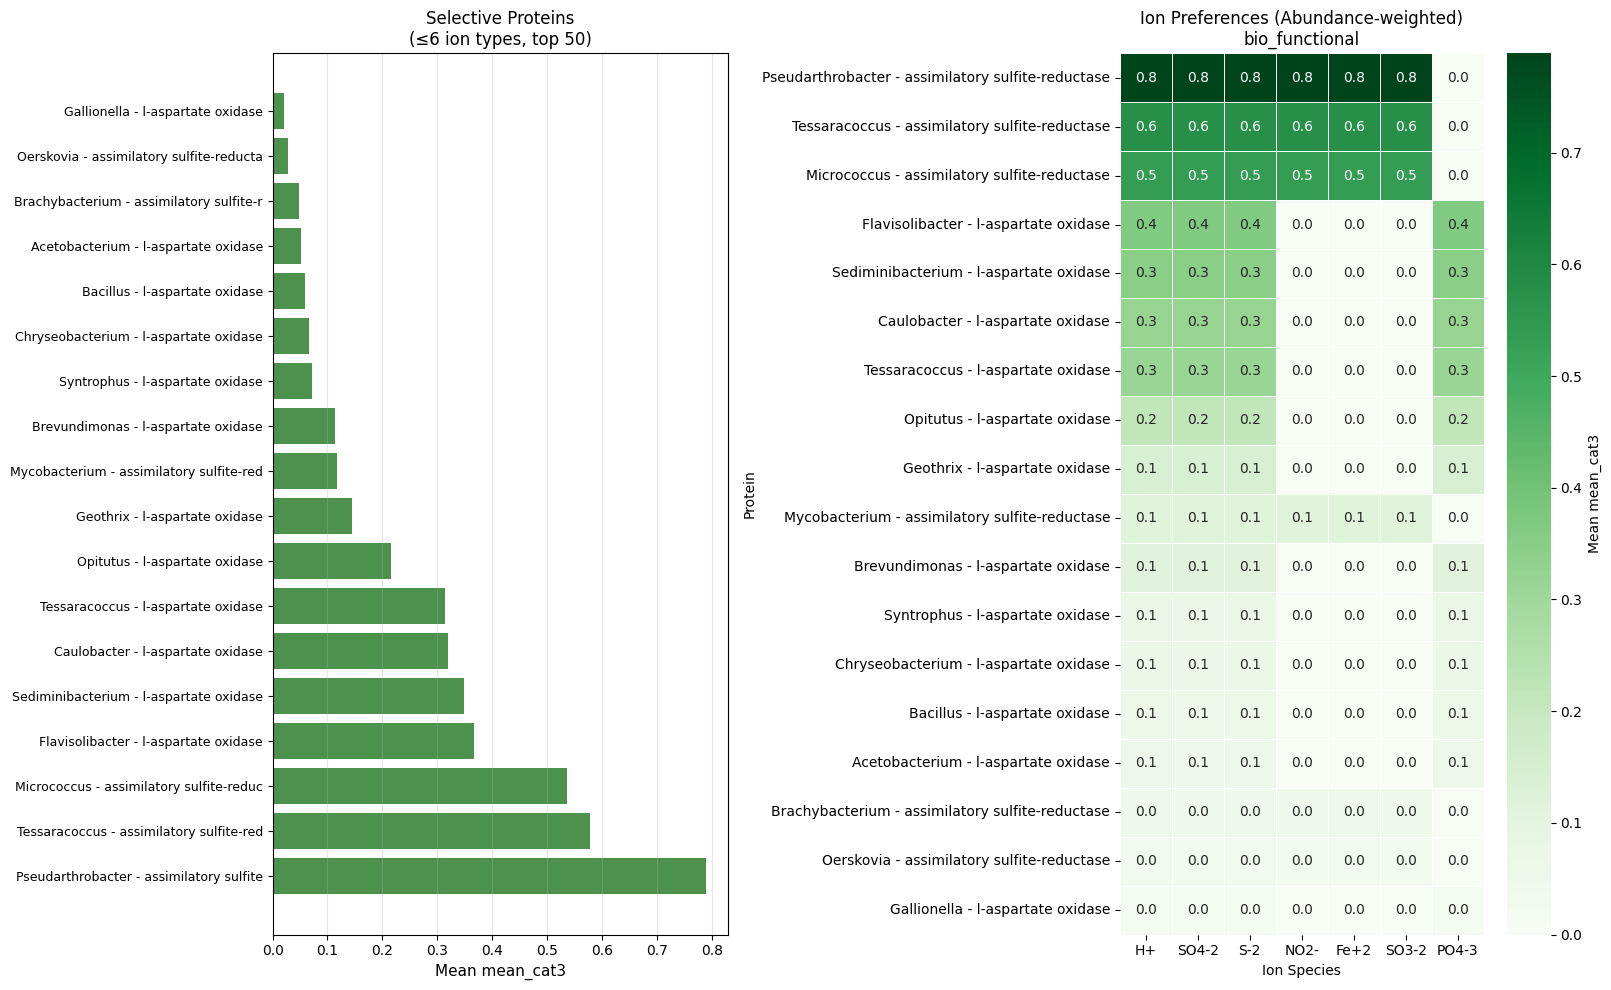

<Figure size 640x480 with 0 Axes>

In [61]:
# Use the functions without any dashboard
fig = analyze_and_plot_metals(high_biological_relevance,'bio_functional', metals_col="consolidated_metals", index_cols=["Genus", "protein_name"], top_proteins=50, figsize=(16, 10))
plt.show()
prot_path = data_visual/"27_prot-metal.png"
plt.savefig(prot_path, dpi=300, bbox_inches='tight')

The results of associating the system failure category with the protein being expressed shows L-aspartate oxidase that could participates in acid production and the formation of hydrogen peroxide, depending on the electron acceptor in the reaction. If oxigen is in the scenario (early colonization) the production of H2O2 is facilitated, with oxide production (passive protective layers). If anaerobic conditions oxidative deamination gives succinate as product and further organic acids, which is apparently what is happening on this systems since one of the primary pathways seen previously for specialised groups is the organic acid pathway. The association with metals show As, H2, Fe which are not involved on the functionality but could be concommitant on other processes, if for instance the acid production induce the removal of Fe on these systems. The following major Protein is the Aminodeoxyfutolosine syntetase, which catalise the reduction of protons to H2 in a reductive process, to mantain Fe-S clusters. Then it is the 2 phosphosulfolactate phosphatase all protein major drivers of corrosion apparently on our systems. The co-occurrence of As, Fe, and H2 indicates metal mobilization and hydrogen production as outcomes of metabolic activity, consistent with acid-accelerated corrosion mechanisms.

## 5.3 List of selective proteins for target metals
List of selected proteins and the associated target metals

In [ ]:
def list_metal_protein_specificity(markers, name, corrosive_metals=None, top_n=20):
    """
    parameter: markers with column consolidated metals as a list ex: [Cl-, Fe+2, H+, Mg+2, NO3-, PO4-3, SO4-2, S-2] muss be exploded and select only target
            target_metals =corrosive_metals= list of ions to consider as corrosive
    Returns LIST of selective proteins for target metals only.
    """
    markers = markers.copy()
    # Use all rows if top_n is None, otherwise take top N by score
    if top_n is not None:
        top_markers = markers.sort_values('combined_score', ascending=False).head(top_n)
    else:
        top_markers = markers.sort_values('combined_score', ascending=False)
        
    if corrosive_metals is None:
        corrosive_metals = ['Fe+2', 'Fe+3', 'Zn+2', 'Cu+', 'Cu+2', 'Ni+2', 'CrO4-2', 'MoO4-2', 'S-2', 'SO4-2']
        
    # Explode like the plot function does
    exploded = top_markers.explode('consolidated_metals')
    exploded = exploded[exploded['consolidated_metals'].isin(corrosive_metals)]
    
    # Group back per protein
    grouped = exploded.groupby(['protein_name', 'Genus']).agg(
        corrosive_ions=('consolidated_metals', list),
        n_ci=('consolidated_metals', 'count'),
        norm_abund=('norm_abund_contri', 'first'),
        combined_score=('combined_score', 'first')
    ).reset_index()
    
    # Merge back with top_markers to keep proteins with no matching metals
    result = top_markers[['protein_name', 'Genus', 'norm_abund_contri', 'combined_score']].merge(
        grouped, on=['protein_name', 'Genus'], how='left'
    )
    result['corrosive_ions'] = result['corrosive_ions'].apply(lambda x: x if isinstance(x, list) else [])
    result['n_ci'] = result['n_ci'].fillna(0).astype(int)
    result = result.rename(columns={'norm_abund_contri': 'norm_abund'})
    result['protein_name'] = result['protein_name'].str[:40]
    df = result[['protein_name', 'Genus', 'corrosive_ions', 'n_ci', 'norm_abund_contri', 'combined_score']]
    
    return df

In [84]:
def list_metal_protein_specificity(markers, name, corrosive_metals=None, top_n=20):
    markers = markers.copy()
    
    if top_n is not None:
        top_markers = markers.sort_values('combined_score', ascending=False).head(top_n)
    else:
        top_markers = markers.sort_values('combined_score', ascending=False)
        
    if corrosive_metals is None:
        corrosive_metals = ['Fe+2', 'Fe+3', 'Zn+2', 'Cu+', 'Cu+2', 'Ni+2', 'CrO4-2', 'MoO4-2', 'S-2', 'SO4-2']
    
    metal_protein_data = []
    for _, row in top_markers.iterrows():
        metals_val = row['consolidated_metals']
        matching_metals = [ion for ion in metals_val if ion in corrosive_metals]
        
        metal_protein_data.append({
            'protein_name': row['protein_name'][:40],
            'Genus': row['Genus'],
            'corrosive_ions': matching_metals,
            'n_ci': len(matching_metals),
            'norm_abund_contri': row['norm_abund_contri'],
            'combined_score': row['combined_score']
        })
    
    return pd.DataFrame(metal_protein_data)

In [85]:
df = list_metal_protein_specificity(high_metals_relevance, high_metals_relevance, top_n=20)

In [86]:
df

,protein_name,Genus,corrosive_ions,n_ci,norm_abund_contri,combined_score
0,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,1.000000,1.432637
1,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,0.229361,1.432637
2,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,0.900929,1.432637
3,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,0.102167,1.432637
4,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,0.040000,1.432637
5,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,0.333189,1.432637
6,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,0.072326,1.432637
7,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,0.961233,1.432637
8,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,0.899776,1.432637
9,sulfite-dehydrogenase,Dechloromonas,"[Fe+2, MoO4-2, SO4-2, S-2, Zn+2]",5,0.532468,1.432637


In [80]:
high_metals_relevance.columns

Index(['Sites', 'idx', 'Genus', 'protein_name', 'mean_cat1', 'mean_cat2',
       'mean_cat3', 'descriptive_pattern', 'pattern', 'fold_change_2vs1',
       'log2fc_2vs1', 'fold_change_3vs2', 'log2fc_3vs2', 'fold_change_3vs1',
       'log2fc_3vs1', 'max_abs_log2fc', 'real_score', 'p_value',
       'significance_score', 'pathways', 'reactions', 'enzyme_class',
       'functional_sub', 'functional_child', 'synergy_child_list',
       'synergy_sub_list', 'synergy_description', 'consolidated_metals',
       'hierarchy', 'mechanisms_sub', 'mechanisms_child', 'operational_sub',
       'operational_combi', 'overall_functional_score', 'overall_metal_score',
       'overall_synergy_score', 'corrosion_relevance_score',
       'abundance_biofilm', 'pathway_classification', 'universal_pathways',
       'niche_specific_pathways', 'combined_score', 'p_value_score',
       'frequency_score', 'database_combined_score', 'niche_specific_score',
       'synergy_combi', 'synergy_combi_score', 'fc_score', 'e

In [ ]:
corrosion_critical_Me = list_metal_protein_specificity(high_metals_relevance, high_metals_relevance, top_n = 50)

KeyError: "Column(s) ['norm_abun_contri'] do not exist"

In [71]:
print(type(corrosion_critical['consolidated_metals'].iloc[0]))
print(corrosion_critical['consolidated_metals'].iloc[0])

<class 'numpy.ndarray'>
['Cl-' 'Fe+2' 'H+' 'Mg+2' 'NO3-' 'PO4-3' 'SO4-2' 'S-2']


# 6. Network Analysis
## 6.1 Network Analysis of Functional metabolism

In [ ]:
def create_static_network(
    df, name, center_category='functional_combi', top_n=100,
    gp_threshold=0.0, pf_threshold=0.0,
    normalize_divisor=None,
    show_func_labels="topk",
    func_label_topk=25,
    func_label_bbox=False,
    min_func_len=3,
    node_label_config=None,
    print_protein_info=True
):
    """
    Create static network visualization with integrated protein information report.
    
    Combines:
    - Excellent star/hub network visualization (Image 1 quality)
    - Detailed protein information text output (Image 2 quality)
    
    Args:
        df: DataFrame containing marker data
        name: Name for the network plot
        center_category: 'functional_combi', 'mechanisms_combi', 'operational_combi', 
                        'synergy_combi', 'consolidated_metals'
        top_n: Number of top markers (100+ recommended for density)
        gp_threshold: Genus-protein edge threshold
        pf_threshold: Protein-category edge threshold
        normalize_divisor: Score normalization divisor
        show_func_labels: "topk", "all", or "none"
        func_label_topk: Number of top category labels to show
        func_label_bbox: Add background box to category labels
        min_func_len: Minimum length for category labels
        node_label_config: {'genus': bool, 'protein': bool, 'category': bool}
        print_protein_info: If True, print detailed protein information report
    
    Returns:
        G: NetworkX graph object
    """
    if node_label_config is None:
        node_label_config = {'genus': True, 'protein': True, 'category': True}

    if 'Category' not in df.columns:
        df = df.copy()
        df['Category'] = df['Sites'].map(category_dict)

    required = ['Genus', 'protein_name', 'combined_score', center_category]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"Missing columns: {missing}")
        return None

    top_markers = df.sort_values('combined_score', ascending=False).head(top_n).copy()

    if normalize_divisor is None:
        cs = top_markers['combined_score'].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        p90 = np.percentile(cs, 90) if len(cs) > 0 else 1.0
        normalize_divisor = p90 if p90 > 0 else (cs.max() if cs.max() > 0 else 1.0)

    def norm_score(val):
        try:
            v = float(val)
        except (ValueError, TypeError):
            v = 0.0
        return float(np.clip(max(v, 0.0) / float(normalize_divisor), 0.0, 1.0))

    def flatten_center_category(val):
        """Flatten center_category respecting data types: dict, list, or string."""
        out = []
        if val is None or (isinstance(val, float) and pd.isna(val)):
            return out
        
        if isinstance(val, dict):
            for k, v in val.items():
                if k and str(k).strip() and str(k).strip() != '<NA>':
                    out.append(str(k).strip())
                if isinstance(v, (list, tuple, set)):
                    out.extend([str(x).strip() for x in v if x and str(x).strip() and str(x).strip() != '<NA>'])
                elif v and str(v).strip() and str(v).strip() != '<NA>':
                    out.append(str(v).strip())
            return out
        
        if isinstance(val, (list, tuple, set)):
            return [str(x).strip() for x in val if x and str(x).strip() and str(x).strip() != '<NA>']
        
        return [s.strip() for s in str(val).split(';') if s.strip() and s.strip() != '<NA>']

    def clean_values(vals):
        """Remove duplicates and values below min_func_len."""
        seen = set()
        out = []
        for f in vals:
            f2 = str(f).strip()
            if not f2 or len(f2) < min_func_len:
                continue
            if f2 not in seen:
                seen.add(f2)
                out.append(f2)
        return out

    # Build graph
    G = nx.Graph()
    protein_full_names = {}
    protein_to_genera = {}
    protein_to_center_category = {}

    for _, row in top_markers.iterrows():
        genus_raw = row['Genus']
        protein_raw = row['protein_name']
        if pd.isna(genus_raw) or pd.isna(protein_raw):
            continue
        
        genus = str(genus_raw).strip()
        protein = str(protein_raw).strip()
        protein_short = protein[:27] + "..." if len(protein) > 30 else protein

        gid = f"g:{genus}"
        pid = f"p:{protein_short}"

        # Store full protein name for later reporting
        protein_full_names[pid] = protein

        # Add nodes
        if not G.has_node(gid):
            G.add_node(gid, type='genus', label=genus)
        if not G.has_node(pid):
            G.add_node(pid, type='protein', label=protein_short)

        # Track relationships
        if pid not in protein_to_genera:
            protein_to_genera[pid] = []
        protein_to_genera[pid].append(genus)

        # Genus-protein edge
        w = norm_score(row.get('combined_score', 0.0))
        if w >= gp_threshold:
            G.add_edge(gid, pid, weight=w)

        # Center-category edges
        cats = clean_values(flatten_center_category(row.get(center_category)))
        if pid not in protein_to_center_category:
            protein_to_center_category[pid] = []
        protein_to_center_category[pid].extend(cats)

        for c in cats:
            cid = f"c:{c}"
            if not G.has_node(cid):
                G.add_node(cid, type='category', label=c)
            wf = max(0.4, w)
            if wf >= pf_threshold:
                G.add_edge(pid, cid, weight=wf)

    if G.number_of_edges() == 0:
        print(f"Graph has no edges. Try: lower gp_threshold/pf_threshold, or adjust normalize_divisor.")
        return G

    # Community detection
    try:
        partition = community_louvain.best_partition(G)
        nx.set_node_attributes(G, partition, 'community')
    except Exception as e:
        print(f"Community detection skipped: {e}")
        nx.set_node_attributes(G, 0, 'community')

    # Node sizes by degree
    degree_dict = dict(G.degree())
    node_sizes = {}
    for n in G.nodes():
        t = G.nodes[n].get('type')
        base = 900 if t == 'genus' else (650 if t == 'protein' else 500)
        node_sizes[n] = base * (1 + np.log1p(degree_dict.get(n, 0)) / 2)

    # Layout and draw
    plt.figure(figsize=(18, 14))
    pos = nx.spring_layout(G, k=0.6, seed=42, iterations=200)
    edge_weights = [max(1.2, G[u][v].get('weight', 0.5) * 6) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, alpha=0.6, width=edge_weights, edge_color='gray')

    # Node colors
    node_colors_map = {'genus': 'blue', 'protein': 'purple', 'category': 'brown'}
    for t, color in node_colors_map.items():
        nodes = [n for n in G.nodes() if G.nodes[n].get('type') == t]
        if nodes:
            nx.draw_networkx_nodes(
                G, pos, nodelist=nodes,
                node_color=color,
                node_size=[node_sizes[n] for n in nodes],
                alpha=0.9, linewidths=0.5, edgecolors='white'
            )

    # Labels
    labels = {n: G.nodes[n].get('label', n) for n in G.nodes()}
    genus_labels = {n: labels[n] for n in G.nodes() if G.nodes[n].get('type') == 'genus'}
    protein_labels = {n: labels[n] for n in G.nodes() if G.nodes[n].get('type') == 'protein'}
    func_nodes = [n for n in G.nodes() if G.nodes[n].get('type') == 'category']

    if genus_labels and node_label_config.get('genus'):
        nx.draw_networkx_labels(G, pos, labels=genus_labels, font_size=12, font_weight='bold',
                                font_color='black', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1))
    if protein_labels and node_label_config.get('protein'):
        nx.draw_networkx_labels(G, pos, labels=protein_labels, font_size=9, font_color='black')

    # Functional/category labeling
    func_label_set = set()
    if show_func_labels == "all":
        func_label_set = set(func_nodes)
    elif show_func_labels == "topk":
        func_nodes_sorted = sorted(func_nodes, key=lambda n: degree_dict.get(n, 0), reverse=True)[:func_label_topk]
        func_label_set = set(func_nodes_sorted)
    
    if func_label_set and node_label_config.get('category'):
        func_labels = {n: labels[n] for n in func_label_set}
        func_bbox = dict(facecolor='white', alpha=0.35, edgecolor='none', pad=0.6) if func_label_bbox else None
        nx.draw_networkx_labels(G, pos, labels=func_labels, font_size=9, font_color='black', bbox=func_bbox)

    # Legend and title
    plt.plot([0], [0], 'o', color=node_colors_map['genus'], markersize=12, label='Genus')
    plt.plot([0], [0], 'o', color=node_colors_map['protein'], markersize=10, label='Protein')
    plt.plot([0], [0], 'o', color=node_colors_map['category'], markersize=11, label=center_category)
    plt.legend(loc='upper right', frameon=True, fontsize=12)
    plt.title(f"{name} Network of Top {top_n} Corrosion Markers ({center_category})", fontsize=18)
    plt.axis('off')
    plt.tight_layout()
    plt.gca().set_facecolor('white')
    plt.gcf().set_facecolor('white')

    # Debug counts
    gp_edges = sum(1 for u, v in G.edges() if (G.nodes[u]['type'] == 'genus' and G.nodes[v]['type'] == 'protein') or
                                              (G.nodes[v]['type'] == 'genus' and G.nodes[u]['type'] == 'protein'))
    pf_edges = sum(1 for u, v in G.edges() if (G.nodes[u]['type'] == 'protein' and G.nodes[v]['type'] == 'category') or
                                              (G.nodes[v]['type'] == 'protein' and G.nodes[u]['type'] == 'category'))
    print(f"✓ Network created: {G.number_of_nodes()} nodes | genus–protein={gp_edges} | protein–{center_category}={pf_edges} | total edges={G.number_of_edges()}")

    # ============================================================================
    # INTEGRATED PROTEIN INFORMATION REPORT (from create_dynamic_network)
    # ============================================================================
    if print_protein_info:
        print(f"\n{'='*90}")
        print(f"PROTEIN INFORMATION - {name.upper()}")
        print(f"{'='*90}")
        
        # Collect protein connection info
        protein_connections = {}
        for pid, full_name in protein_full_names.items():
            if pid in G:
                connections = degree_dict.get(pid, 0)
                genera = list(set(protein_to_genera.get(pid, [])))  # Unique genera
                categories = list(set(protein_to_center_category.get(pid, [])))  # Unique categories
                protein_connections[pid] = {
                    'full_name': full_name,
                    'connections': connections,
                    'genera': genera,
                    'categories': categories
                }
        
        # Sort by connections (descending)
        sorted_proteins = sorted(protein_connections.items(), 
                               key=lambda x: x[1]['connections'], reverse=True)
        
        # Print protein details
        for pid, info in sorted_proteins:
            print(f"\n{info['full_name']}")
            print(f"  Connections: {info['connections']}")
            print(f"  Expressed by: {', '.join(info['genera'])}")
            if info['categories']:
                cat_label = center_category.replace('_', ' ').title()
                print(f"  {cat_label}: {', '.join(info['categories'][:7])}")
                if len(info['categories']) > 7:
                    print(f"             ... and {len(info['categories']) - 7} more")
        
        print(f"\n{'='*90}")
        print(f"Summary: {len(sorted_proteins)} proteins across {len(set(g for info in protein_connections.values() for g in info['genera']))} genera")
        print(f"{'='*90}\n")

    return G

In [ ]:
# 1. Using functional_combi (dict of {subcategory: [child_terms]})
G1 = create_static_network(
    broad_corrosion, 
    name="core_corrosion",
    center_category='functional_combi',
    top_n=100,
    gp_threshold=0.0,
    pf_threshold=0.0,
    show_func_labels="topk",
    func_label_topk=20
)
# save the image
output_share = data_visual/"28_core__network.png"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

In [ ]:
# 2. Using mechanisms_combi (dict of {subcategory: [child_terms]})
G2 = create_static_network(
    bio_functional,
    name="bio_functional",
    center_category='mechanisms_combi',
    top_n=100,
    show_func_labels="all"
)
# save the image
output_share = data_visual/"29_bio_mechanisms.png"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

In [ ]:

# 3. Using synergy_combi (list of strings)
G3 = create_static_network(
    synergy_control,
    name="synergy_control",
    center_category='synergy_combi',
    top_n=100,
    normalize_divisor=8.0,
    func_label_bbox=True
)
# save the image
output_share = data_visual/"30_synergy"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

In [ ]:
# 4. Using consolidated_metals (list of ions with charge notation)
G4 = create_static_network(
    biofilm_indicators,
    name="biofilm_indicators",
    center_category='mechanisms_sub',
    top_n=50,
    min_func_len=2,  # Allow shorter metal symbols like 'Fe', 'Cu'
    show_func_labels="topk",
    func_label_topk=20
)
output_share = data_visual/"30_biofilm_functional.png"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

In [ ]:
# 5. Using consolidated_metals (list of ions with charge notation)
G4 = create_static_network(
    corrosion_critical,
    name="corrosion_critical",
    center_category= "pathways",
    top_n=100,
    min_func_len=2,  # Allow shorter metal symbols like 'Fe', 'Cu'
    show_func_labels="topk",
    func_label_topk=20
)
output_share = data_visual/"30_core_corrosion"

plt.savefig(output_share, dpi=300, bbox_inches='tight')

|Protein|Function and MIC Relevance|
|--|--|
|Sarcosine Oxidase|Generates the potent oxidizing agent hydrogen peroxide (H2​O2​), link to oxidative stress which can directly weaken the passive oxide layer on metal surfaces.|
|NADH Dehydrogenase|Functions in an alternative, non-proton-pumping electron transport chain, potentially supporting bacterial survival in low-oxygen, high-stress biofilm environments characteristic of MIC sites.|
|Assimilatory Sulfite Reductase|Consumes sulfite while producing both the essential metabolite sulfide and protons (H+), contributing to localized acidification and corrosive sulfide formation within the biofilm.|
|Thiosulfate Dehydrogenase|Facilitates the use of thiosulfate as an alternative electron acceptor in terminal respiration, supporting energy generation and colonization in late-stage, oxygen-depleted niches.|
|Formate C-Acetyltransferase|also known as Pyruvate formate-lyase, is central to mixed-acid fermentation in glucose metabolism, it generates formate, an organic acid and corrosive agent, linking central carbon metabolism to material degradation.|
|Alcohol Dehydrogenase|Generates corrosive aldehydes and ketones from alcohols, particularly important in later biofilm stages where fermentation products and other complex organics accumulate.|
|Aconitate Hydratase|A key enzyme in the TCA cycle and iron metabolism(Iron-sulfur cluster binding), its iron-dependent function links the breakdown of corrosive citrate with the cell's essential iron-regulation and growth processes.|
1.  MetaCyc. (2025). Sarcosine oxidase
2. NCBI/UniProt. (2025). NADH Dehydrogenase
3. BioCyc. (2025). Assimilatory Sulfite Reductase (ASR)
4. NCBI/GenBank. (2025). Thiosulfate dehydrogenase (TsdA)
5.  MetaCyc. (2025). Formate C-Acetyltransferase
6. BioCyc. (2025). Alcohol dehydrogenase
7.  UniProt/SwissProt. (2025). Aconitate Hydratase (Acn)


## 6.2 Network Dashboard protein-Genus Pairs

In [ ]:
def create_dynamic_network(df, name, top_n=30, threshold=0.5, center_category='mechanisms_sub',
                                                        node_label_config=None):
    """
    Creates a dynamic network visualization where the center category can be changed.
    
    Args:  df: DataFrame containing marker data, name: Name for the network plot
        top_n: Number of top markers to include, threshold: Edge weight threshold (0.0-1.0)
        center_category: Column name for the category to show distributed around perimeter  ('mechanisms_sub', 'functional_sub', 
                         'pathways', 'synergies', etc.)
        node_label_config: Dict specifying which node types to label: {'genus': True, 'protein': True, 'category': True}
    
    Returns:  G: NetworkX graph object
    """
    
    # Default label configuration
    if node_label_config is None:
        node_label_config = {'genus': True,
            'protein': True,
            'category': True
        }
    
    # Dynamic color scheme based on category type
    color_schemes = {
        'mechanisms_sub': {'genus': '#1976D2',      # Deep blue
            'protein': '#388E3C',    # Forest green  
            'category': '#D32F2F'    # Deep red
        },
        'functional_sub': {'genus': '#303F9F',      # Indigo
            'protein': '#689F38',    # Light green
            'category': '#F57C00'    # Orange
        },
        'pathways': {'genus': '#0288D1',      # Light blue
            'protein': '#7B1FA2',    # Purple
            'category': '#C2185B'    # Pink
        },
        'synergies': {'genus': '#00796B',      # Teal
            'protein': '#5D4037',    # Brown
            'category': '#FFA000'    # Amber
        }
    }
    
    # Use appropriate color scheme or default
    node_colors = color_schemes.get(center_category, color_schemes['mechanisms_sub'])
    
    # Check required columns
    required_cols = ['Genus', 'protein_name', 'combined_score', center_category]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if 'pathways' in df.columns:
        df['pathways'] = df['pathways'].apply(rename_pathway_single)
    # Create network
    G = nx.Graph()
    
    # Get top markers the top markers in each df already sorted intop
    top_markers = df.copy()
    if "Category" not in top_markers:
        top_markers["Category"] = top_markers["Sites"].map(category_dict)
    
    # Store full protein names for reference
    protein_full_names = {}
    protein_to_genera = {}  # Track which genera connect to which proteins
    
    for _, row in top_markers.iterrows():
        genus = str(row['Genus'])
        protein = str(row['protein_name'])
        
        if pd.isna(genus) or pd.isna(protein):
            continue
        
        # Create unique protein identifier to avoid merging different proteins
        protein_id = protein # f"{protein}_{genus[:3]}"  # Add genus prefix for uniqueness
        
        # Store full name
        protein_full_names[protein_id] = protein
        
        # Add nodes
        if not G.has_node(genus):
            G.add_node(genus, type='genus', label=genus)
        
        if not G.has_node(protein_id):
            G.add_node(protein_id, type='protein', 
                      full_name=protein,
                      label=protein if len(protein) <= 30 else protein[:27] + "...")
        
        # Track genus-protein relationships
        if protein_id not in protein_to_genera:
            protein_to_genera[protein_id] = []
        protein_to_genera[protein_id].append(genus)
        
        # Add edge with weight
        score = float(row.get('combined_score', 1.0)) if not pd.isna(row.get('combined_score')) else 1.0
        norm_score = min(score / 50, 1.0)  # Normalize score
        G.add_edge(genus, protein_id, weight=norm_score)
        
        # Add category nodes and edges
        category_data = row.get(center_category, '')
        if isinstance(category_data, str) and category_data:
            categories = [cat.strip() for cat in category_data.split(';') if cat.strip()]
            for cat in categories:
                if not G.has_node(cat):
                    G.add_node(cat, type='category', label=cat)
                G.add_edge(protein_id, cat, weight=0.8)
    
    # Calculate layout with categories DISTRIBUTED around perimeter
    category_nodes = [n for n in G.nodes() if G.nodes[n].get('type') == 'category']
    n_categories = len(category_nodes)
    
    # Create custom layout
    pos = {}
    
    # Place categories around the perimeter (maximally separated)
    if n_categories > 0:
        # Use larger radius to push categories to perimeter
        radius = 2.5  # Increased radius for maximum separation
        angles = np.linspace(0, 2 * np.pi, n_categories, endpoint=False)
        
        for i, cat in enumerate(category_nodes):
            pos[cat] = (radius * np.cos(angles[i]), radius * np.sin(angles[i]))
    
    # Use spring layout for other nodes with fixed category positions
    # Increased k parameter and iterations for better separation
    if category_nodes:
        other_pos = nx.spring_layout(G, k=2.0, pos=pos, fixed=category_nodes, 
                                    seed=42, iterations=150)
        pos.update(other_pos)
    else:
        pos = nx.spring_layout(G, k=1.5, seed=42, iterations=150)
    
    # Create figure with larger size to accommodate distributed layout
    plt.figure(figsize=(30, 20))
    
    # Draw edges with varying width
    edge_weights = [G[u][v]['weight'] * 2 for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, alpha=0.3, width=edge_weights, edge_color='gray')
    
    # Calculate node sizes based on degree
    degree_dict = dict(G.degree())
    node_sizes = {}
    for node in G.nodes():
        node_type = G.nodes[node].get('type')
        base_size = {'genus': 800, 'protein': 600, 'category': 1200}.get(node_type, 500)  # Larger category nodes
        node_sizes[node] = base_size * (1 + np.log1p(degree_dict[node]) / 3)
    
    # Draw nodes by type
    for node_type in ['genus', 'protein', 'category']:
        nodes = [n for n in G.nodes() if G.nodes[n].get('type') == node_type]
        if nodes:
            nx.draw_networkx_nodes(G, pos, 
                                  nodelist=nodes,
                                  node_color=node_colors[node_type],
                                  node_size=[node_sizes[n] for n in nodes],
                                  alpha=0.85,
                                  edgecolors='black',
                                  linewidths=1.5)
    
    # Draw labels based on configuration
    labels = {}
    font_configs = {
        'genus': {'size': 11, 'weight': 'bold', 'bbox': dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)},
        'protein': {'size': 9, 'weight': 'normal', 'bbox': dict(facecolor='lightgray', alpha=0.7, edgecolor='none', pad=0.5)},
        'category': {'size': 13, 'weight': 'bold', 'bbox': dict(facecolor='yellow', alpha=0.9, edgecolor='black', pad=2)}  # More prominent labels
    }
    
    for node_type, should_label in node_label_config.items():
        if should_label:
            nodes = [n for n in G.nodes() if G.nodes[n].get('type') == node_type]
            node_labels = {n: G.nodes[n].get('label', n) for n in nodes}
            
            if node_labels:
                font_config = font_configs.get(node_type, {})
                nx.draw_networkx_labels(G, pos, 
                                       labels=node_labels,
                                       font_size=font_config.get('size', 10),
                                       font_weight=font_config.get('weight', 'normal'),
                                       bbox=font_config.get('bbox', None))
        
    for node_type, color in node_colors.items():
        if node_counts[node_type] > 0:
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                            markerfacecolor=color, markersize=12,
                                            label=legend_labels[node_type],
                                            markeredgecolor='black', markeredgewidth=1.5))
    
    plt.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=True)
    
    # Title with category info
    plt.title(f"{name} Network: Top {top_n} Markers - {center_category.replace('_', ' ').title()} Distributed", 
              fontsize=18, fontweight='bold', pad=20)
    
    plt.axis('off')
    plt.tight_layout()
    
    # Print protein information if not all are labeled
    if not node_label_config.get('protein', True):
        print(f"\n{'='*80}")
        print(f"PROTEIN INFORMATION (Full Names)")
        print(f"{'='*80}")
        
        # Sort proteins by number of connections
        protein_connections = {}
        for protein_id, full_name in protein_full_names.items():
            if protein_id in G:
                connections = degree_dict.get(protein_id, 0)
                genera = protein_to_genera.get(protein_id, [])
                protein_connections[protein_id] = (full_name, connections, genera)
        
        # Sort by number of connections
        sorted_proteins = sorted(protein_connections.items(), 
                               key=lambda x: x[1][1], reverse=True)
        
        for protein_id, (full_name, connections, genera) in sorted_proteins:
            print(f"\n{full_name}")
            print(f"  Connections: {connections}")
            print(f"  Expressed by: {', '.join(genera)}")
            
            # Get connected categories
            connected_cats = [n for n in G.neighbors(protein_id) 
                            if G.nodes[n].get('type') == 'category']
            if connected_cats:
                print(f"  {center_category.replace('_', ' ').title()}: {', '.join(connected_cats)}")
    
    print(f"\nNetwork statistics:")
    print(f"  Total nodes: {len(G.nodes())}")
    print(f"  Total edges: {len(G.edges())}")
    print(f"  Network density: {nx.density(G):.3f}")
    
    return G

def create_network_plotly(df, center_category, top_n=30):
    """Convert matplotlib network to Plotly for web display"""
    
    # Check required columns first
    required_cols = ['Genus', 'protein_name', 'combined_score', center_category]
 
    # Create the network 
    G = nx.Graph()
    top_markers = df.sort_values('combined_score', ascending=False).head(top_n)
    
    for _, row in top_markers.iterrows():
        genus = str(row['Genus'])
        protein = str(row['protein_name'])
        
        if pd.isna(genus) or pd.isna(protein):
            continue
        
        protein_id = protein # f"{protein}_{genus[:3]}"
        
        # Add nodes 
        if not G.has_node(genus):
            G.add_node(genus, type='genus', label=genus)
        
        if not G.has_node(protein_id):
            G.add_node(protein_id, type='protein', 
                      full_name=protein,
                      label=protein if len(protein) <= 30 else protein[:27] + "...")
        
        # Add edge with weight
        score = float(row.get('combined_score', 1.0)) if not pd.isna(row.get('combined_score')) else 1.0
        norm_score = min(score / 50, 1.0)
        G.add_edge(genus, protein_id, weight=norm_score)
        
        # Add category nodes and edges 
        category_data = row.get(center_category, '')
        if isinstance(category_data, str) and category_data:
            categories = [cat.strip() for cat in category_data.split(';') if cat.strip()]
            for cat in categories:
                if not G.has_node(cat):
                    G.add_node(cat, type='category', label=cat)
                G.add_edge(protein_id, cat, weight=0.8)
    
    if len(G.nodes()) == 0:
        return None, "No valid data found to create network"
 
    category_nodes = [n for n in G.nodes() if G.nodes[n].get('type') == 'category']
    n_categories = len(category_nodes)
    pos = {}
    
    # Place categories around perimeter 
    if n_categories > 0:
        radius = 2.5
        angles = np.linspace(0, 2 * np.pi, n_categories, endpoint=False)
        for i, cat in enumerate(category_nodes):
            pos[cat] = (radius * np.cos(angles[i]), radius * np.sin(angles[i]))
    
    # Spring layout for other nodes 
    if category_nodes:
        other_pos = nx.spring_layout(G, k=2.5, pos=pos, fixed=category_nodes, 
                                    seed=42, iterations=500)
        pos.update(other_pos)
    else:
        pos = nx.spring_layout(G, k=1.5, seed=42, iterations=150)
    
    # Convert to Plotly
    edge_x, edge_y = [], []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
    
    # Use  color scheme
    color_schemes = { # combis are each one dictionary, pathways is only one str.
        'mechanisms_combi': {'genus': '#1976D2', 'protein': '#388E3C', 'category': '#D32F2F'},
        'functional_combi': {'genus': '#303F9F', 'protein': '#689F38', 'category': '#F57C00'},
        'pathways': {'genus': '#0288D1', 'protein': '#7B1FA2', 'category': '#C2185B'},
    }
    node_colors = color_schemes.get(center_category, color_schemes['corrosion_mechanisms'])
    
    fig = go.Figure()
    
    # Add edges
    fig.add_trace(go.Scatter(x=edge_x, y=edge_y, line=dict(width=1, color='gray'),
                            hoverinfo='none', mode='lines', showlegend=False))
    
    # Add nodes by type 
    for node_type in ['genus', 'protein', 'category']:
        nodes = [n for n in G.nodes() if G.nodes[n].get('type') == node_type]
        if nodes:
            node_x = [pos[node][0] for node in nodes]
            node_y = [pos[node][1] for node in nodes]
            node_text = [G.nodes[node].get('label', node) for node in nodes]
            
            size = {'genus': 20, 'protein': 20, 'category': 25}[node_type]
            
            fig.add_trace(go.Scatter(
                x=node_x, y=node_y, 
                mode='markers+text', 
                text=node_text,
                textposition="top center", 
                hovertemplate='<b>%{text}</b><br>Type: ' + node_type + '<br>Connections: %{customdata}<extra></extra>',
                customdata=[len(list(G.neighbors(node))) for node in nodes],  # Connection count
                marker=dict(size=size, color=node_colors[node_type], 
                        line=dict(width=2, color='white')),
                name=f'{node_type.title()} ({len(nodes)})',
                textfont=dict(size=14, color='black')
            ))
    
    fig.update_layout(
        title=dict(text=f"Network: {center_category.replace('_', ' ').title()} Distributed", 
                   font=dict(size=16)),
        showlegend=True, hovermode='closest',  dragmode='pan',
        margin=dict(b=20,l=5,r=5,t=60),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='#f8f9fa', height=900
    )
    
    stats = {'nodes': len(G.nodes()), 'edges': len(G.edges()), 
             'categories': len(category_nodes), 'density': f"{nx.density(G):.3f}"}
    
    return fig, stats

# Initialize the Dash app
app = dash.Dash(__name__)

categories = [
    {'label': 'Enzyme Class', 'value': 'enzyme_class'},
    {'label': 'Pathways', 'value': 'pathways'},
    {'label': 'Hierarchy', 'value': 'hierarchy'},
    {'label': 'Metals Consolidated', 'value': 'consolidated_metals'},
    {'label': 'Functional Categories', 'value': 'functional_categories'},
    {'label': 'Corrosion Synergies', 'value': 'corrosion_synergies'},
    {'label': 'Organic Processes', 'value': 'organic_processes'},
    {'label': 'Corrosion Mechanisms', 'value': 'corrosion_mechanisms'},
    {'label': 'Niche Specific Pathways', 'value': 'niche_specific_pathways'},
    {'label': 'Functional Categories Present', 'value': 'functional_categories_present'}
]

app.layout = html.Div([
    html.Div([
        # Sidebar (left column)
        html.Div([
            html.H2("Network Dashboard", style={
                'color': 'white',
                'fontSize': '1.3em',
                'marginBottom': '24px',
                'marginTop': '0',
                'textAlign': 'left'
            }),
            html.Div([
                html.Strong("Legend", style={'color': 'white'}),
                html.Ul([
                    html.Li("Gene", style={'color': 'lightblue'}),
                    html.Li("Protein", style={'color': 'orange'}),
                    html.Li("Category", style={'color': 'darkgreen'}),
                ], style={'listStyleType': 'circle', 'marginLeft': '18px', 'color': 'white', 'marginBottom': '18px'})
            ], style={'marginBottom': '18px'}),
            html.Div(id='network-stats', style={
                'backgroundColor': 'rgba(0,0,0,0.7)',
                'padding': '14px',  'borderRadius': '8px',  'color': 'white',  'marginBottom': '24px'
            }),
            html.Label("Select Category:", style={'color': 'white', 'fontWeight': 'bold',  'marginBottom': '6px'
            }),
            dcc.Dropdown(
                id='category-dropdown',     options=categories,   value='functional_categories',   style={'marginBottom': '24px'}
            ),
        ], style={ 'width': '260px', 'background': 'rgba(255,255,255,0.08)',  'padding': '32px 18px', 'borderRadius': '15px', 'minHeight': '90vh',
            'display': 'flex', 'flexDirection': 'column',  'justifyContent': 'flex-start'
        }),

        # Main plot (right column)
        html.Div([
            dcc.Graph(id='network-plot', style={'height': '80vh', 'width': '100%'})
        ], style={ 'flexGrow': 1,   'padding': '24px'
        })
    ], style={
        'display': 'flex', 'flexDirection': 'row',  'height': '100vh',
        'background': 'linear-gradient(135deg, #667eea 0%, #764ba2 100%)'
    })
])

@app.callback(
    [Output('network-plot', 'figure'), Output('network-stats', 'children')],
    [Input('category-dropdown', 'value')]
)
def update_network(selected_category):
    
    fig, stats = create_network_plotly(core_corrosion, selected_category, top_n=50)
    
    if fig is None:
        empty_fig = go.Figure()
        empty_fig.update_layout(title=f"Error: {stats}", plot_bgcolor='lightgray', height=900)
        error_div = html.Div([html.H4("Error:", style={'color': 'red'}), 
                            html.P(stats, style={'color': 'red'})])
        return empty_fig, error_div
    
    stats_div = html.Div([
        html.H4("Network Statistics", style={'color': 'white', 'marginRight': '30px'}),
        html.Div([html.Span(f"Nodes: {stats['nodes']}", style={'color': 'lightblue', 'marginRight': '25px'}),
        html.Span(f"Edges: {stats['edges']}", style={'color': 'lightgreen', 'marginRight': '25px'}),
        html.Span(f"Categories: {stats['categories']}", style={'color': 'orange', 'marginBottom': '8px'}),
        html.Span(f"Density: {stats['density']}", style={'color': 'pink'})], style={'display': 'flex',  'flexDirection': 'row', 'alignItems': 'center'})
        ], style={'display': 'flex','flexDirection': 'row', 'alignItems': 'center', 'justifyContent': 'center',
            'backgroundColor': 'rgba(0,0,0,0.7)', 'padding': '12px', 'borderRadius': '8px',  'width': 'fit-content', 'margin': '40px auto 0 auto'
        })
    
    return fig, stats_div

if __name__ == '__main__':
    print("🌐 Dashboard: http://127.0.0.1:8050") #1
    app.run(debug=True)

## 6.3 Cytoscape Network

In [ ]:
def create_cytoscape_network(df, center_category, top_n=30):
    """
    Creates a Cytoscape network with draggable nodes using actual data
    """
    
    # Create the network data
    top_markers = df.sort_values('combined_score', ascending=False).head(top_n)
    
    elements = []
    
    # Add nodes and edges from data
    for _, row in top_markers.iterrows():
        genus = str(row['Genus'])
        protein = str(row['protein_name'])
        
        if pd.isna(genus) or pd.isna(protein):
            continue
        
        protein_id = protein # f"{protein}_{genus[:3]}"
        score = float(row.get('combined_score', 1.0)) if not pd.isna(row.get('combined_score')) else 1.0
        
        # Add genus node
        if not any(el['data']['id'] == genus for el in elements if 'source' not in el['data']):
            elements.append({
                'data': {
                    'id': genus,
                    'label': genus,
                    'type': 'genus',
                    'size': 30
                }
            })
        
        # Add protein node
        if not any(el['data']['id'] == protein_id for el in elements if 'source' not in el['data']):
            elements.append({
                'data': {
                    'id': protein_id,
                    'label': protein[:20] + "..." if len(protein) > 20 else protein,
                    'type': 'protein',
                    'size': 35,
                    'full_name': protein
                }
            })
        
        # Add edge between genus and protein
        elements.append({
            'data': {
                'source': genus,
                'target': protein_id,
                'weight': score
            }
        })
        
        # Add category nodes and edges
        category_data = row.get(center_category, '')
        if isinstance(category_data, str) and category_data:
            categories = [cat.strip() for cat in category_data.split(';') if cat.strip()]
            for cat in categories:
                # Add category node
                if not any(el['data']['id'] == cat for el in elements if 'source' not in el['data']):
                    elements.append({
                        'data': {
                            'id': cat,
                            'label': cat[:25] + "..." if len(cat) > 25 else cat,
                            'type': 'category','size': 35
                        }
                    })
                
                # Add edge between protein and category
                elements.append({
                    'data': {
                        'source': protein_id,'target': cat,'weight': 0.8 }
                })
    
    # Count statistics
    nodes = [el for el in elements if 'source' not in el['data']]
    edges = [el for el in elements if 'source' in el['data']]
    categories = [el for el in nodes if el['data']['type'] == 'category']
    
    stats = {
        'nodes': len(nodes),
        'edges': len(edges),
        'categories': len(categories),
        'density': len(edges) / (len(nodes) * (len(nodes) - 1) / 2) if len(nodes) > 1 else 0
    }
    
    return elements, stats

# Initialize the Dash app
app = dash.Dash(__name__)

# Categories dropdown options
categories = [
    {'label': 'Functional Categories', 'value': 'functional_categories'},
    {'label': 'Enzyme Class', 'value': 'enzyme_class'},
    {'label': 'Pathways', 'value': 'pathways'},
    {'label': 'Hierarchy', 'value': 'hierarchy'},
    {'label': 'Metals Consolidated', 'value': 'consolidated_metals'},
    {'label': 'Corrosion Synergies', 'value': 'corrosion_synergies'},
    {'label': 'Organic Processes', 'value': 'organic_processes'},
    {'label': 'Corrosion Mechanisms', 'value': 'corrosion_mechanisms'},
    {'label': 'Niche Specific Pathways', 'value': 'niche_specific_pathways'},
    {'label': 'Functional Categories Present', 'value': 'functional_categories_present'}
]

# App layout
app.layout = html.Div([
    html.Div([
        # Sidebar
        html.Div([
            html.H2("Network Dashboard", style={
                'color': 'white',
                'fontSize': '1.3em',
                'marginBottom': '24px',
                'marginTop': '0'
            }),
            
            # Legend
            html.Div([
                html.Strong("Legend", style={'color': 'white'}),
                html.Ul([
                    html.Li("Genus", style={'color': '#4A90E2'}),
                    html.Li("Protein", style={'color': '#7ED321'}),
                    html.Li("Category", style={'color': '#D0021B'}),
                ], style={'listStyleType': 'circle', 'marginLeft': '18px', 'color': 'white'})
            ], style={'marginBottom': '18px'}),
            
            # Network Statistics
            html.Div(id='network-stats', style={'backgroundColor': 'rgba(0,0,0,0.7)','padding': '14px',
                'borderRadius': '8px','color': 'white','marginBottom': '24px'}),
            
            # Category selector
            html.Label("Select Category:", style={'color': 'white','fontWeight': 'bold','marginBottom': '6px',
                'display': 'block'
            }),
            dcc.Dropdown(
                id='category-dropdown',options=categories,value='functional_categories',style={'marginBottom': '24px'}
            ),
            
            # Instructions
            html.Div([
                html.Strong("Instructions:", style={'color': 'white'}),
                html.Ul([
                    html.Li("Drag any node to move it", style={'color': 'white', 'fontSize': '12px'}),
                    html.Li("Nodes stay where you place them", style={'color': 'white', 'fontSize': '12px'}),
                    html.Li("Right-click for more options", style={'color': 'white', 'fontSize': '12px'}),
                    html.Li("Zoom with mouse wheel", style={'color': 'white', 'fontSize': '12px'}),
                ], style={'listStyleType': 'disc', 'marginLeft': '18px', 'marginTop': '8px'})
            ], style={
                'backgroundColor': 'rgba(0,0,0,0.5)',
                'padding': '12px',
                'borderRadius': '8px'
            })
        ], style={
            'width': '280px',
            'background': 'rgba(255,255,255,0.08)',
            'padding': '32px 18px',
            'borderRadius': '15px',
            'minHeight': '100vh',
            'backdropFilter': 'blur(10px)'
        }),
        
        # Main network area
        html.Div([
            html.Div([
                html.H3(id='network-title', style={
                    'textAlign': 'center',
                    'marginBottom': '20px',
                    'color': '#333'
                }),
                cyto.Cytoscape(
                    id='cytoscape-network',
                    elements=[],
                    style={'width': '100%', 'height': '80vh'},
                    layout={
                        'name': 'cose',  # Force-directed layout
                        'idealEdgeLength': 100,'nodeOverlap': 20,'refresh': 20,'fit': True,'padding': 30,'randomize': False,
                        'componentSpacing': 100,'nodeRepulsion': 400000,'edgeElasticity': 100,'nestingFactor': 5,'gravity': 80,
                        'numIter': 1000,'initialTemp': 200,'coolingFactor': 0.95,'minTemp': 1.0},
                    stylesheet=[
                        # Genus nodes (blue)
                        {'selector': '[type = "genus"]','style': {
                                'background-color': '#4A90E2',
                                'label': 'data(label)','width': 'data(size)','height': 'data(size)','font-size': '14px','text-valign': 'center',
                                'text-halign': 'center','border-width': 2,'border-color': '#fff'}
                        },
                        # Protein nodes (green)
                        {
                            'selector': '[type = "protein"]',
                            'style': {'background-color': "#859672",'label': 'data(label)','width': 'data(size)','height': 'data(size)',
                                'font-size': '12px','text-valign': 'center','text-halign': 'center','border-width': 2,'border-color': '#fff'}
                        },
                        # Category nodes (red)
                        {
                            'selector': '[type = "category"]',
                            'style': {
                                'background-color': '#D0021B','label': 'data(label)',
                                'width': 'data(size)',     'height': 'data(size)',   'font-size': '13px',
                                'text-valign': 'topcenter',   'text-halign': 'topcenter',
                                'border-width': 2, 'border-color': '#fff',  'color':  "#1C0407"
                            }
                        },
                        # Edges
                        {  'selector': 'edge', 'style': { 'width': 2, 'line-color': '#666',  'opacity': 0.7
                            }
                        },
                        # Selected nodes
                        {  'selector': ':selected',    'style': { 'border-width': 4,   'border-color': '#333' }
                        }
                    ]
                )
            ], style={
                'background': 'white',
                'borderRadius': '12px',
                'padding': '20px',
                'boxShadow': '0 8px 32px rgba(0,0,0,0.1)',
                'height': '90vh'
            })
        ], style={'flex': 1, 'padding': '24px'})
    ], style={
        'display': 'flex',
        'height': '100vh',
        'background': 'linear-gradient(135deg, #667eea 0%, #764ba2 100%)'
    })
])

@app.callback(
    [Output('cytoscape-network', 'elements'),
     Output('network-stats', 'children'),
     Output('network-title', 'children')],
    [Input('category-dropdown', 'value')]
)
def update_network(selected_category):
    # Create network 
    elements, stats = create_cytoscape_network(high_corrosion_relevance, selected_category, top_n=50)
    
    # Update statistics display
    stats_div = html.Div([
        html.H4("Network Statistics", style={'marginBottom': '12px', 'textAlign': 'center'}),
        html.Div([
            html.Div([
                html.Span("Nodes: ", style={'fontWeight': 'bold'}),
                html.Span(f"{stats['nodes']}", style={'color': 'lightblue'})
            ], style={'marginBottom': '8px'}),
            html.Div([
                html.Span("Edges: ", style={'fontWeight': 'bold'}),
                html.Span(f"{stats['edges']}", style={'color': 'lightgreen'})
            ], style={'marginBottom': '8px'}),
            html.Div([
                html.Span("Categories: ", style={'fontWeight': 'bold'}),
                html.Span(f"{stats['categories']}", style={'color': 'orange'})
            ], style={'marginBottom': '8px'}),
            html.Div([
                html.Span("Density: ", style={'fontWeight': 'bold'}),
                html.Span(f"{stats['density']:.3f}", style={'color': 'pink'})
            ])
        ])
    ])
    
    # Update title
    title = f"Interactive Network: {selected_category.replace('_', ' ').title()}"
    
    return elements, stats_div, title

if __name__ == '__main__':
    print("🌐 Draggable Network Dashboard: http://127.0.0.1:8050") # 2
    app.run(debug=True)

# 7. Pathways
## 7.1 Bubble Pathway Enrichment across Risk Categories
Plot shows metabolic pathways present in the corrosion environment, how abundant each pathway is across different corrosion risk categories. The pathways increase/decrease with severity or specific conditions
Biological processes are identified, which be involved in corrosion mechanisms across different risk levels.The bubble chart visualization uses
Y-axis: Different metabolic pathways
X-axis: Risk categories (Normal Operation, Early Warning, System Failure)
Bubble size: Mean abundance of the pathway in that category
Bubble color: Pattern type (increasing, decreasing, or unique to a category)

In [ ]:
def plot_pathway_enrichment(classified_results, name):
    """
    Creates a bubble chart showing pathway enrichment by risk category,
    accounting for unique patterns in specific categories.
    """
    # Extract top pathways from the dataset
    pathway_data = []
    if 'pathways' in classified_results.columns:
        # Apply the new single-value function across the entire 'pathways' Series
        classified_results['pathways'] = classified_results['pathways'].apply(rename_pathway_single)

    for _, row in classified_results.iterrows():
        if isinstance(row['pathways'], str) and row['pathways']:
            pathways = [p.strip() for p in row['pathways'].split(';')]
            for pathway in pathways: 
                pathway_data.append({
                    'pathway': pathway,
                    'category': 'Category 1',
                    'mean_abundance': row['mean_cat1'],
                    'classification': row['pathway_classification']
                })
                pathway_data.append({
                    'pathway': pathway,
                    'category': 'Category 2',
                    'mean_abundance': row['mean_cat2'],
                    'classification': row['pathway_classification']
                })
                pathway_data.append({
                    'pathway': pathway,
                    'category': 'Category 3',
                    'mean_abundance': row['mean_cat3'],
                    'classification': row['pathway_classification']
                })

    # Convert to DataFrame
    pathway_df = pd.DataFrame(pathway_data)

    # Group by pathway and category, calculate mean abundance
    grouped = pathway_df.groupby(['pathway', 'category', 'classification'], as_index=False)['mean_abundance'].mean()

    # Add pattern detection: dominant category
    pivot = grouped.pivot_table(index='pathway', columns='category', values='mean_abundance').reset_index()

    # Identify dominant category for each pathway
    pivot['dominant_cat'] = pivot[['Category 1', 'Category 2', 'Category 3']].idxmax(axis=1)
    pivot['max_value'] = pivot[['Category 1', 'Category 2', 'Category 3']].max(axis=1)
    pivot['pattern'] = 'unique_' + pivot['dominant_cat'].str.replace('Category ', 'cat')

    # Calculate fold changes directly from pivot data
    epsilon = 1e-10  # CORRECTED: Using 10^-10 for biological data precision

    # Cat3 vs Cat1 fold change
    safe_cat1 = pivot['Category 1'].clip(lower=epsilon)
    safe_cat3 = pivot['Category 3'].clip(lower=epsilon)
    pivot['fold_change_3vs1'] = safe_cat3 / safe_cat1
    pivot['log2fc_3vs1'] = np.log2(pivot['fold_change_3vs1'])

    # Cat2 vs Cat1 fold change
    safe_cat2 = pivot['Category 2'].clip(lower=epsilon)
    pivot['fold_change_2vs1'] = safe_cat2 / safe_cat1
    pivot['log2fc_2vs1'] = np.log2(pivot['fold_change_2vs1'])

    # Cat3 vs Cat2 fold change
    pivot['fold_change_3vs2'] = safe_cat3 / safe_cat2
    pivot['log2fc_3vs2'] = np.log2(pivot['fold_change_3vs2'])

    # Identify increasing or decreasing patterns
    # Pattern is "increasing" if Cat1 < Cat2 < Cat3
    pivot['is_increasing'] = (
        (pivot['Category 1'] < pivot['Category 2']) &
        (pivot['Category 2'] < pivot['Category 3'])
    )

    # Pattern is "decreasing" if Cat1 > Cat2 > Cat3
    pivot['is_decreasing'] = (
        (pivot['Category 1'] > pivot['Category 2']) &
        (pivot['Category 2'] > pivot['Category 3'])
    )

    # Update pattern label based on trend
    pivot.loc[pivot['is_increasing'], 'pattern'] = 'increasing'
    pivot.loc[pivot['is_decreasing'], 'pattern'] = 'decreasing'

    # Handle infinity and NaN values with more moderate caps
    for col in ['log2fc_3vs1', 'log2fc_2vs1', 'log2fc_3vs2']:
        pivot[col] = pivot[col].replace([np.inf, -np.inf], [5, -5])  # More moderate caps
        pivot[col] = pivot[col].fillna(0)
    
    # Merge back the pattern information
    enrichment = pd.merge(
        grouped,
        pivot[['pathway', 'fold_change_3vs1', 'log2fc_3vs1', 'pattern', 'dominant_cat']],
        on='pathway'
    )

    # Get top pathways for each pattern type
    pattern_types = pivot['pattern'].unique()
    top_pathways = []

    for pattern in pattern_types:
        # Get top 5 pathways for this pattern
        pattern_data = enrichment[enrichment['pattern'] == pattern].copy(deep=False)
        if len(pattern_data) > 0:
            if pattern == 'increasing':
                # For increasing, get highest fold change
                top = pattern_data.sort_values('log2fc_3vs1', ascending=False).head(5)
            elif pattern == 'decreasing':
                # For decreasing, get lowest fold change
                top = pattern_data.sort_values('log2fc_3vs1', ascending=True).head(5)
            else:
                # For unique patterns, get highest mean abundance
                top = pattern_data.sort_values('mean_abundance', ascending=False).head(5)
            top_pathways.append(top)

    # Combine all top pathways
    plot_data = pd.concat(top_pathways)

    plot_data = plot_data.dropna(subset=['mean_abundance'])

    # Create a bubble chart
    fig = px.scatter(
        plot_data,
        x='category',
        y='pathway',
        size='mean_abundance',
        size_max=15,
        color='pattern',
        hover_data=['classification', 'mean_abundance'],
        height=400,
        width=800,
        title=(f" Pathway Enrichment for {name} group across Risk Categories"),
        labels={
            'category': 'Risk Category',
            'pathway': 'Metabolic Pathway',
            'mean_abundance': 'Mean Abundance',
            'pattern': 'Abundance Pattern'
        },
        color_discrete_map={
            'increasing': '#F44336',  # Red
            'decreasing': '#4CAF50',  # Green
            'unique_cat1': '#2196F3',  # Blue
            'unique_cat2': '#FF9800',  # Orange
            'unique_cat3': '#9C27B0'   # Purple
        }, category_orders={"category": ["Category 1", "Category 2", "Category 3"]}
    )

    # Update layout for better readability
    fig.update_layout(
        yaxis={'categoryorder': 'total ascending'},
        legend_title_text='Abundance Pattern',
        xaxis_title='Risk Category',
        yaxis_title='Metabolic Pathway'
    )

    return fig, pivot

In [ ]:
# calling the function
Pathway_enrichment, pathway_patterns = plot_pathway_enrichment(corrosion_critical, "corrosion_critical")
Pathway_enrichment.show(renderer="svg")
output_path = data_visual/"28_buble.png" 
Pathway_enrichment.write_image(output_path) 

The group high confidence is the largest one of the selected after balanced markers, the category 3 patterns are marked by prokaryotic defense system which increased drastically from cat1 to cat3. The lipid biosyntesis, aminoacid and cyano amino acid metabolism, nitrotoluene degradation and other fixation pathways only are present on cat3 as well as the quorum sensing which corelates with biofilm stablishement on corroded environments. Markers for early warning cat2 are fatty acids, lipids metabolism, together with flavonoids degradataion which are a bridge to more deteriorated environments.

In [ ]:
# calling the function
Pathway_enrichment, pathway_patterns = plot_pathway_enrichment(bio_functional, "bio_functional")
Pathway_enrichment.show(renderer="svg")
output_path = data_visual/"29_buble.png"
Pathway_enrichment.write_image(output_path) 

In [ ]:
# calling the function
Pathway_enrichment, pathway_patterns = plot_pathway_enrichment(organic_acid_complexes, "organic_acid_complexes")
Pathway_enrichment.show(renderer="svg") 
output_path = data_visual/"30_enrich.png"
Pathway_enrichment.write_image(output_path) #pwx-6145, PWY-6886, p181-PWy, PRIPFERM-PWY, 6604, 6142,6676,7274, 6113, 6728, 6146

In [ ]:
# calling the function
Pathway_enrichment, pathway_patterns = plot_pathway_enrichment(synergy_control, "high_metals_relevance")
Pathway_enrichment.show(renderer="svg") 
output_path = data_visual/"30_enrich.png"
Pathway_enrichment.write_image(output_path)

The significant markers is a group filtered drastically and hence the proceses seen here are more specific. The metabolism of valina, leucine and isoleucine degradation increase with risk label. The Alanine, spartate and glutamate metabolim seems to be only on cat3, also cyanoamino acid mettabolism, nitrotoluen degradation lipid byosinstesis and other carbon pathways, which are only specific to category 3 system failure. On the early warning cat2 we found also specific process to that category such as exosome, other glycan degradation, sphingolipid degradation and metabolism, fructuosa and manosa as well as flavonoids degradation. The metabolites on the system failure are more toxic ones as the early warning, there are no category 1 metabolism because these are filtered markers and it is no expected aromatics are propose to be the most enriched pathways on this function, whith the motility andand oter carbon fixations pathways, which is interesting to see the penicilin being anotated there, it might be noticed that the anotations here visualised come from different databases anotaated on the EC numbers reported by the picrust alogrithm and are no direct measures. The cunction for enrichement has been done on two groups first


## 6.2 Pathway Categories Mirror comparison
plot_mirrored_pathway_comparison filters proteins that are on pathways subcategories. The idea is that the bridge proteins prove those two functions are connected by the same bacteria/enzymes/protein, suggesting they work together in corrosion processes.

In [ ]:
def plot_mirrored_pathway_comparison(df, pathway_categories, cat1='organic_acid_metabolism', cat2='iron_sulfur_redox', 
                                   metric='log2fc_3vs1'):
    """
    Creates mirrored bar plots comparing two pathway categories using the SAME metric,
    grouped by protein with bacteria lists printed outside
    """
    category_terms = {k: v for k, v in cs.pathway_dict.items()}
    df = df.copy()
 
    df['Category'] = df['Sites'].map(category_dict)
    if 'pathways' in df.columns:
        df['pathways'] = df['pathways'].apply(rename_pathway_single)
    
    def match_pathways(row, terms):
        return any(term.lower() in str(row['pathways']).lower() for term in terms)
    
    # Filter rows
    df_cat1 = df[df.apply(lambda row: match_pathways(row, category_terms.get(cat1, [])), axis=1)].copy()
    df_cat2 = df[df.apply(lambda row: match_pathways(row, category_terms.get(cat2, [])), axis=1)].copy()
    
    # GROUP BY PROTEIN
    df_cat1_grouped = df_cat1.groupby('protein_name').agg({
        'Genus': lambda x: sorted(set(x)),  # Keep as list for printing
        metric: 'mean',
        'Category': lambda x: x.mode()[0] if len(x) > 0 else x.iloc[0]
    }).reset_index()
    
    df_cat2_grouped = df_cat2.groupby('protein_name').agg({
        'Genus': lambda x: sorted(set(x)),
        metric: 'mean',
        'Category': lambda x: x.mode()[0] if len(x) > 0 else x.iloc[0]
    }).reset_index()
    
    # Trim protein names if too long
    df_cat1_grouped['label'] = df_cat1_grouped['protein_name'].apply(
        lambda x: x[:27] + "..." if len(x) > 30 else x
    )
    df_cat2_grouped['label'] = df_cat2_grouped['protein_name'].apply(
        lambda x: x[:27] + "..." if len(x) > 30 else x
    )
    
    # Sort by metric value
    df_cat1_grouped = df_cat1_grouped.sort_values(metric, ascending=True)
    df_cat2_grouped = df_cat2_grouped.sort_values(metric, ascending=True)
    
    # Create figure
    max_proteins = max(len(df_cat1_grouped), len(df_cat2_grouped))
    fig_height = max(8, max_proteins * 0.4)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, fig_height))
    
    # Left plot - ONLY PROTEIN NAMES
    if len(df_cat1_grouped) > 0:
        ax1.barh(df_cat1_grouped['label'], df_cat1_grouped[metric],
                color=df_cat1_grouped['Category'].map({1: '#008800', 2: '#FF8C00', 3: '#FF0000'}))
        ax1.set_title(cat1.replace('_', ' ').title())
        ax1.set_xlabel(metric)
        ax1.invert_xaxis()
    
    # Right plot - ONLY PROTEIN NAMES
    if len(df_cat2_grouped) > 0:
        ax2.barh(df_cat2_grouped['label'], df_cat2_grouped[metric],
                color=df_cat2_grouped['Category'].map({1: '#008800', 2: '#FF8C00', 3: '#FF0000'}))
        ax2.set_title(cat2.replace('_', ' ').title())
        ax2.set_xlabel(metric)
    
    plt.tight_layout()
    plt.show()
    
    # Print bacteria lists OUTSIDE the plot
    print("\n" + "="*80)
    print(f"{cat1.upper()} PROTEINS AND ASSOCIATED BACTERIA")
    print("="*80)
    for _, row in df_cat1_grouped.iterrows():
        print(f"\n{row['protein_name']} ({metric}: {row[metric]:.3f})")
        print(f"  Bacteria ({len(row['Genus'])}): {', '.join(row['Genus'])}")
    
    print("\n" + "="*80)
    print(f"{cat2.upper()} PROTEINS AND ASSOCIATED BACTERIA")
    print("="*80)
    for _, row in df_cat2_grouped.iterrows():
        print(f"\n{row['protein_name']} ({metric}: {row[metric]:.3f})")
        print(f"  Bacteria ({len(row['Genus'])}): {', '.join(row['Genus'])}")
    
    print("\n" + "="*80)
    print(f"Summary: {cat1}: {len(df_cat1_grouped)} proteins | {cat2}: {len(df_cat2_grouped)} proteins")
    
    return fig

In [ ]:
plot_mirrored_pathway_comparison(synergy_control, cs.pathway_dict, cat1='organic_acid_metabolism',
                                  cat2='carbon_metabolism', metric= 'norm_abund_contri' # pathway_dict = { 'oxygen_metabolism', 'nitrogen_metabolism', 'iron_sulfur_redox', 'ocre_formation', 
# 'manganese_processes', 'sulfur_metabolism', 'hydrogen_metabolism', 'organic_acid_metabolism',
#  'metal_organic_interaction', 'biofilm_formation', 'carbon_metabolism', 'methanogenesis',
#  'phosphorus_metabolism' # fyi pathway_dict is located on cs which is developed on the root of repo 2_Micro and used on notebooks 6 and 7, so it is a packet imported.
)#'norm_abund_contri')
mirror_path = data_visual/"32_mirror.png"
plt.savefig(mirror_path, dpi=300, bbox_inches='tight')

In [ ]:
# pathway_dict = { 'oxygen_metabolism','nitrogen_metabolism','iron_sulfur_redox', 'ocre_formation', 'manganese_processes', 'sulfur_metabolism',
#'hydrogen_metabolism', 'organic_acid_metabolism','metal_organic_interaction', 'biofilm_formation','carbon_metabolism', 'methanogenesis','phosphorus_metabolism'
plot_mirrored_pathway_comparison(synergy_control, cs.pathway_dict, cat1='biofilm_formation',
                                  cat2='nitrogen_metabolism',  metric='norm_abund_contri')
mirror_path = data_visual/"33_mirror.png"
plt.savefig(mirror_path, dpi=300, bbox_inches='tight')

In [ ]:
# pathway_categories = {    'hydrogen_metabolism',    'oxygen_metabolism',    'nitrogen_metabolism',    'manganese_processes',    'iron_sulfur_redox',
#'ocre_formation',    'sulfur_metabolism',    'electron_transfer',    'organic_acid_metabolism',  'metal_organic_interaction', 'biofilm_formation',  'carbon_metabolism', 'ph_modulation',     'temp_response',    'halogen_related',    'methanogenesis'}
plot_mirrored_pathway_comparison(organic_acid_complexes, cs.pathway_dict,  cat1='sulfur_metabolism', cat2='biofilm_formation',
                metric='norm_abund_contri')
mirror_path = data_visual/"35_mirror.png"
plt.savefig(mirror_path, dpi=300, bbox_inches='tight') 

## 6.3. Pathways on Synergy_control group subcategories comparison


In [ ]:
def plot_pathway_mirror_style(df, pathway_cat1, pathway_cat2, metric='log2fc_2vs1'):
    """ mirror plot comparing two pathways, Shows genus-protein couples with their Category colors
    """
    category_terms = {k: v for k, v in cs.pathway_dict.items()}
    df = df.copy()

    df['Category'] = df['Sites'].map(category_dict)
    if 'pathways' in df.columns:
        df['pathways'] = df['pathways'].apply(rename_pathway_single)
    
    # Get pathway terms from cs.pathway_dict
    terms_cat1 = cs.pathway_dict.get(pathway_cat1, [])
    terms_cat2 = cs.pathway_dict.get(pathway_cat2, [])
    
    # Filter by pathway - check if ANY term matches in 'pathways' column
    def matches_pathway(pathways_str, terms):
        if pd.isna(pathways_str):
            return False
        pathways_lower = str(pathways_str).lower()
        return any(term.lower() in pathways_lower for term in terms)
    
    df_cat1 = df[df['pathways'].apply(lambda x: matches_pathway(x, terms_cat1))].copy()
    df_cat2 = df[df['pathways'].apply(lambda x: matches_pathway(x, terms_cat2))].copy()
    
    print(f"\nPathway 1 ({pathway_cat1}): {len(df_cat1)} protein-genus couples")
    print(f"Pathway 2 ({pathway_cat2}): {len(df_cat2)} protein-genus couples")
    
    # Create genus-protein labels
    df_cat1['label'] = df_cat1['Genus'] + ' - ' + df_cat1['protein_name'].str[:40]
    df_cat2['label'] = df_cat2['Genus'] + ' - ' + df_cat2['protein_name'].str[:40]
    
    # Sort by metric
    df_cat1 = df_cat1.sort_values(metric, ascending=True)
    df_cat2 = df_cat2.sort_values(metric, ascending=True)
    
    # Identify bridge proteins (appear in both)
    cat1_couples = set(zip(df_cat1['Genus'], df_cat1['protein_name']))
    cat2_couples = set(zip(df_cat2['Genus'], df_cat2['protein_name']))
    bridge_couples = cat1_couples & cat2_couples
    
    print(f"\nBridge couples (in both pathways): {len(bridge_couples)}")
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, max(12, len(df_cat1)*0.3)))
    
    # Color mapping - ORIGINAL SCHEME
    color_map = {1: '#008800', 2: '#FF8C00', 3: '#FF0000'}
    
    # LEFT PLOT
    if len(df_cat1) > 0:
        colors_cat1 = [color_map[cat] for cat in df_cat1['Category']]
        ax1.barh(df_cat1['label'], df_cat1[metric], color=colors_cat1)
        ax1.set_xlabel(metric, fontsize=12)
        ax1.set_title(pathway_cat1.replace('_', ' ').title(), fontsize=14, fontweight='bold')
        ax1.invert_xaxis()
        ax1.tick_params(axis='y', labelsize=8)
    
    # RIGHT PLOT
    if len(df_cat2) > 0:
        colors_cat2 = [color_map[cat] for cat in df_cat2['Category']]
        ax2.barh(df_cat2['label'], df_cat2[metric], color=colors_cat2)
        ax2.set_xlabel(metric, fontsize=12)
        ax2.set_title(pathway_cat2.replace('_', ' ').title(), fontsize=14, fontweight='bold')
        ax2.tick_params(axis='y', labelsize=8)
    
    plt.tight_layout()
    return fig


In [ ]:
# pathway_dict = { 'oxygen_metabolism', 'nitrogen_metabolism', 'iron_sulfur_redox', 'ocre_formation', 
# 'manganese_processes', 'sulfur_metabolism', 'hydrogen_metabolism', 'organic_acid_metabolism',
#  'metal_organic_interaction', 'biofilm_formation', 'carbon_metabolism', 'methanogenesis',
#  'phosphorus_metabolism' # fyi pathway_dict is located on cs which is developed on the root of repo 2_Micro and used on notebooks 6 and 7, so it is a packet imported.

fig = plot_pathway_mirror_style(synergy_control, pathway_cat1='organic_acid_metabolism',
    pathway_cat2='carbon_metabolism', metric='norm_abund_contri')
mirror_path = data_visual/"36_mirror.png"
plt.savefig(mirror_path, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# pathway_dict = { 'oxygen_metabolism', 'nitrogen_metabolism', 'iron_sulfur_redox', 'ocre_formation', 
# 'manganese_processes', 'sulfur_metabolism', 'hydrogen_metabolism', 'organic_acid_metabolism',
#  'metal_organic_interaction', 'biofilm_formation', 'carbon_metabolism', 'methanogenesis',
#  'phosphorus_metabolism' # fyi pathway_dict is located on cs which is developed on the root of repo 2_Micro and used on notebooks 6 and 7, so it is a packet imported.

fig = plot_pathway_mirror_style(synergy_control, pathway_cat1='nitrogen_metabolism',
    pathway_cat2='biofilm_formation', metric='norm_abund_contri')
mirror_path = data_visual/"37_mirror.png"
plt.savefig(mirror_path, dpi=300, bbox_inches='tight')
plt.show()

The analysis of mirrored pathway comparison section 6.2 and 6.3 revealed protein functional redundancy across bacterial genera in cooling and heating water systems. The same corrosion-relevant proteins (e.g., alcohol-dehydrogenase, formate c-acetyltransferase, biotin-synthase)  are expressed by multiple taxonomically distinct genera, validating a protein-centric rather than bacteria-centric classification approach.
 Co-occurrence analysis showed organic acid metabolism and carbon metabolism pathways are ecologically coupled, for instance key genera (Desulfotomaculum, Brachybacterium, Treponema) participating in both processes simultaneously, suggesting metabolic synergy drives corrosion progression.
Abundance of a protein is independent of how much of them are present on different bacterias, that means a high content protein is not necesarily popular amongst different bacteria, but that doesnt mean it is not important. However under the understanding or a orchestraste global syntropy it is expected that function of those protein, will be alleviated by a similar protein that is equivalent or parner or is a long the way of the circular process which make the suscess of the consortio of bacteria.
It could imply metabolic equivalence, if alcohol dehydrogenase is rare (3 bacteria) but highly abundant, other bacteria likely use alternative pathways to achieve the same metabolic outcome (aldehyde dehydrogenase, lactate dehydrogenase). The data shows functional redundancy at pathway level, that is the end product (organic acids, reducing equivalents) matters more than which specific enzyme produces it. Multiple routes → same corrosive outcome. High-abundance/low-distribution proteins suggest specialist bacteria performing critical functions that others delegate to them in the biofilm consortium.

From the plot of synergy control group, mirroing pathways subcategories organic acid, main proteins alcohol dehydrogenase has high concentration, but only appear on 3 bacteria. Formate c-acetyltransferase is present on 15 bacteria, for subcategory carbon metabolism, protein selenide water dikinase is present  in 15 bacteria, while subcategory biofilm formation main protein are formate c-acetyltransferase and alcohol dehydrogenase, both on several bacteria. Subcategory nitrogen_metabolism main protein is L-aspartate oxidase in 9 bacteria. Subcategory metal organic interaction: biotin synthase (13). The high abundance and widespread distribution of those protein on this group has several implications.

The implications of co occurence for corrosion is that suggest a methabolic coupling between these systems. In which organic acid produced by formate c acetyltransferase (15 bacteria, high abundance) acidify the environment by producing formate (HCOO⁻) which direct acid attack the metal. The wide distribution suggest it is a core pathway, no optional. Alcohol dehydrogenase (3 bacteria high abundance) produce intermediate compounds such as alchohol and ketones which have reactive carbonyls capable to coordinate with metal surfaces, those are fatty acid precursor, promoting pitting. L-aspartate oxidase (9 bacteria), oxidizes aspartate to iminoaspartate, this protein most likely uses formate as terminal electron aceptor in some bacteria (respiration),  closing the loop by formate produced by acetil transferase which is consumed by aspartate oxidase creating a redox cylce. This is supported by Thauer et al (1977) on anaerobic respiration.The carbon metabolism generates a reducing power with selenide water dikinasse expression (15 bacteria), is the ATP dependent selenium metabolism, couples to corrosion by the reducing equivalents that drive catodic reactions making the metal oxidate. Biotin synthase is an s adenosylmethionine dependent, it is a sulfurtransferasa that transfer sulfur containing groups, releasing H2S and direct reaction with Fe to form FeS increasing galvanic corrosion. This is also interesting in our conversation since biotin is a cofactor in decarboxilation, involving enzymes acetyl CoA carboxylase, pyruvate carboxylase, propionyl CoA carboxilase, those enzymes intercepts the fatty acid synthesis pathways by redirecting intermediates from fatty acid synthesis (acetate, propionate, oxalate, succinate) towards biotin production, supported previously by Cronan (2014). That is bacteria that prioritize organic acid metabolism over membrane synthesis. Small organic acids, are being previously signaled as main culprits on corrosion on these particular systems. Being in this way part of the grand cicle of corrosion on these consortios.

Formate C-Acetyltransferase → Formate (acid attack)
                                    ↓
                            L-Aspartate Oxidase (uses formate as e⁻ acceptor)
                                    ↓
                                Fumarate + NH₃
                                    ↓
                            TCA cycle intermediates
                                    ↓
                        Biotin Synthase (decarboxylation cofactor)
                                    ↓
                        Acetate/Propionate (more acids)
                                    ↓
                        Alcohol Dehydrogenase (aldehydes/ketones)
                                    ↓
                            Metal surface complexation + acidification
                                    ↓
                            Selenide Water Dikinase (reducing power)
                                    ↓
                        Cathodic reduction at metal surface
                                    ↓
                            ACCELERATED CORROSION

## 6.4. Synergy group natural grouping

In [ ]:
def plot_synergy_mirror(df, synergy_type='iron_metabolism', metric='norm_abund_contri'):
    """
    Plot proteins with specific synergy classifications
    LEFT: Proteins where synergy_type is primary
    RIGHT: Proteins where synergy_type is secondary (in combination)
    """
    df = df[df['synergy_sub_list'].notna()].copy()
    
    # Proteins with this synergy as part of their activity
    df_synergy = df[df['synergy_sub_list'].apply(
        lambda x: synergy_type in x if isinstance(x, list) else False
    )]
    
    # Group by synergy_description to see different synergy patterns
    synergy_groups = df_synergy.groupby('synergy_description')
    
    # Plot each synergy pattern
    for synergy_desc, group in synergy_groups:
        print(f"\n{synergy_desc}:")
        print(f"  Proteins: {len(group)}")
        print(f"  Genera: {group['Genus'].nunique()}")
        print(f"  Mean {metric}: {group[metric].mean():.3f}")
        
    def plot_mirrored_pathway_comparison(df, pathway_categories, cat1='organic_acid_metabolism', cat2='iron_sulfur_redox', 
                                metric='log2fc_3vs1'):
        """
        Creates mirrored bar plots comparing two pathway categories using the SAME metric,
        grouped by protein with bacteria lists printed outside
        """
    category_terms = {k: v for k, v in cs.pathway_dict.items()}
    df = df.copy()
    if 'Category' in df:
        df = df.drop(columns=['Category'])
        df['Category'] = df['Sites'].map(category_dict)
    if 'pathways' in df.columns:
        df['pathways'] = df['pathways'].apply(rename_pathway_single)
    
    def match_pathways(row, terms):
        return any(term.lower() in str(row['pathways']).lower() for term in terms)
    
    # Filter rows
    df_cat1 = df[df.apply(lambda row: match_pathways(row, category_terms.get(cat1, [])), axis=1)].copy()
    df_cat2 = df[df.apply(lambda row: match_pathways(row, category_terms.get(cat2, [])), axis=1)].copy()
    
    # GROUP BY PROTEIN
    df_cat1_grouped = df_cat1.groupby('protein_name').agg({
        'Genus': lambda x: sorted(set(x)),  # Keep as list for printing
        metric: 'mean',
        'Category': lambda x: x.mode()[0] if len(x) > 0 else x.iloc[0]
    }).reset_index()
    
    df_cat2_grouped = df_cat2.groupby('protein_name').agg({
        'Genus': lambda x: sorted(set(x)),
        metric: 'mean',
        'Category': lambda x: x.mode()[0] if len(x) > 0 else x.iloc[0]
    }).reset_index()
    
    # Trim protein names if too long
    df_cat1_grouped['label'] = df_cat1_grouped['protein_name'].apply(
        lambda x: x[:27] + "..." if len(x) > 30 else x
    )
    df_cat2_grouped['label'] = df_cat2_grouped['protein_name'].apply(
        lambda x: x[:27] + "..." if len(x) > 30 else x
    )
    
    # Sort by metric value
    df_cat1_grouped = df_cat1_grouped.sort_values(metric, ascending=True)
    df_cat2_grouped = df_cat2_grouped.sort_values(metric, ascending=True)
    
    # Create figure
    max_proteins = max(len(df_cat1_grouped), len(df_cat2_grouped))
    fig_height = max(8, max_proteins * 0.4)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, fig_height))
    
    # Left plot - ONLY PROTEIN NAMES
    if len(df_cat1_grouped) > 0:
        ax1.barh(df_cat1_grouped['label'], df_cat1_grouped[metric],
                color=df_cat1_grouped['Category'].map({1: '#008800', 2: '#FF8C00', 3: '#FF0000'}))
        ax1.set_title(cat1.replace('_', ' ').title())
        ax1.set_xlabel(metric)
        ax1.invert_xaxis()
    
    # Right plot - ONLY PROTEIN NAMES
    if len(df_cat2_grouped) > 0:
        ax2.barh(df_cat2_grouped['label'], df_cat2_grouped[metric],
                color=df_cat2_grouped['Category'].map({1: '#008800', 2: '#FF8C00', 3: '#FF0000'}))
        ax2.set_title(cat2.replace('_', ' ').title())
        ax2.set_xlabel(metric)
    
    plt.tight_layout()
    plt.show()
    
    # Print bacteria lists OUTSIDE the plot
    print("\n" + "="*80)
    print(f"{cat1.upper()} PROTEINS AND ASSOCIATED BACTERIA")
    print("="*80)
    for _, row in df_cat1_grouped.iterrows():
        print(f"\n{row['protein_name']} ({metric}: {row[metric]:.3f})")
        print(f"  Bacteria ({len(row['Genus'])}): {', '.join(row['Genus'])}")
    
    print("\n" + "="*80)
    print(f"{cat2.upper()} PROTEINS AND ASSOCIATED BACTERIA")
    print("="*80)
    for _, row in df_cat2_grouped.iterrows():
        print(f"\n{row['protein_name']} ({metric}: {row[metric]:.3f})")
        print(f"  Bacteria ({len(row['Genus'])}): {', '.join(row['Genus'])}")
    
    print("\n" + "="*80)
    print(f"Summary: {cat1}: {len(df_cat1_grouped)} proteins | {cat2}: {len(df_cat2_grouped)} proteins")
    
    return fig

# 8. Enzyme Class and Hierarchi
##  8.1. Sunburns Representation of Enzyme Classification for a specific risk category.
This function creates hierarchical visualization of enzyme classifications. Parses enzyme_class column by splitting on delimiters (';', '.', or '-') to create parent-child relationships. Uses mean abundance values from selected category as sector sizes. Colors sectors by dominant risk category. Generates nested structure where outer rings show more specific enzyme subclasses.


In [ ]:
def create_sunburst_chart(data_frame, name, top_n=None, category=3):
    """
    Create a sunburst chart - EXACT SAME as second function but without genus-protein details
    """
    sig_df = data_frame.sort_values(by='combined_score', ascending=False).head(top_n)
    
    print(f"\nTotal entries: {len(sig_df)}")
    enzyme_counts = sig_df['enzyme_class'].value_counts()
    print("\nEnzyme class distribution:")
    for enzyme, count in enzyme_counts.head().items():
        print(f"  {enzyme}: {count} entries")
    
    sunburst_data = []
    
    # Process each unique enzyme class - SAME AS SECOND FUNCTION
    for enzyme_class in sig_df['enzyme_class'].unique():
        if pd.isna(enzyme_class) or not enzyme_class:
            enzyme_class = 'Other Enzymes'
        
        # Get entries for this enzyme class
        class_entries = sig_df[sig_df['enzyme_class'] == enzyme_class]
        
        # Use full enzyme class as one level - SAME AS SECOND FUNCTION
        enzyme_label = enzyme_class.rstrip('.')
        if len(enzyme_label) > 40:
            enzyme_label = enzyme_label[:37] + '...'
        
        # Calculate total for this enzyme class
        class_total = class_entries[f'mean_cat{category}'].sum()
        
        # Instead of adding individual entries, just add ONE aggregated entry per enzyme class
        # Sum all values for this enzyme class
        total_abundance = class_entries[f'mean_cat{category}'].sum()
        
        # Get average category values for color
        avg_cat1 = class_entries['mean_cat1'].mean()
        avg_cat2 = class_entries['mean_cat2'].mean()
        avg_cat3 = class_entries['mean_cat3'].mean()
        cat_values = [avg_cat1, avg_cat2, avg_cat3]
        dominant_cat = cat_values.index(max(cat_values)) + 1
        
        # Create summary info
        genera_list = class_entries['Genus'].unique().tolist()
        proteins_list = class_entries['protein_name'].unique().tolist()
        
        # Add ONLY the enzyme class as a leaf node with its total value
        sunburst_data.append({
            'id': enzyme_class,
            'parent': None,  # Direct child of root
            'labels': enzyme_label,
            'values': total_abundance,  # Total abundance for this enzyme class
            'info_type': 'enzyme_summary',
            'dominant_category': ['Normal Operation', 'Early Warning', 'System Failure'][dominant_cat-1],
            'simplified_info': f"<b>Enzyme</b>: {enzyme_class}<br>" + 
                              f"<b>Entries</b>: {len(class_entries)}<br>" +
                              f"<b>Total Value</b>: {total_abundance:.2f}<br>" +
                              f"<b>Genera</b>: {len(genera_list)} unique<br>" +
                              f"<b>Proteins</b>: {len(proteins_list)} unique"
        })
    
    # Convert to DataFrame
    sunburst_df = pd.DataFrame(sunburst_data)
    
    # Debug: Verify the values match second function
    print("\nSunburst values check:")
    total = sunburst_df['values'].sum()
    for _, row in sunburst_df.iterrows():
        pct = (row['values'] / total * 100) if total > 0 else 0
        print(f"  {row['labels']}: {row['values']:.2f} ({pct:.1f}%)")
    
    # Color mapping - use dominant category colors
    color_map = {
        'Normal Operation': "#D9ECD9",
        'Early Warning': "#E7C091",
        'System Failure': "#892E2EDE"
    }
    
    # Create sunburst
    fig = px.sunburst(
        sunburst_df,
        ids='id',
        parents='parent',
        names='labels',
        values='values',
        color='dominant_category',
        color_discrete_map=color_map,
        title=f'{name}: Enzyme Classification Summary (Category {category})',
        custom_data=['simplified_info']
    )
    
    fig.update_traces(
        hovertemplate='%{customdata[0]}',
        textinfo='label+percent entry',
        insidetextorientation='radial'
    )
    
    fig.update_layout(
        width=800,
        height=600,
        margin=dict(t=50, l=10, r=10, b=10)
    )
    
    return fig, sunburst_df

In [ ]:
fig,  sunburst_data  = create_sunburst_chart(significant_markers, "significant_markers", top_n=200, category=3)
# Save as static image
output_path= data_visual/"31_sunburn.png"
fig.write_image(output_path, scale=3)

# Show in notebook/browser
fig.show()

Transferring alkyl or aryl groups, ot...: 0.81 (3.4%)
  Acting on iron-sulfur proteins as donors: 9.73 (41.2%)
  Acting on the CH-CH group of donors: 4.66 (19.7%)
  Acting on the CH-OH group of donors: 7.64 (32.3%)
  Acting on a sulfur group of donors: 0.79 (3.4%)

CH-CH and CH-OH group donors (19.7% and 32.2%) are involved in organic matter degradation  
Iron-sulfur proteins (41.2%) agrees with the electron transfer proteins crucial for EET and with the proteins associated ferrixodin, enoyl, and rub that were discussed earlier. 
Alkyl/aryl transferases (3.4%) modify organic compounds, potentially breaking down protective coatings

Notice that the mechanism seein earlier on the sanyey diagrams show much more participation of H2 consumption, direct eet and Nitrogen played an important role, however when looking at the enzymes classes nitrogen is no in the list. The problem may be that enzyme annotations focus on biochemical function whiles corrosion mechanisms describe the electrochemical outcome.
An iron-sulfur protein can participate in H2 consumption OR direct EET depending on environmental conditions

Biofilms produce organic acids (acetate, lactate) which acidifies the surface, these transferases and CH-CH enzymes break down complex organics into simpler acids. The acids then chelate metal ions and create localized corrosion cells. This explains why H2 consumption and EET dominate, the enzymes enable multiple corrosion pathways!

## 8.2. Sunbunrns Enzyme Class Classification by Protein

In [ ]:
def create_sunburst_chart_with_details(data_frame, name, top_n=None, category=3):
    """
    Create a sunburst chart - FIXED to handle enzyme class format with periods
    """
    sig_df = data_frame.sort_values(by='combined_score', ascending=False).head(top_n)
    
    print(f"\nTotal entries: {len(sig_df)}")
    enzyme_counts = sig_df['enzyme_class'].value_counts()
    print("\nEnzyme class distribution:")
    for enzyme, count in enzyme_counts.head().items():
        print(f"  {enzyme}: {count} entries")
    
    sunburst_data = []
    
    # Process each unique enzyme class
    for enzyme_class in sig_df['enzyme_class'].unique():
        if pd.isna(enzyme_class) or not enzyme_class:
            enzyme_class = 'Other Enzymes'
        
        # Get entries for this enzyme class
        class_entries = sig_df[sig_df['enzyme_class'] == enzyme_class]
        
        # Don't try to split - use the full enzyme class as one level
        enzyme_label = enzyme_class.rstrip('.')  # Remove trailing period for display
        if len(enzyme_label) > 40:
            enzyme_label = enzyme_label[:37] + '...'
        
        # Calculate total for this enzyme class
        class_total = class_entries[f'mean_cat{category}'].sum()
        
        # Add enzyme class as direct child of root
        if not any(d['id'] == enzyme_class for d in sunburst_data):
            sunburst_data.append({
                'id': enzyme_class,
                'parent': None,  # Direct child of root
                'labels': enzyme_label,
                'values': class_total,  # Use the actual total for this enzyme class
                'info_type': 'enzyme_class',
                'simplified_info': f"<b>Enzyme</b>: {enzyme_class}<br>" + 
                                  f"<b>Entries</b>: {len(class_entries)}<br>" +
                                  f"<b>Total</b>: {class_total:.2f}"
            })
        
        # Add individual genus-protein pairs
        for protein_name in class_entries["protein_name"].unique():
            # Create unique ID for each entry
            protein_id = f"{enzyme_class}||{'protein_name'}"
            
            # Determine dominant category # Get average categories for this protein across all genera
            protein_data = class_entries[class_entries['protein_name'] == protein_name]
            avg_cat1 = protein_data['mean_cat1'].mean()
            avg_cat2 = protein_data['mean_cat2'].mean() 
            avg_cat3 = protein_data['mean_cat3'].mean()
            cat_values = [avg_cat1, avg_cat2, avg_cat3]
            dominant_cat = cat_values.index(max(cat_values)) + 1
            
            # Create label
            label = protein_name[:30] +  ('...' if len(protein_name) >30 else '')
            
            sunburst_data.append({
                'id': protein_id,
                'parent': enzyme_class,  # Parent is the enzyme class
                'labels': label,
                'values': protein_data[f'mean_cat{category}'].sum(),
                'info_type': 'protein',
                'dominant_category': ['Normal Operation', 'Early Warning', 'System Failure'][dominant_cat-1],
            'simplified_info': f"<b>Protein</b>: {protein_name}<br>" + 
                            f"<b>Value</b>: {protein_data[f'mean_cat{category}'].sum():.3f}<br>" + 
                            f"<b>Mechanisms</b>: {protein_data['corrosion_mechanisms'].iloc[0] if 'corrosion_mechanisms' in protein_data.columns else 'N/A'}"
            })
    
    # Convert to DataFrame
    sunburst_df = pd.DataFrame(sunburst_data)
    
    # Color mapping
    color_map = {
        'Normal Operation': '#008800',
        'Early Warning': '#FF8C00',
        'System Failure': '#FF0000'
    }
    
    # For enzyme classes (gray), for genus-protein pairs (by category)
    sunburst_df['display_color'] = sunburst_df.apply(
        lambda row: '#CCCCCC' if row['info_type'] == 'enzyme_class' 
        else color_map.get(row.get('dominant_category', ''), '#666666'), 
        axis=1
    )
    
    # Create sunburst
    fig = px.sunburst(
        sunburst_df,
        ids='id',
        parents='parent',
        names='labels',
        values='values',
        color='display_color',
        color_discrete_map={c: c for c in sunburst_df['display_color'].unique()},
        title=f'{name}: Enzyme Classes (Category {category})',
        custom_data=['simplified_info']
    )
    
    fig.update_traces(
        hovertemplate='%{customdata[0]}',
        textinfo='label+percent parent',
        insidetextorientation='radial',
        branchvalues='total'
    )
    
    fig.update_layout(
        width=900,
        height=700,
        margin=dict(t=50, l=10, r=10, b=10)
    )
    
    # Analysis of the enzyme-mechanism relationship
    print("\n" + "="*60)
    print("ENZYME-MECHANISM ANALYSIS")
    print("="*60)
    
    for enzyme_class in ['Transferring alkyl or aryl groups, other than methyl groups.',
            'Acting on iron-sulfur proteins as donors.',
            'Acting on the CH-CH group of donors.',
            'Acting on the CH-OH group of donors.',
            'Acting on a sulfur group of donors.']:
        if enzyme_class in sig_df['enzyme_class'].values:
            class_data = sig_df[sig_df['enzyme_class'] == enzyme_class]
            print(f"\n{enzyme_class}")
            print(f"  Count: {len(class_data)} entries")
            
            # Get mechanisms
            all_mechs = []
            for _, row in class_data.iterrows():
                if pd.notna(row.get('corrosion_mechanisms')):
                    all_mechs.extend([m.strip() for m in str(row['corrosion_mechanisms']).split(';')])
            
            mech_counts = pd.Series(all_mechs).value_counts()
            print("  Top mechanisms:")
            for mech, count in mech_counts.head(3).items():
                print(f"    - {mech}: {count}x")
    
    return fig, sunburst_df

In [ ]:
fig,  sunburst_data  = create_sunburst_chart_with_details(top_markers, "top_markers", top_n=200, category=3)
# Save as static image
output_path= data_visual/"32_sun_prot_class.png"
fig.write_image(output_path, scale=3)
# Show in notebook/browser
fig.show()

In [ ]:
fig,  sunburst_data  = create_sunburst_chart_with_details(high_niche_relevance, "high_niche_relevance", top_n=200, category=3)
# Save as static image
output_path= data_visual/"32_sun_prot_class.png"
fig.write_image(output_path, scale=3)
# Show in notebook/browser
fig.show()

The new sunburn chart gives yet more insides into the association of the enzyme_class with the protein expression. The enzyme class acting on iron sulfur proteins as donor (41.2%) are dominated by the protein Rubredoxin NAD+ reductase (58%), this enzyme enables H2 consumption, direct EET, iron-sulfur metabolism, this explains the dominance of those mechanisms earlier.  

The CH-OH group donors 32% are linked to 3-oxoacyl reductasa by 70%, that can be due to the the small acids, by organic matter degradation, producing the short-chain organic acids (acetate, lactate), these acids chelate metals which instigate localized corrosion cells.  Then comes the enzyme class acting on CH-CH group of donors 25% with 100% enoyl reductase for fatty acid cellular membrane enhancement by oxidative stress but also brakes down complex organics into smaller acids. Enzyme class acting on sulfur group of donors by 3%, protein corresponding totally to assimilatory sulfite reductasa, which are  involve on sulfur metabolism. The enzyme class transfering alkyl or aryl groups different than methil corresponds to the protein glutathione transferease which is as well acting in organic matter. The fact that nitrogen metabolism is no present on the annotation for enzyme class maybe because the proteins that do such metabolism are the same that do the sulfur metabolism and they are doing a variety of metabolisms. 

# 9. Functional Category Clustering Analysis
## 9.1 Clustering by Functional Categories and protein groupby

In [ ]:
def analyze_key_proteins_across_genera(df, name, top_n =None):
    """
    Analyze key proteins across genera based on functional categories and expression patterns
        Parameters:df (pandas.DataFrame): DataFrame with protein-genus data
        Returns: tuple: Analysis results and visualizations
    """    
    if 'Category' not in df:
        df['Category'] = df['Sites'].map(category_dict)
    # Get unique protein names
    unique_proteins = df['protein_name'].dropna().unique()
    # Create a summary dataframe for proteins
    protein_summary = []
    
    for protein in unique_proteins:
        # Filter rows for this protein
        protein_rows = df[df['protein_name'] == protein]
        
        # Skip if no rows
        if len(protein_rows) == 0:
            continue
        
        # Count genera
        genera_count = protein_rows['Genus'].nunique()
        genera_list = protein_rows['Genus'].unique().tolist()
        
        # Calculate average scores across risk categories
        avg_cat1 = protein_rows['mean_cat1'].mean()
        avg_cat2 = protein_rows['mean_cat2'].mean()
        avg_cat3 = protein_rows['mean_cat3'].mean()
        
        # Determine dominant category
        dominant_category = np.argmax([avg_cat1, avg_cat2, avg_cat3]) + 1
        
        # Calculate average fold changes
        avg_fold_3vs1 = protein_rows['fold_change_3vs1'].mean()
        
        # Get functional categories if available
        functional_cats = []
        if 'functional_categories_present' in protein_rows.columns:
            # Collect all functional categories
            all_cats = []
            for fc_str in protein_rows['functional_categories_present'].dropna():
                all_cats.extend([cat.strip() for cat in fc_str.split(';')])
            
            # Count occurrences
            from collections import Counter
            cat_counts = Counter(all_cats)
            functional_cats = [(cat, count) for cat, count in cat_counts.most_common() if cat]
        
        # Get enzyme class if available
        enzyme_class = protein_rows['enzyme_class'].iloc[0] if 'enzyme_class' in protein_rows.columns else None
        
        # Store summary
        protein_summary.append({
            'protein_name': protein,
            'genera_count': genera_count,
            'genera_list': genera_list,
            'avg_cat1': avg_cat1,
            'avg_cat2': avg_cat2,
            'avg_cat3': avg_cat3,
            'dominant_category': dominant_category,
            'avg_fold_3vs1': avg_fold_3vs1,
            'functional_categories': functional_cats,
            'enzyme_class': enzyme_class
        })
    
    # Convert to dataframe
    protein_df = pd.DataFrame(protein_summary)
    
    # Sort by number of genera (most common proteins first)
    protein_df = protein_df.sort_values('genera_count', ascending=False)
    
    # Create visualizations
    
    # 1. Top proteins by genera count
    plt.figure(figsize=(12, 8))
    top_n = min(20, len(protein_df))
    top_proteins = protein_df.head(top_n)
    
    sns.barplot(
        x='genera_count', 
        y='protein_name', 
        hue= 'dominant_category',
        palette= category_colors ,#'viridis',
        data=top_proteins
    )
    plt.title(f"Marker Group {name} Top {top_n} Proteins by Number of Genera")
    plt.xlabel('Number of Genera')
    plt.ylabel('Protein Name')
    plt.tight_layout()
    
    # 2. Protein abundance across risk categories
    plt.figure(figsize=(14, 10))
    
    # Prepare data for plotting
    plot_data = []
    for _, row in top_proteins.iterrows():
        for cat in [1, 2, 3]:
            plot_data.append({
                'protein_name': row['protein_name'],
                'category': f'Category {cat}',
                'abundance': row[f'avg_cat{cat}']
            })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create heatmap
    pivot_df = plot_df.pivot(index='protein_name', columns='category', values='abundance')
    sns.heatmap(
        pivot_df, 
        cmap='YlOrRd', 
        annot=True, 
        fmt='.4f', 
        linewidths=0.5
    )
    plt.title(f"Marker Group {name} Protein Abundance Across Risk Categories")
    plt.tight_layout()
    
    # 3. Functional category distribution
    if 'functional_categories' in protein_df.columns and protein_df['functional_categories'].any():
        plt.figure(figsize=(12, 8))
        
        # Count functional categories
        all_cats = []
        for cats in protein_df['functional_categories']:
            if cats:
                all_cats.extend([cat for cat, _ in cats])
        
        cat_counts = Counter(all_cats)
        cat_df = pd.DataFrame(list(cat_counts.items()), columns=['Category', 'Count'])
        cat_df = cat_df.sort_values('Count', ascending=False)
        
        sns.barplot(
            x='Count', 
            y='Category', 
            palette='viridis',
            hue ='Category',
            data=cat_df.head(15)  # Top 15 categories
        )
        plt.title(f"Marker Group {name}Top Functional Categories Across Proteins")
        plt.xlabel('Count')
        plt.ylabel('Functional Category')
        plt.tight_layout()
    
    # 4. Network visualization of protein-genus relationships
    try:
        import networkx as nx
        
        plt.figure(figsize=(14, 14))
        
        # Create network
        G = nx.Graph()
        
        # Add protein nodes
        for protein in top_proteins['protein_name']:
            G.add_node(protein, node_type='protein')
        
        # Add genus nodes and edges
        all_genera = set()
        for _, row in top_proteins.iterrows():
            for genus in row['genera_list']:
                all_genera.add(genus)
                G.add_node(genus, node_type='genus')
                G.add_edge(row['protein_name'], genus)
        
        # Position nodes using spring layout
        pos = nx.spring_layout(G, k=0.3, iterations=50)
        
        # Draw protein nodes
        protein_nodes = [node for node, attrs in G.nodes(data=True) if attrs.get('node_type') == 'protein']
        nx.draw_networkx_nodes(
            G, pos, 
            nodelist=protein_nodes,
            node_color='lightblue',
            node_size=500,
            alpha=0.8
        )
        
        # Draw genus nodes
        genus_nodes = [node for node, attrs in G.nodes(data=True) if attrs.get('node_type') == 'genus']
        nx.draw_networkx_nodes(
            G, pos, 
            nodelist=genus_nodes,
            node_color='lightgreen',
            node_size=300,
            alpha=0.8
        )
        
        # Draw edges
        nx.draw_networkx_edges(
            G, pos, 
            width=1.0, 
            alpha=0.5
        )
        
        # Draw labels
        nx.draw_networkx_labels(
            G, pos, 
            font_size=8, 
            font_family='sans-serif'
        )
        
        plt.title('Protein-Genus Network (Top Proteins)')
        plt.axis('off')
        plt.tight_layout()
    except ImportError:
        print("NetworkX not available for network visualization")
    
    return protein_df, plt.gcf()
network_protein = analyze_key_proteins_across_genera(corrosion_critical, "corrosion_critical", top_n= 30)
output_path = data_visual /"40_key_protein_network.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight') 

In [ ]:
network_protein = analyze_key_proteins_across_genera(organic_acid_complexes, "organic_acid_complexes", top_n= 30)
output_path = data_visual /"41_key_protein_network.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight') 

In [ ]:
network_protein = analyze_key_proteins_across_genera(synergy_control, "synergy_control", top_n= 30)
output_path = data_visual /"42_key_protein_network.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight') 

# On the Proteins Importance and the Genera Final List
## 10.1 Marker protein from bacteria
Based on genus‑level abundance trends across the three corrosion categories (defined by expert failure assessment), genera were classified into behavioural classes prior to integrating protein data. These classes will subsequently be used to interpret which proteins are associated with pioneer activity (Category 2), clear failure markers (Category 3), or non‑corrosive/background taxa.


Category 1 markers with Genera such as Phenylobacterium, which peak in Category 1 are considere

## 10.2 Conceptual mapping

Conceptual mapping between genus‑level categories and expected protein behaviour for downstream protein–genus analysis.
Corrosion is driven by function, not dominance Because bacteria are metabolically flexible, can exchange genes via horizontal transfer, and can reach the same metabolic outcome through alternative pathways, pathway presence alone is insufficient to explain corrosion. Proteins are the functional units that perform the corrosive chemistry, and their expression is strongly regulated by environmental conditions (temperature, pH, community composition, substrate availability, and biofilm state). Thus, a protein‑level profile captures the operative chemistry of the system more directly than pathway annotation or genus identity From the hierarchy study on notebook 5 we can summarise the following regarding abundance and bacteria alone in the table below.

Proteins are the causal agents; genera are carriers
Ultimately, the frequency with which a protein is expressed across genera is a more robust indicator of its corrosion relevance than a composite score based solely on taxonomic dominance, even when using the newly developed scoring system.

In narrowing 887 genera to 85 (Notebook 3), selection criteria included presence across multiple sites and increased abundance as systems deteriorated. Subsequent steps (Notebook 7) identified universal pathways, and the final classification showed that protein–genus pairs associated with niche pathways accounted for approximately 86% of corrosion‑linked signatures. The current goal is to pinpoint those protein–genus combinations that, in consortia, best explain system deterioration and to exclude pairs that are merely correlated but not triggering corrosion. The previous code get_marker_protein_from_bacteria gives 3 list of bacteria-protein, but it takes only bacteria for the classification. The idea with the next table is to develop an algoritm so that is posible to fill that out. With the list we have to classify the protein bacteria par to analyse.

TABLE
Pattern variation	Category	Interpretation	source/veredict
Genus ↑ / Protein ↑	Cat 2 marker	Pioneer enrich during early desestabilisation, increase on cat 2 ⚠️ and decrease in cat 3, is replaced, (high genus count + present in multiple groups)	✅ from hierarchy Notebook5
Genus ↑ / Protein ↑	Cat 3 marker	Universal corrosion markers,🚨 Dominant increase consistently to cat 3 or exist just in cat 2 and/or 3, High genus count + present in multiple groups	✅ from hierarchy Notebook5
Genus ↓ / Protein ↑	Cat 3/2 marker	Specialist / stress-activated corrosive Low-abundance specialist; survives via high-impact proteins	✅ Usuals behaviour from hierarchy Notebook5
Genus ↓ / Protein ↓	Non category	Transient / ecologically irrelevant	❌ Removed by Notebook 3
Genus ↑ / Protein ↓	Non category	Ecological suscessfull, but not corrosive	❌ Context-dependent, filtered in repo2 notebook 7
#=================0

After doing this table, it is though to make a overlay of this protein-genus combination on the previous hierarchy classification back on notebook 5, in which it was seen the ecological relationships between the bacteria, it is expected that the protein overlay will explain the ecological proximity because the bacteria will be in the pursue of following similar pathway or at least a complementary pathway that be according with the ecology proximity.

The questions we answering in this conceptual mapping is: If protein-genus pairs (group by site maybe) are projected into functional axes and then overlay functions, will they cluster together? by protein ? by functional signature? Are small protein actually alternative implementations of the same/complementary functional path as the dominant ones? Are biofilm functions early and replaced by other corrosion drivers? Can be claimed : Ecological proximity is better explained by convergent functional chemistry than by taxonomic dominance? Next book once the pairs are stablished to be the more triggering MIC, there will be an overlay of the physicochemical properties. The idea now is to take the most relevant protein bacteria pairs and then bring to the next notebook and join them with temp, pH, etc...

## 9.2. Making protein dataframe 
this is a join of the most relevant groups that have been done and comprises groups with high corrosion relevance from the biological and numerical point of view.

In [ ]:
#===================================== Joining Groups ======================================================================================
df_proteins = pd.concat([corrosion_critical, bio_functional, broad_corrosion, organic_acid_complexes, high_metals_relevance, synergy_control])

In [ ]:
print(f"Shape {balanced_markers.shape}, Sites {len(balanced_markers['Sites'].unique())}, Genus {len(balanced_markers['Genus'].unique())}")

In [ ]:
df_proteins.drop_duplicates(subset=["protein_name", "Genus", "Sites", "norm_abund_contri"], inplace=True)

In [ ]:
print(f"Shape {df_proteins.shape}, Sites {len(df_proteins['Sites'].unique())}, Genus {len(df_proteins['Genus'].unique())}")

In [ ]:
network_protein = analyze_key_proteins_across_genera(df_proteins, "df_proteins", top_n= 30)
output_path = data_visual /"41_key_protein_network.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight') 

### Mapping back Genus to Sites for integration

In [ ]:
# Create a mapping from genus to sites
genus_site_mapping = {}

# Iterate through each column
for col in Integrated_T.columns:
    # Skip the 'Category' column
    if col[0] == 'Category':
        continue
    
    # Get the genus from level 6
    genus = col[6]
    
    # Skip if genus is empty
    if genus == '':
        continue
    
    # Process each row (site) individually to safely handle non-numeric values
    sites_with_genus = []
    
    for site, value in Integrated_T[col].items():
        try:
            # Try to convert the value to float
            float_value = float(value)
            
            # If value is greater than 0, add this site
            if float_value > 0:
                sites_with_genus.append(site)
        except (ValueError, TypeError):
            # Skip this value if it can't be converted to float
            continue
    
    # Add to mapping if we found any sites
    if sites_with_genus:
        if genus not in genus_site_mapping:
            genus_site_mapping[genus] = sites_with_genus
        else:
            # Add new sites and ensure no duplicates
            genus_site_mapping[genus] = list(set(genus_site_mapping[genus] + sites_with_genus))

In [ ]:
# Create an empty DataFrame with columns for Genus and Sites
df_genus_sites = pd.DataFrame(columns=["Genus", "Sites"])

# Populate the DataFrame with one row per genus-site pair
rows = []
for genus, sites_list in genus_site_mapping.items():
    for site in sites_list:
        rows.append({"Genus": genus, "Sites": site})

# Convert the list of dictionaries to a DataFrame
df_genus_sites = pd.DataFrame(rows)

## Saving the Data

In [ ]:
combined_path = output_base / "combined_markers.xlsx"
with pd.ExcelWriter(combined_path, mode="w", engine='openpyxl') as writer:
    df_proteins.to_excel(writer, sheet_name= "df_proteins", index=True, freeze_panes=(1,0))
    df_genus_sites.to_excel(writer, sheet_name="genus_to_sites", index=False)
    balanced_markers.to_excel(writer, sheet_name="balanced_markers", index=False)

